<a href="https://colab.research.google.com/github/flofflysap002-create/Advanced-Machine-Learning/blob/main/Progetto_machine_learning_G20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Kernel Methods for Anomaly Detection in LHC Events with the LHC Olympics Dataset

## Introduction

**Project Description:**

This project implements a hybrid classical-quantum pipeline for model-independent anomaly
detection in high-energy physics, benchmarked on the LHC Olympics 2020 dataset. Following
the strategy proposed by Belis et al. (2024), the workflow aims to detect potential Beyond
the Standard Model (BSM) phenomena without assuming a specific signal hypothesis a priori.

The pipeline combines classical and quantum unsupervised machine learning methods:
1. Preprocessing: High-dimensional jet features are reconstructed from collision events
   using the FastJet library with the anti-kt clustering algorithm. For each event, the highest energy jet is selected.
2. Dimensionality Reduction: These preprocessed particle kinematic features are then
   compressed into a lower-dimensional latent space using a classical Autoencoder (AE).
3. Quantum Kernel Anomaly Detection: An unsupervised Quantum Kernel Machine is trained
   exclusively on Standard Model (QCD) background events within the latent space to map
   typical interactions and isolate rare or unusual BSM processes.

The model's discrimination capability is evaluated using **ROC curves**, **AUC scores**, and
**background rejection metrics**, and is systematically benchmarked against classical baselines
such as Gaussian Mixture Model, K-Means, and reconstruction-loss anomaly scoring.


The primary objective is to deliver a robust, well-documented proof of concept and a
simplified numerical reproduction of the reference study rather than a large-scale hardware
implementation.

**Bibliographic References:**
- V. Belis et al., "Quantum anomaly detection in the latent space of proton collision
  events at the LHC," Communications Physics 7, 334 (2024).
- G. Kasieczka et al., "The LHC Olympics 2020: a community challenge for anomaly
  detection in high energy physics," Eur. Phys. J. C 81, 119 (2021).

**Contact:**
- Margherita Rossi rossi.2012842@studenti.uniroma1.it
- Floriana Sapio sapio.2017565@studenti.uniroma1.it
- Johnathan Boccia boccia.2022157@studenti.uniroma1.it
- Luca Martini martini.2062769@studenti.uniroma1.it

**Dependencies:**
- Data manipulation:
numpy
pandas
- Visualization:
matplotlib
plotly
seaborn

- Machine Learning:
scikit-learn

- Deep Learning:
torch
torchsummary

- Quantum Computing:
qiskit[visualization]
qiskit-machine-learning
qiskit-algorithms

- Physics / Jet clustering:
fastjet

- Utilities:
gdown
pickle  

# Download of the datasets

In [ ]:
#@title Downloading on disk (~1min)
import gdown
import os
!mkdir -p processed_data
fn_back=r"processed_data/events_LHCO2020_backgroundMC_Pythia.h5"
url = "https://drive.google.com/uc?id=13ToB6s9MlDtDz2wbt2TxPxcNxzDrmTep"
gdown.download(url, fn_back, quiet=False)



# This url contains a reduced dataset (20000 events, 834 anomalies), used in this project
fn_signal1_REDUCED= r"processed_data/events_LHCO2020_REDUCED_BlackBox1.h5"
url_signal1_REDUCED="https://drive.google.com/uc?export=download&id=1Ih3mBp5WYt6UrpO9FyrVcVGKNEr1tStZ"
gdown.download(url_signal1_REDUCED, fn_signal1_REDUCED, quiet=False)

# This url contains the masterkeys of test dataset
fn_signal1_REDUCED_m= r"processed_data/events_LHCO2020_REDUCED_BlackBox1.masterkey"
url_signal1_REDUCED_m="https://drive.google.com/uc?export=download&id=1t91gIdFDAvSwQ8NI6d6135iBa_TjhzfM"
gdown.download(url_signal1_REDUCED_m, fn_signal1_REDUCED_m, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=13ToB6s9MlDtDz2wbt2TxPxcNxzDrmTep
From (redirected): https://drive.google.com/uc?id=13ToB6s9MlDtDz2wbt2TxPxcNxzDrmTep&confirm=t&uuid=c505ba6c-82d5-47f8-85f1-2db512309c19
To: /content/processed_data/events_LHCO2020_backgroundMC_Pythia.h5
100%|██████████| 2.70G/2.70G [00:52<00:00, 51.0MB/s]
Downloading...
From (original): https://drive.google.com/uc?export=download&id=1Ih3mBp5WYt6UrpO9FyrVcVGKNEr1tStZ
From (redirected): https://drive.google.com/uc?export=download&id=1Ih3mBp5WYt6UrpO9FyrVcVGKNEr1tStZ&confirm=t&uuid=c4d83416-3a16-4195-ba05-1084220758c3
To: /content/processed_data/events_LHCO2020_REDUCED_BlackBox1.h5
100%|██████████| 336M/336M [00:03<00:00, 103MB/s]
Downloading...
From: https://drive.google.com/uc?export=download&id=1t91gIdFDAvSwQ8NI6d6135iBa_TjhzfM
To: /content/processed_data/events_LHCO2020_REDUCED_BlackBox1.masterkey
100%|██████████| 40.0k/40.0k [00:00<00:00, 36.6MB/s]


'processed_data/events_LHCO2020_REDUCED_BlackBox1.masterkey'

## Opening using pandas e conversion in numpy


Both the “Background” and “Signal” have the following event selection: at least one anti-kT R = 1.0 jet with pseudorapidity |η| < 2.5 and transverse momentum pT > 1.2 TeV. For each event, there is a list of all hadrons (pT, η, φ, pT, η, φ, …) zero-padded up to 700 hadrons.

The file events_LHCO2020_backgroundMC_Pythia.h5 contains 10^6 rows, and we select only **50000 events** to train our Autoencoder. So we select **5.0%** of the original dataset.

The file events_LHCO2020_BlackBox1.h5 contains 10^6 rows, and we select only **20000** events to test our Autoencoder and our Quantum Kernel Method. So we select **2.0%** of the original dataset.



The number of anomalies in all the dataset of **1000000** Blackbox events are **834**. In this project, the anomalies are collected all together and inserted in the BlackBox dataset, with size **20000** , so a percentage of 4.17% of the test events (also called signal) are anomalies. It has been used a simple code like this one, properly optimized to reduced RAM occupation:
```
import pandas as pd
import numpy as np

# N_signal is already set to 1,000,000 (the full dataset)
# X_test and true_labels contain all the loaded data

N_target = 20000

# Separate Background and Signal events
anomaly_mask = true_labels == 1
bg_mask = true_labels == 0

X_anomalies = X_test[anomaly_mask]
labels_anomalies = true_labels[anomaly_mask]

# Select Background events to reach the N_target total
n_bg_needed = N_target - len(X_anomalies)
X_bg_selected = X_test[bg_mask][:n_bg_needed]
labels_bg_selected = true_labels[bg_mask][:n_bg_needed]

# Create the new Test Set
X_new_test = np.concatenate([X_anomalies, X_bg_selected], axis=0)
labels_new_test = np.concatenate([labels_anomalies, labels_bg_selected], axis=0)

# Shuffle
shuffle_idx = np.random.permutation(len(X_new_test))
X_new_test = X_new_test[shuffle_idx]
labels_new_test = labels_new_test[shuffle_idx]

# Save to disk
df_new_test = pd.DataFrame(X_new_test)
df_new_test.to_hdf(r"processed_data/events_LHCO2020_REDUCED_BlackBox1.h5", key='df', mode='w')
np.savetxt(r"processed_data/events_LHCO2020_REDUCED_BlackBox1.masterkey", labels_new_test, fmt='%d') ```



In [ ]:
#@title Import the dataset
#@markdown The datasets are loaded using pandas.read_hdf method and then converted into numpy arrays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Definition the number of samples to load for background and signal
N_back = 50000
N_signal =20000 #It is the maximum


# Loading background and signal datasets from HDF5 files
df_background = pd.read_hdf(fn_back, stop=N_back)
df_signal1 = pd.read_hdf(fn_signal1_REDUCED, stop=N_signal)

# Convertion DataFrames to NumPy
X_bg = df_background.values
X_test = df_signal1.values

# Loading the labels (Masterkey) - using np.loadtxt and slice to N_signal
true_labels = np.loadtxt(fn_signal1_REDUCED_m)[:N_signal]

print("Background shape:", X_bg.shape)
print("Test (Features) shape:", X_test.shape)
print("Test (Labels) shape:", true_labels.shape)

Background shape: (50000, 2100)
Test (Features) shape: (20000, 2100)
Test (Labels) shape: (20000,)


# 1.) Preprocessing:

High-energy physics collision events at the Large Hadron Collider (LHC) are originally recorded as high-dimensional, unstructured collections of particle candidates, characterized by their transverse momentum ($p_T$), pseudo-rapidity ($\eta$), and azimuthal angle ($\phi$). To make this raw data suitable for an anomaly detection pipeline based on classical Autoencoders and Quantum Machine Learning models, a robust preprocessing workflow is essential.


The pipeline is organized into five sequential phases:

* **1. Jet Clustering via FastJet (anti-$k_t$ Algorithm):**
The raw, high-dimensional collision events are processed using the **`FastJet` library**. For each event, individual particles are clustered using the anti-$k_t$ algorithm with a radius parameter $R = 1.0$, as reported by the authors of the LCHO dataset. Following the guidelines, only jets meeting a transverse momentum threshold ($p_T > 1200$ GeV) and falling within the central detector acceptance ($|\eta| < 2.5$) are retained. To isolate the most energetic topology, the highest-energy (*leading*) jet is selected for each event. To handle variations in the number of reconstructed constituents while ensuring static shapes for tensor processing, a fixed maximum threshold of **50** constituents is applied, utilizing zero-padding for lower-multiplicity jets.

* **2. Kinematic Feature symmetrization:**
An initial exploratory analysis of the leading jet constituents reveals a highly asymmetric, heavily right-skewed distribution for the raw transverse momentum ($p_T$). Feeding such highly non-symmetric scales directly into neural networks degrades convergence. To address this, a log-transform ($\log(1 + p_T)$) is applied, effectively reshaping the particle spectra into a smoother, more symmetric distribution while preserving ordering and structural relations.

* **3. Coordinate Centering and Boost Invariance:**
To eliminate absolute detector-dependent biases and ensure that the pipeline learns purely geometric and structural intra-jet patterns, the coordinate system is shifted relative to the leading jet axis:
$$\eta \longrightarrow \Delta\eta = \eta_{\text{constituent}} - \eta_{\text{jet}}$$
$$\phi \longrightarrow \Delta\phi = \phi_{\text{constituent}} - \phi_{\text{jet}}$$
 Crucially, masking vectors are implemented throughout this coordinate translation to prevent the zero-padded particles from corrupting the geometric transformations.

* **4. Statistical Standardization:**
Following feature engineering and centering, the combined three-momentum vector components $(\log(1+p_T), \Delta\eta, \Delta\phi)$ are standard-scaled using a `StandardScaler`. This structural normalization sets a zero mean and unit variance for each physical feature across the training sample, avoiding dominance by specific kinematic scales and optimizing the latent space mapping of the subsequent Autoencoder.


Finally, the preprocessed, centered, and scaled matrices are converted into PyTorch tensors and wrapped in optimized `DataLoaders`, splitting the Standard Model background into a 70/30 train-validation partition to monitor classical reconstruction losses and safeguard against overfitting.

In [ ]:
# Numero di costituenti tenuti per ogni jet dopo il clustering FastJet (anti-kT).
# Analisi sui dati reali del fondo: media ~57.5, mediana ~53 costituenti -> la soglia 50
# troncava il ~54% dei jet e riempiva di padding il restante ~46%. Alzarla (es. a 64)
# riduce il troncamento, ma richiede di ri-clusterizzare E ri-addestrare l'autoencoder
# da zero (i dati/modello pre-calcolati su Drive valgono solo per max_constituents=50),
# introducendo varianza di training che si confonde con l'effetto della soglia stessa.
# Per isolare l'effetto della MASCHERA del padding nella Chamfer loss (vedi celle
# 50/66) dal rumore di un retraining da zero, qui la soglia resta a 50: cosi' si usa
# il modello pre-addestrato esistente e il confronto mascherato/non mascherato nella
# cella 66 avviene sullo STESSO modello. Alzare la soglia e' un esperimento separato.
max_constituents = 50

## Functions for jet selection

In [ ]:
#@title Download of Fastjet library to clusterize the particles in jets
!pip install fastjet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 924.2/924.2 kB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.8/657.8 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.7/182.7 kB 21.8 MB/s eta 0:00:00


In [ ]:
import fastjet

In [ ]:
#@title Kinematic function to compute cartesian components of particles, given cilindric coordinates
def kinematic(j):
    """
    Input: j is an array:
    j[:,0] -> pT
    j[:,1] -> eta
    j[:,2] -> phi
    """
    # Spatial compontents
    px = j[:, 0] * np.cos(j[:, 2])
    py = j[:, 0] * np.sin(j[:, 2])
    pz = j[:, 0] * np.sinh(j[:, 1])

    # Energy, assuming massless particle
    energy = j[:, 0] * np.cosh(j[:, 1])

    return px, py, pz, energy

In [ ]:
#@title Anti-kT function to select energetic jet, computation based only on real particles
def antikT(X_data, R=1.0, pt_min=1200.0, max_constituents=50):
    N_events = len(X_data)
    # Prepare the output arrays: (N, 3) for jets, (N, max_constituents, 3) for constituents
    out_jets = []
    out_constits = []
    out_num_of_constits = []

    jetdef = fastjet.JetDefinition(fastjet.antikt_algorithm, R)

    for i in range(N_events):
        # 1. Reshape and cleaning
        event = X_data[i].reshape(700, 3)
        mask = event[:, 0] > 0
        p_real = event[mask]

        # 2. PseudoJets creation
        px, py, pz, e = kinematic(p_real)

        pjet_list = [fastjet.PseudoJet(x, y, z, en) for x, y, z, en in zip(px, py, pz, e)]

        # 3. Clustering
        cluster = fastjet.ClusterSequence(pjet_list, jetdef)
        # Filter by pt_min and also by |eta| < 2.5 as required by the challenge
        jets = cluster.inclusive_jets(pt_min)
        jets = [j for j in jets if abs(j.eta()) < 2.5]

        if len(jets) > 0:
            # Sort by pT and select the leading jet
            jets = sorted(jets, key=lambda x: x.pt(), reverse=True)
            lead_j = jets[0]
            consts = lead_j.constituents()
            consts = sorted(consts, key=lambda x: x.pt(), reverse=True)

            # Save the jet (pt, eta, phi)
            out_jets.append([lead_j.pt(), lead_j.eta(), lead_j.phi_std()])

            # 4. Extract constituents with PADDING up to max_constituents
            c_list = []
            for j in range(max_constituents):
                if j < len(consts):
                    c = consts[j]
                    c_list.append([c.pt(), c.eta(), c.phi_std()])
                else:
                    c_list.append([0.0, 0.0, 0.0]) # Padding
            out_constits.append(c_list)
            out_num_of_constits.append(len(consts))

            # Progress print
            # if i % 1000 == 0:
            #     print(f"Event (printing 1 every 1000) {i}: Jet pT={lead_j.pt():.1f}, Constituents={len(consts)}")
        else:
            # If the event does not contain valid jets, skip it
            continue

    return np.array(out_jets), np.array(out_constits), np.array(out_num_of_constits)

In [ ]:
#@title Centering function (only for real particles, not for zero-padding ones)
def center_single_jet(jet_axis, constituents):
    """
    Centers the constituents of a single jet with respect to its axis.

    Parameters:
    ----------
    jet_axis : np.array of shape (N, 3)
               Contains [pt, eta, phi] of the jet for each event.
    constituents : np.array of shape (N, max_particles, 3)
                   Contains [pt, eta, phi] of the constituents.
    Returns:
    --------
    centered_constits : np.array (N, max_particles, 3) with shifted eta and phi.
    """
    centered_constits = np.copy(constituents)
    # 1. Extract center coordinates (expanded to (N, 1) for broadcasting)
    eta_jet = jet_axis[:, 1][:, np.newaxis]
    phi_jet = jet_axis[:, 2][:, np.newaxis]

    # 2. Validity mask: identify where pt > 0 (exclude zero-padding)
    mask_real = centered_constits[:, :, 0] > 0

    # 3. Calculate Delta Eta
    centered_constits[:, :, 1] = (centered_constits[:, :, 1] - eta_jet) * mask_real

    # 4. Calculate Delta Phi with periodic correction (range [-pi, pi])
    d_phi = centered_constits[:, :, 2] - phi_jet
    d_phi = (d_phi + np.pi) % (2 * np.pi) - np.pi
    centered_constits[:, :, 2] = d_phi * mask_real

    return centered_constits

## Background dataset: jet clustering and centering

The flag `download_jets` controls the download from google drive of a dataset of jets already clusterized with `max_constituents=50`.

In [ ]:
#@title download or clusterize
# Define paths
path_leading_jets = "processed_data/leading_jets.npy"
path_j1 = "processed_data/j1.npy"
path_numberofparticles = "processed_data/numberofparticles.npy"
download_jets= True #@param {'type': 'boolean'}
# [guard] i dati pre-clusterizzati su Drive valgono solo per max_constituents=50
if max_constituents != 50:
    download_jets = False
    print(f"[guard] max_constituents={max_constituents}!=50 -> ri-clusterizzazione locale (download_jets=False)")
if download_jets:
    if not os.path.exists(path_leading_jets):
        print("Downloading leading jets data...")
        url_ = "https://drive.google.com/uc?export=download&id=1EqdPzblrq47D9aT3K64-9TJIX9kFClGR"

        gdown.download(url_, path_leading_jets, quiet=False)

    if not os.path.exists(path_j1):
        print("Downloading j1 data...")
        url_ = "https://drive.google.com/uc?export=download&id=1IB2ApGY6F8MMl6wiR1IyekufIbmwCgmS"
        gdown.download(url_, path_j1, quiet=False)

    if not os.path.exists(path_numberofparticles):
        print("Downloading numberofparticles data...")
        url_ = "https://drive.google.com/uc?export=download&id=1X3IWhM6O5JsjRVJcMrQyhamgCp4ngPYF"
        gdown.download(url_, path_numberofparticles, quiet=False)
    print("Loading datasets from disk:")
    np_leading_jets = np.load(path_leading_jets)
    np_j1 = np.load(path_j1)
    np_numberofparticles = np.load(path_numberofparticles)
    print("Data loaded successfully.")


else:
    print("Running antikT extraction:")

    # Extract
    np_leading_jets, np_j1, np_numberofparticles = antikT(X_bg, max_constituents=max_constituents)
    print("Data successfully extracted and saved.")


print(f"Shapes: {np_leading_jets.shape}, {np_j1.shape}, {np_numberofparticles.shape}")

Downloading...
From: https://drive.google.com/uc?export=download&id=1EqdPzblrq47D9aT3K64-9TJIX9kFClGR
To: /content/processed_data/leading_jets.npy
100%|██████████| 1.20M/1.20M [00:00<00:00, 165MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1IB2ApGY6F8MMl6wiR1IyekufIbmwCgmS
To: /content/processed_data/j1.npy
100%|██████████| 60.0M/60.0M [00:01<00:00, 51.1MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1X3IWhM6O5JsjRVJcMrQyhamgCp4ngPYF
To: /content/processed_data/numberofparticles.npy
100%|██████████| 400k/400k [00:00<00:00, 23.3MB/s]

Loading datasets from disk:
Data loaded successfully.
Shapes: (50000, 3), (50000, 50, 3), (50000,)


In [ ]:
#@title centering $(\eta, \phi) \xrightarrow{} (\Delta \eta, \Delta \phi)$
j1_background = center_single_jet(np_leading_jets,  np_j1)
print("j1_background shape: ", j1_background.shape)

j1_background shape:  (50000, 50, 3)


## Test dataset: jet clustering and centering

In [ ]:
#@title Download or Clusterize Test Data
path_leading_jets_test = "processed_data/leading_jets_test.npy"
path_j1_test = "processed_data/j1_test.npy"
path_numberofparticles_test = "processed_data/numberofparticles_test.npy"

if download_jets:
    if not os.path.exists(path_leading_jets_test):
        print("Downloading leading jets test data...")
        url_ = "https://drive.google.com/uc?export=download&id=1Gqi79Xl_mLUz98nKwXSITM13LsacE1aW"
        gdown.download(url_, path_leading_jets_test, quiet=False)

    if not os.path.exists(path_j1_test):
        print("Downloading j1 test data...")
        url_ = "https://drive.google.com/uc?export=download&id=18Hv_NRzN7-PsgnLSbeHwFrMjMfEJVzJt"
        gdown.download(url_, path_j1_test, quiet=False)

    if not os.path.exists(path_numberofparticles_test):
        print("Downloading numberofparticles test data...")
        url_ = "https://drive.google.com/uc?export=download&id=1s2wL6Gd45RTWBHpNjFUQPfqOxZSMcqAs"
        gdown.download(url_, path_numberofparticles_test, quiet=False)

    print("Loading test datasets from disk...")
    np_leading_jets_test = np.load(path_leading_jets_test)
    np_j1_test = np.load(path_j1_test)
    np_numberofparticles_test = np.load(path_numberofparticles_test)
    print("Test data loaded successfully.")

else:
    print("Running antikT extraction for test data...")

    # Extract
    np_leading_jets_test, np_j1_test, np_numberofparticles_test = antikT(X_test, max_constituents=max_constituents)

    # Save
    np.save(path_leading_jets_test, np_leading_jets_test)
    np.save(path_j1_test, np_j1_test)
    np.save(path_numberofparticles_test, np_numberofparticles_test)

    print("Test data successfully extracted and saved.")

print(f"Shapes: {np_leading_jets_test.shape}, {np_j1_test.shape}, {np_numberofparticles_test.shape}")

Downloading...
From: https://drive.google.com/uc?export=download&id=1Gqi79Xl_mLUz98nKwXSITM13LsacE1aW
To: /content/processed_data/leading_jets_test.npy
100%|██████████| 480k/480k [00:00<00:00, 117MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=18Hv_NRzN7-PsgnLSbeHwFrMjMfEJVzJt
To: /content/processed_data/j1_test.npy
100%|██████████| 24.0M/24.0M [00:00<00:00, 34.7MB/s]


Downloading...
From: https://drive.google.com/uc?export=download&id=1s2wL6Gd45RTWBHpNjFUQPfqOxZSMcqAs
To: /content/processed_data/numberofparticles_test.npy
100%|██████████| 160k/160k [00:00<00:00, 50.2MB/s]

Loading test datasets from disk...
Test data loaded successfully.
Shapes: (20000, 3), (20000, 50, 3), (20000,)


In [ ]:
#@title centering $(\eta, \phi) \xrightarrow{} (\Delta \eta, \Delta \phi)$
j1_test = center_single_jet(np_leading_jets_test,  np_j1_test)
print("j1_test shape: ", j1_test.shape)

j1_test shape:  (20000, 50, 3)


## Visualization of one event

In [ ]:
#@title Plot of 1 event with mask filter
#@markdown The first Background event is plotted, using a mask filter to remove the zero padding particles

import plotly.express as px
event = X_bg[0].reshape(-1, 3)
mask = event[:, 0] > 0  # removing zero padding
clean_event = event[mask]
px_coords, py_coords, pz_coords, e = kinematic(clean_event)
fig = px.scatter_3d(
    x=px_coords, y=py_coords, z=pz_coords,
    # color=pt,
    labels={'x':'px (GeV)', 'y':'py (GeV)', 'z':'pz (GeV)', 'color':'pT'},
    title="Visualization of one event of Background (training dataset)",
    opacity=0.7,
    width=600, height=400
)
fig.update_traces(marker=dict(size=3))
fig.show()

In [ ]:
#@title Plot of 1 event with cluster

d = X_bg[0].reshape(-1, 3)
j = np_j1[0].reshape(-1, 3)


# Calculate p_x, p_y, p_z for original event particles (d)
p_x_d, p_y_d, p_z_d, e_d = kinematic(d)

# Calculate p_x, p_y, p_z for jet constituents (j)
p_x_j, p_y_j, p_z_j, e_j = kinematic(j)

# Concatenate the arrays directly for plotting
x_coords = np.concatenate([p_x_d, p_x_j])
y_coords = np.concatenate([p_y_d, p_y_j])
z_coords = np.concatenate([p_z_d, p_z_j])
types = np.concatenate([['Original Event Particles'] * len(p_x_d), ['Leading jet'] * len(p_x_j)])

# Interactive plot with different colors
fig = px.scatter_3d(
    x=x_coords, y=y_coords, z=z_coords,
    color=types, # Use the types array for coloring
    color_discrete_map={
        'Original Event Particles': 'blue',
        'Leading jet': 'red'
    },
    labels={'x': 'px', 'y': 'py', 'z': 'pz', 'color': 'type'},
    opacity=0.7, # Adjusted opacity for better visibility
    width=600,
    height=400, # Increased height for better 3D view
    title='Original Event Particles vs. Jet Constituents' # Added a title
)
fig.update_traces(marker=dict(size=4))
fig.show()

## Scaling

In [ ]:
#@title Scaling: Standard Scaling for phi and het and log(1+pT)
from sklearn.preprocessing import StandardScaler

X_bg_reshaped = j1_background.reshape(-1, 3).copy()
X_test_reshaped = j1_test.reshape(-1, 3).copy()


X_bg_reshaped[:, 0] = np.log1p(X_bg_reshaped[:, 0])
X_test_reshaped[:, 0] = np.log1p(X_test_reshaped[:, 0])

# Use of Standard Scaler
scaler = StandardScaler()

X_bg_scaled = scaler.fit_transform(X_bg_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

# Original Shape
j1_background_scaled = X_bg_scaled.reshape(j1_background.shape)
j1_test_scaled = X_test_scaled.reshape(j1_test.shape)

print("Normalization using StandardScaler:")
print(f"---> Final dimensions: background {j1_background_scaled.shape}, test {j1_test_scaled.shape}")

# Posizione del padding (0,0,0) dopo log1p + StandardScaler: tutti i costituenti di
# zero-padding collassano in questo unico punto costante. Serve a mascherarlo nella loss.
pad_vec = scaler.transform(np.zeros((1, 3)))[0].astype(np.float32)
print(f"Padding scalato (da escludere nella Chamfer loss): {pad_vec}")

Normalization using StandardScaler:
---> Final dimensions: background (50000, 50, 3), test (20000, 50, 3)


## Analyzing the dataset:

In this section we analyze the preprocessing:


1.   We identify the correct number of constituents to keep in our jet clustering AntikT algorithm, visualizing their distribution and finding that the mean value is 50.
2.   We plot the components of the highest energy jet before centering with respect to the leading jet. We realize that pT components have a very asymmetric distribution, and therefore we plot also $log(1+pT)$, which has a more symmetric profile.
3.   We plot the components $\phi$ and $\eta$ after the centering, so we visualize $\Delta \phi$ and $\Delta \eta$ with respect to leading jet coordinates.
4.   We visualize the distibution of the preprocessed varibles at the end of the StandardScaling, to optimize the learning of the Autoencoder.
5.  We verify the energy threshold for all our events, computing the invariant mass.



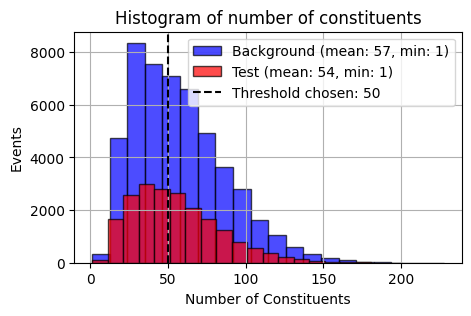

In [ ]:
#@title Analysis 1: number of optimal costituents
plt.figure(figsize=(5, 3))
plt.title("Histogram of number of constituents")
plt.xlabel("Number of Constituents")
plt.ylabel("Events")
plt.hist(np_numberofparticles, bins=20, color='blue', alpha=0.7, edgecolor='black', label=f"Background (mean: {int(np_numberofparticles.mean())}, min: {min(np_numberofparticles)})")
plt.hist(np_numberofparticles_test, bins=20, color='red', alpha=0.7, edgecolor='black', label=f"Test (mean: {int(np_numberofparticles_test.mean())}, min: {min(np_numberofparticles_test)})")
plt.axvline(x=max_constituents, color='black', linestyle='--', label=f"Threshold chosen: {max_constituents}")
plt.legend(), plt.grid(),
plt.show()

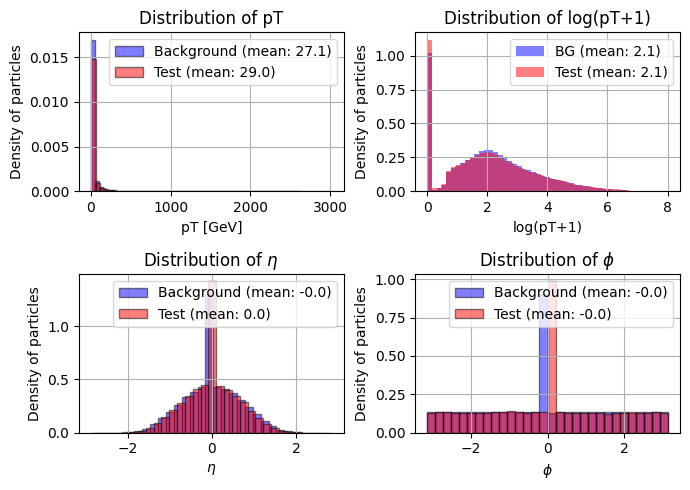

In [ ]:
#@title Analysis 2: distribution of pT, heta, phi before centering
plt.figure(figsize=(7, 5))
plt.subplot(2, 2, 1)
plt.title("Distribution of pT")
plt.xlabel("pT [GeV]")
plt.ylabel("Density of particles")
# .ravel() is like flatten
plt.hist(np_j1[:, :, 0].ravel(), bins=50, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {np_j1[:, :, 0].mean():.1f})", density=True)
plt.hist(np_j1_test[:, :, 0].ravel(), bins=50, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {np_j1_test[:, :, 0].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(2, 2, 2)
plt.title("Distribution of log(pT+1)")
plt.xlabel("log(pT+1)")
plt.ylabel("Density of particles")
log_bg= np.log1p(np_j1[:,:,0].ravel())
log_test= np.log1p(np_j1_test[:,:,0].ravel())
plt.hist(log_bg, bins=50, color='blue', alpha=0.5, label=f"BG (mean: {log_bg.mean():.1f})", density=True)
plt.hist(log_test, bins=50, color='red', alpha=0.5, label=f"Test (mean: {log_test.mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(2, 2, 3)
plt.title(r"Distribution of $\eta$")
plt.xlabel(r"$\eta$")
plt.ylabel("Density of particles")
plt.hist(np_j1[:, :,1].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {np_j1[:, :,1].mean():.1f})", density=True)
plt.hist(np_j1_test[:, :,1].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {np_j1_test[:, :,1].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(2, 2, 4)
plt.title(r"Distribution of $\phi$")
plt.xlabel(r"$\phi$")
plt.ylabel("Density of particles")
plt.hist(np_j1[:, :, 2].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {np_j1[:, :, 2].mean():.1f})", density=True)
plt.hist(np_j1_test[:, :, 2].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {np_j1_test[:, :, 2].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.tight_layout()
plt.show()

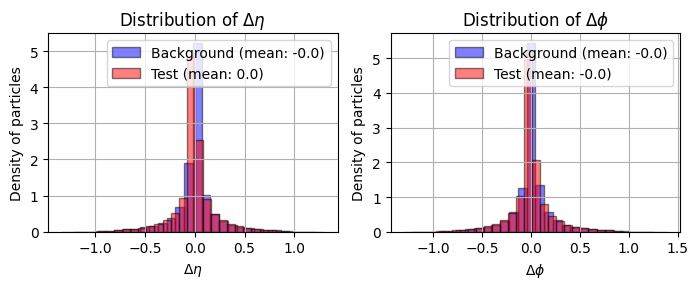

In [ ]:
#@title Analysis 3: distribution of eta, phi after centering
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.title(r"Distribution of $\Delta \eta$")
plt.xlabel(r"$\Delta \eta$")
plt.ylabel("Density of particles")
plt.hist(j1_background[:, :,1].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background[:, :,1].mean():.1f})", density=True)
plt.hist(j1_test[:, :,1].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test[:, :,1].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(1, 2, 2)
plt.title(r"Distribution of $\Delta \phi$")
plt.xlabel(r"$\Delta \phi$")
plt.ylabel("Density of particles")
plt.hist(j1_background[:, :, 2].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background[:, :, 2].mean():.1f})", density=True)
plt.hist(j1_test[:, :, 2].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test[:, :, 2].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.tight_layout()
plt.show()

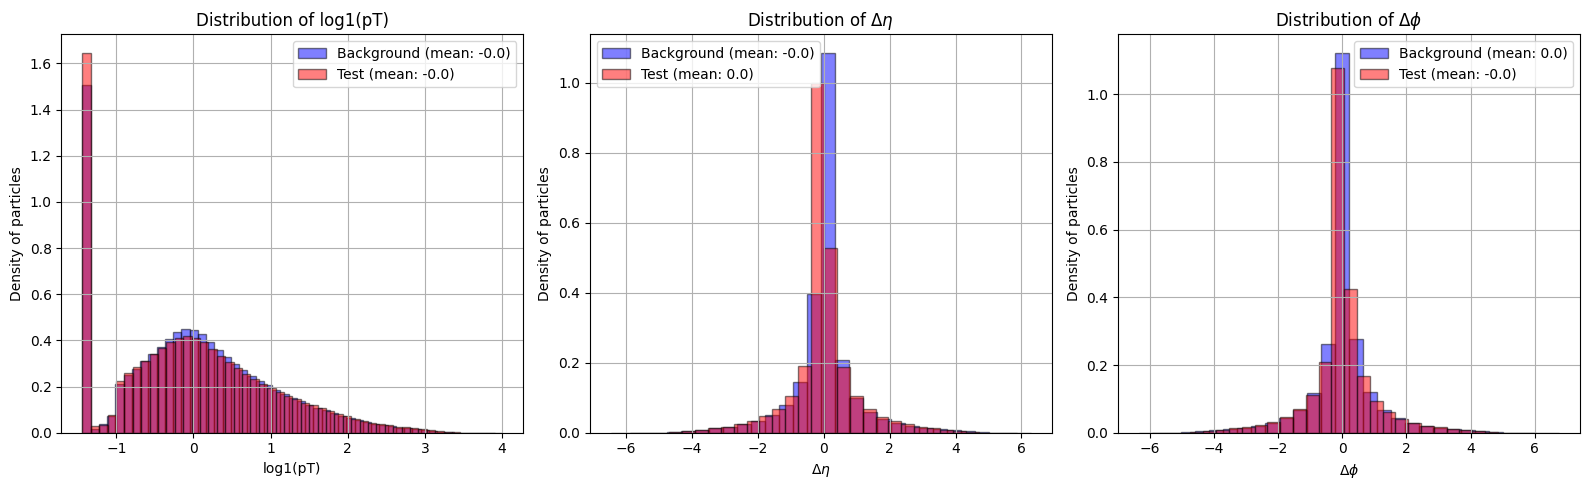

In [ ]:
#@title Analysis 4: distribution of pT, heta, phi after centering and scaling
plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1)
plt.title("Distribution of log1(pT)")
plt.xlabel("log1(pT)")
plt.ylabel("Density of particles")
# .ravel() is like flatten
plt.hist(j1_background_scaled[:, :, 0].ravel(), bins=50, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background_scaled[:, :, 0].mean():.1f})", density=True)
plt.hist(j1_test_scaled[:, :, 0].ravel(), bins=50, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test_scaled[:, :, 0].mean():.1f})", density=True)

plt.legend(), plt.grid()

plt.subplot(1, 3, 2)
plt.title(r"Distribution of $\Delta \eta$")
plt.xlabel(r"$\Delta \eta$")
plt.ylabel("Density of particles")
plt.hist(j1_background_scaled[:, :,1].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background_scaled[:, :,1].mean():.1f})", density=True)
plt.hist(j1_test_scaled[:, :,1].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test_scaled[:, :,1].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.subplot(1, 3, 3)
plt.title(r"Distribution of $\Delta \phi$")
plt.xlabel(r"$\Delta \phi$")
plt.ylabel("Density of particles")
plt.hist(j1_background_scaled[:, :, 2].ravel(), bins=30, color='blue', alpha=0.5, edgecolor='black',
         label=f"Background (mean: {j1_background_scaled[:, :, 2].mean():.1f})", density=True)
plt.hist(j1_test_scaled[:, :, 2].ravel(), bins=30, color='red', alpha=0.5, edgecolor='black',
         label=f"Test (mean: {j1_test_scaled[:, :, 2].mean():.1f})", density=True)
plt.legend(), plt.grid()

plt.tight_layout()
plt.show()

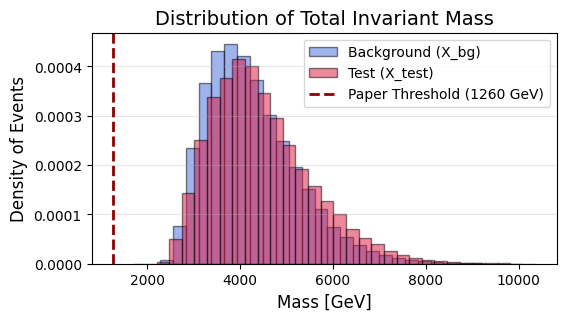

Background Mass Statistics:
- Minimum: 1720.59 GeV
- Maximum: 10044.93 GeV
- Mean: 4255.97 GeV

Test Mass Statistics:
- Minimum: 2206.02 GeV
- Maximum: 10359.06 GeV
- Mean: 4457.10 GeV


In [ ]:
#@title Analysis 5: Check of invariant mass
#@markdown In order to emulate the effect of a typical LHC
#@markdown online event selection, only jet pairs with invariant mass
#@markdown $m_{jj}$ > 1260 GeV are considered in the paper of Belis et al.

#@markdown In this section, we verify that all the events satisfy this lower limit
def check_initial_mass(X_data):
    masses = []
    for i in range(len(X_data)):
        # Reshape the event into particles [pt, eta, phi]
        event = X_data[i].reshape(-1, 3)

        # Filter out "null" particles (padding)
        mask = event[:, 0] > 0
        p_reali = event[mask]

        if len(p_reali) == 0:
            continue

        # Calculate four-momentum components using the kinematic function
        px, py, pz, e = kinematic(p_reali)

        # Sum of four-momenta of all particles in the event
        E_tot = np.sum(e)
        Px_tot = np.sum(px)
        Py_tot = np.sum(py)
        Pz_tot = np.sum(pz)

        # Invariant mass: M^2 = E^2 - |P|^2
        m2 = E_tot**2 - (Px_tot**2 + Py_tot**2 + Pz_tot**2)

        # max(0, m2) avoids numerical issues with extremely small negative numbers
        masses.append(np.sqrt(max(0, m2)))

    return np.array(masses)

# Execution using full event variables
m_bg = check_initial_mass(X_bg)
m_test = check_initial_mass(X_test)

# Visualization
plt.figure(figsize=(6, 3))
plt.hist(m_bg, bins=30, density=True, color='royalblue', alpha=0.5, edgecolor='black', label='Background (X_bg)')
plt.hist(m_test, bins=30, density=True, color='crimson', alpha=0.5, edgecolor='black', label='Test (X_test)')
plt.axvline(1260, color='darkred', linestyle='--', linewidth=2, label='Paper Threshold (1260 GeV)')

plt.title("Distribution of Total Invariant Mass", fontsize=14)
plt.xlabel("Mass [GeV]", fontsize=12)
plt.ylabel("Density of Events", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

if len(m_bg) > 0:
    print(f"Background Mass Statistics:")
    print(f"- Minimum: {m_bg.min():.2f} GeV")
    print(f"- Maximum: {m_bg.max():.2f} GeV")
    print(f"- Mean: {m_bg.mean():.2f} GeV\n")

if len(m_test) > 0:
    print(f"Test Mass Statistics:")
    print(f"- Minimum: {m_test.min():.2f} GeV")
    print(f"- Maximum: {m_test.max():.2f} GeV")
    print(f"- Mean: {m_test.mean():.2f} GeV")

## Creation of torch-tensor and DataLoaders:

In [ ]:
#@title Torch DataLoader
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

# Split 70% Train - 30% Validation
validation_size = 0.3 # @param {"type":"slider","min":0.1,"max":0.4,"step":0.05}
X_train, X_val = train_test_split(j1_background_scaled, test_size=validation_size, random_state=42)

# Conversion in PyTorch
tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)

# TensorDataset (Input, Target) -> Autoencoder input is (X, X)
train_dataset = TensorDataset(tensor_X_train, tensor_X_train)
val_dataset = TensorDataset(tensor_X_val, tensor_X_val)

# Creation of DataLoader
batch_size = 64 #@param {"type": "integer"}
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Test dataset
tensor_X_test = torch.tensor(j1_test_scaled, dtype=torch.float32)
test_dataset = TensorDataset(tensor_X_test, tensor_X_test)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"Number of Batches for Train Loader:{len(train_loader)}")
print(f"Number of Batches for Val Loader: {len(val_loader)}")
print(f"Number of Batches for Test Loader (BlackBox): {len(test_loader)}")

Number of Batches for Train Loader:547
Number of Batches for Val Loader: 235
Number of Batches for Test Loader (BlackBox): 20000


In [ ]:
#@title Testing the Data-loaders
elem, elem = next(iter(train_loader))
print("Train loader first element: ", elem.shape)
elem, elem = next(iter(test_loader))
print("Test loader first element: ", elem.shape)
elem, elem = next(iter(val_loader))
print("Validation Loader first element: ", elem.shape)

Train loader first element:  torch.Size([64, 50, 3])
Test loader first element:  torch.Size([1, 50, 3])
Validation Loader first element:  torch.Size([64, 50, 3])


# 2.) Autoencoder


**Model Architecture: Deep Convolutional Autoencoder (`DeepConvAutoencoder`)**

To compress the multi-constituent jet structures into a low-dimensional representation without losing essential spatial correlations, we implement a custom **Deep Convolutional Autoencoder**. Jets are structured objects where neighboring constituents within a $(\eta, \phi)$ cone share strong structural dependencies. Traditional fully connected (Linear) layers ignore this layout, whereas Convolutional Neural Networks (CNNs) are ideal for capturing local patterns and energy substructures.

The network is composed of two modules:
* **The Encoder:** The input tensor of shape `(Batch, Max_Constituents, 3)` undergoes a localized 2D convolution (`Conv2d`) with a kernel size of `(1, 3)` to project the independent physical features ($p_T, \eta, \phi$) into a shared feature space (with dimension `hidden_dim`).
This representation is then processed by a sequence of **1D Convolutional layers** (`Conv1d`) combined with **Batch Normalization** and **LeakyReLU** activations to extract deeper hierarchic features, followed by **MaxPool1d** layers to downsample the sequence. Finally, the flattened tensor passes through a dense neck, compressing the data into a continuous latent space of dimensions ($4, 8, \text{ or } 16$), bounded within a $[-1, 1]$ range via a **Tanh** activation. This specific bounding is critical for the subsequent hybrid phase: it prevents phase-wrapping and state-saturation when these latent variables are injected as rotation parameters into the Quantum Feature Map.

* **The Decoder:** Reversing the encoder's operations, the decoder reconstructs the raw dimensions. It starts with dense linear layers that map the latent space back to the convolutional shape. It then utilizes **Upsampling** and **Transpose 1D Convolutions** (`ConvTranspose1d`) to restore the original particle sequence size, culminating in a 2D Transpose Convolution to output the reconstructed $(\log(1+p_T), \Delta\eta, \Delta\phi)$ coordinates for each constituent. During training, the decoder forces the latent space to retain only the most prominent physical features of Standard Model background events, serving as the baseline for unsupervised anomaly detection

In [ ]:
import torch
import torch.nn as nn
from torchsummary import summary
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device is: ", device)

Device is:  cuda


## Model

In [ ]:
#@title Encoder
"""
    Encoder Network: Projects geometric and physical features of jet constituents
    into a lower-dimensional latent space.
    """
class Encoder(nn.Module):
    def __init__(self, hidden_dim=12, num_features=3, latent_dim=8, kernel1d=5, padd1d=1, max_constituents=max_constituents):
        super(Encoder, self).__init__()
        # Block 1: Dimensionality reduction of constituent features (2D to 1D pseudo-spatial)
        # Transforms input from [B, 1, max_constituents, num_features] to [B, hidden_dim, max_constituents, 1]
        self.conv2d=nn.Conv2d(in_channels=1, out_channels= hidden_dim, kernel_size=(1, num_features))
        self.act_2d=nn.LeakyReLU(0.2)

        # Block 2: 1D Convolutional feature extraction along the constituents dimension
        self.encoder_cnn = nn.Sequential(
            # First 1D convolution and normalization
            nn.Conv1d(in_channels=hidden_dim, out_channels=hidden_dim*2, kernel_size=kernel1d, padding=padd1d),
            nn.BatchNorm1d(hidden_dim*2),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(kernel_size=2), # maxpool in 2dimension
            # Second 1D convolution and normalization
            nn.Conv1d(in_channels=hidden_dim*2, out_channels=hidden_dim*3, kernel_size=kernel1d, padding=padd1d),
            nn.BatchNorm1d(hidden_dim*3),
            nn.LeakyReLU(0.2),
            nn.MaxPool1d(kernel_size=2), # maxpool in 2dimension
        )

        #Factor is a dynamic value of the last layer
        # Derived mathematically from the standard output formulas of Conv1d and MaxPool1d layers.
        self.factor= ((((max_constituents + 2*padd1d - kernel1d) // 1 + 1) // 2 + 2*padd1d - kernel1d) // 1 + 1) // 2


        # Block 3: Fully Connected layers for final compression into the latent space
        self.encoder_linear = nn.Sequential(
            nn.Linear(hidden_dim*3 * self.factor, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim*2, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, latent_dim),
            nn.Tanh() # Constrains the latent space mapping to [-1, 1] for numerical stability
        )

    def forward(self, x):
        #Expected input shape: [Batch_Size, max_constituents, num_features]
        # 1. Prepare for 2D convolution by adding a single channel dimension (in_channels=1)
        x = self.conv2d(x.unsqueeze(1))      # Shape: [B, hidden_dim, max_constituents, 1]
        x = self.act_2d(x)

        # 2. Squeeze the last redundant dimension to switch to 1D convolutional processing

        x = x.squeeze(-1)      # Shape: [B, hidden_dim, max_constituents]

        # 3. Extract hierarchical convolutional features
        x = self.encoder_cnn(x)         # Shape: [B, hidden_dim*3, self.factor]
        # 4. Flatten and map through linear layers to compute the latent vector
        x = x.flatten(1)                # Shape: [B, hidden_dim*3 * self.factor]
        x = self.encoder_linear(x)      # Shape: [B, latent_dim]
        return x

# Visualization of the encoder
# print("--- SUMMARY ENCODER ---")
# encoder_test = Encoder().to(device)
# if torch.cuda.is_available():
#   summary(encoder_test.cuda(), input_size=(max_constituents, 3))
# else:
#   summary(encoder_test, input_size=(max_constituents, 3))

In [ ]:
#@title Decoder

"""
    Decoder Network: Reconstructs the geometric and physical features of jet constituents
    starting from the lower-dimensional latent space representation.
    """

class Decoder(nn.Module):
    def __init__(self, hidden_dim=12, num_features=3, latent_dim=8, kernel1d=5, padd1d=1, max_constituents=max_constituents):
        super(Decoder, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_features = num_features

        # Mathematical tracking of spatial dimensions (inverses of Encoder pooling and convolutions)
        self.s2 = (max_constituents + 2*padd1d - kernel1d) // 1 + 1  # Dim after Conv1 (Encoder) / target for Upsample 2
        self.s3 = self.s2 // 2                                       # Dim after Pool1 (Encoder)
        self.s4 = (self.s3 + 2*padd1d - kernel1d) // 1 + 1          # Dim after Conv2 (Encoder) / target for Upsample 1
        self.factor = self.s4 // 2                                 # Dim after Pool2 (Encoder) / starting spatial dim for Decoder


        # Block 1: Fully Connected layers to expand the latent space before spatial reconstruction
        self.decoder_linear = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim, hidden_dim*2),
            nn.BatchNorm1d(hidden_dim*2),
            nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim*2, hidden_dim*3 * self.factor),
            nn.BatchNorm1d(hidden_dim*3 * self.factor),
            nn.LeakyReLU(0.2)
        )
       # Block 2: 1D Transposed Convolutional layers to progressively upsample features along the constituents dimension
        self.decoder_cnn = nn.Sequential(
            # First upsampling block to invert the second Encoder pooling/convolution
            nn.Upsample(size=self.s4),
            nn.ConvTranspose1d(hidden_dim*3, hidden_dim*2, kernel_size=kernel1d, padding=padd1d),
            nn.BatchNorm1d(hidden_dim*2),
            nn.LeakyReLU(0.2),
            # Second upsampling block to invert the first Encoder pooling/convolution
            nn.Upsample(size=self.s2),
            nn.ConvTranspose1d(hidden_dim*2, hidden_dim, kernel_size=kernel1d, padding=padd1d),
            nn.BatchNorm1d(hidden_dim),
            nn.LeakyReLU(0.2)
        )
        # Block 3: 2D Transposed Convolution to expand pseudo-spatial 1D features back to the original constituent features (1 to num_features)
        self.conv2d_transpose = nn.ConvTranspose2d(hidden_dim, 1, kernel_size=(1, num_features))

    def forward(self, x):
        # Expected input shape: [Batch_Size, latent_dim]
        # 1. Map through linear layers to expand the compressed representation
        x = self.decoder_linear(x)
        # 2. Reshape to restore the channel and pseudo-spatial structure for 1D CNN processing
        x = x.view(-1, self.hidden_dim*3, self.factor)
        # 3. Reconstruct hierarchical convolutional features via upsampling and transposed convolutions
        x = self.decoder_cnn(x)
        # 4. Add a redundant spatial dimension to prepare for 2D Transposed Convolution
        x = x.unsqueeze(-1)
        # 5. Project channels back to 1 and expand the last dimension to match num_features
        x = self.conv2d_transpose(x)
        # 6. Apply physical scaling/activation and remove the redundant channel dimension
        x= torch.tanh(x)*3
        return x.squeeze(1)

# print("--- SUMMARY DECODER ex---")
# decoder_test = Decoder(latent_dim=8, max_constituents=50).to(device)
# if torch.cuda.is_available():
#     summary(decoder_test.cuda(), input_size=(8,))
# else:
#     summary(decoder_test, input_size=(8,))

In [ ]:
#@title DeepConvAutoencoder
lat_dim=8 #@param [4, 8, 16] {type:"raw"}
"""
    Deep Convolutional Autoencoder Network: Core model architecture that unifies
    the Encoder and Decoder to perform end-to-end compression and reconstruction
    of jet constituent features.
    """
class DeepConvAutoencoder(nn.Module):
    def __init__(self, num_features=3, latent_dim=8, hidden_dim=12, kernel1d=5, padd1d=1, max_constituents=max_constituents):
        super(DeepConvAutoencoder, self).__init__()
        # Instantiate sub-modules with matching hyper-parameters
        self.encoder = Encoder(hidden_dim, num_features, latent_dim, kernel1d, padd1d, max_constituents)
        self.decoder = Decoder(hidden_dim, num_features, latent_dim, kernel1d, padd1d, max_constituents)

    def forward(self, x):
        # Expected input shape: [Batch_Size, max_constituents, num_features]
        # 1. Compress input features into the bottle-neck latent space
        latent = self.encoder(x)
        # 2. Reconstruct the original feature space from the latent representation
        reconstruction = self.decoder(latent)
        return reconstruction

    def get_latent(self, x):
        """
        Utility method to extract only the compressed latent representations.
        Useful for downstream tasks like classification, clustering, or visualization.
        """

        return self.encoder(x)

# Initialization and Summary Pipeline
model = DeepConvAutoencoder(num_features=3,
                            latent_dim=lat_dim,
                            hidden_dim=12 #@param {"type": "integer"},
                            ,
                            kernel1d=3 #@param {"type":"integer"}
                            ,
                            padd1d=1 #@param {"type":"integer"}
                            ,
                            max_constituents=max_constituents).to(device)

print("--- SUMMARY AUTOENCODER COMPLETE ---")
# Generate model summary based on the available hardware acceleration
if torch.cuda.is_available():
    summary(model.cuda(), (max_constituents, 3))
else:
    summary(model, input_size=(max_constituents, 3))
print(f"Model Multi-layer CNN created on: {device}")

--- SUMMARY AUTOENCODER COMPLETE ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 12, 50, 1]              48
         LeakyReLU-2            [-1, 12, 50, 1]               0
            Conv1d-3               [-1, 24, 50]             888
       BatchNorm1d-4               [-1, 24, 50]              48
         LeakyReLU-5               [-1, 24, 50]               0
         MaxPool1d-6               [-1, 24, 25]               0
            Conv1d-7               [-1, 36, 25]           2,628
       BatchNorm1d-8               [-1, 36, 25]              72
         LeakyReLU-9               [-1, 36, 25]               0
        MaxPool1d-10               [-1, 36, 12]               0
           Linear-11                   [-1, 24]          10,392
      BatchNorm1d-12                   [-1, 24]              48
        LeakyReLU-13                   [-1, 24]               0
  

## Training

**Optimization and Training Strategy**

Reconstructing clustered jet data is a huge challenge: the constituents inside a jet are fundamentally an **unordered point cloud** rather than a sequential grid. Using standard pixel-wise metrics like Mean Squared Error (**MSE**) would force the model to **penalize permutations**, causing training instability and bad convergence if the particles are reconstructed out of order.

To overcome this, we utilize the **Chamfer Distance (Chamfer Loss)** as our optimization criterion:
$$L_R = \frac{1}{N} \sum_{i \in \text{input}} \min_j \left[ (x^{(i)} - x^{(j)})^2 \right] + \frac{1}{M} \sum_{j \in \text{output}} \min_i \left[ (x^{(j)} - x^{(i)})^2 \right]$$
where $$(x^{(i)} - x^{(j)})^2 = (p_{T, i} - p_{T, j})^2 + (\eta_i - \eta_j)^2 + (\phi_i - \phi_j)^2$$

#### Why Chamfer Loss is highly effective:
* **Permutation Invariance:** For each point in the original input, it finds the single closest point in the reconstructed output (and vice-versa) and computes their squared distance. This ensures that as long as the overall shape, energy distribution, and geometry of the jet are perfectly replicated, the precise index sequence of the particles does not penalize the model.
* **Handling Padding:** It works cleanly alongside zero-padded clusters, focusing heavily on matching the physical high-$p_T$ particle clusters.

#### Training Framework & Tolerance Mechanisms:
To ensure stable convergence and prevent overfitting on the background sample, the training loop incorporates three specialized optimization constraints:
1. **Adam Optimizer:** We initialize the weights using the Adam optimizer with a learning rate of $0.001$, balancing adaptive gradients for quick exploration.
2. **Learning Rate Scheduling (`ReduceLROnPlateau`):** The scheduler monitors the validation loss. If the loss plateaus for 5 consecutive epochs, the learning rate is halved (`factor=0.5`). This allows the model to fine-tune its weights with smaller steps as it approaches a local minimum.
3. **Early Stopping with Tolerance (`patience_limit`):** To safeguard against overfitting and avoid redundant computations, a strict patience mechanism is introduced. If the `Validation Loss` fails to improve for 15 consecutive epochs (`patience_limit=15`), the training execution is automatically terminated.

In [ ]:
#@title Chamfer_loss definition (con maschera del padding)

def chamfer_loss(a, b, pad_vec=None):
    """
    (Optionally masked) Chamfer Distance between two point clouds.
    Shapes: [Batch, N_constituents, 3] (or [N_constituents, 3]).
    a -> reconstructed points, b -> input/target points.

    If 'pad_vec' is provided, the zero-padding constituents of the INPUT 'b'
    (all collapsed onto the constant point 'pad_vec' after log1p+StandardScaler)
    are excluded, so they no longer act as spurious targets in the loss.
    If 'pad_vec' is None the function falls back to the original (unmasked) loss.
    """
    if len(a.shape) == 2:
        a = a.unsqueeze(0)
    if len(b.shape) == 2:
        b = b.unsqueeze(0)

    # Squared distance matrix: ||A-B||^2 = ||A||^2 + ||B||^2 - 2 A B^T  -> [B, N, M]
    a_sq = torch.sum(a**2, dim=-1, keepdim=True)
    b_sq = torch.sum(b**2, dim=-1, keepdim=True).transpose(-2, -1)
    dist_matrix = a_sq + b_sq - 2 * torch.bmm(a, b.transpose(-2, -1))

    if pad_vec is None:
        # --- original (unmasked) behaviour ---
        dist_a_to_b, _ = torch.min(dist_matrix, dim=-1)
        dist_b_to_a, _ = torch.min(dist_matrix, dim=-2)
        return torch.mean(dist_a_to_b) + torch.mean(dist_b_to_a)

    # --- masked behaviour: exclude padding points of the input 'b' ---
    pad_vec = pad_vec.to(b.device)
    real_b = (torch.abs(b - pad_vec) > 1e-5).any(dim=-1)            # [B, M] True = real point

    # reconstructed -> nearest REAL input (padding columns -> +inf so they are never chosen)
    masked = dist_matrix.masked_fill(~real_b.unsqueeze(1), float('inf'))
    dist_a_to_b = torch.min(masked, dim=-1).values.mean()          # [B, N] -> scalar

    # real input -> nearest reconstructed (average only over real input points)
    dist_b_to_a = torch.min(dist_matrix, dim=-2).values            # [B, M]
    dist_b_to_a = (dist_b_to_a * real_b).sum() / real_b.sum().clamp(min=1)

    return dist_a_to_b + dist_b_to_a

### Start Training

The flag `load_saved_model` controls the download from google drive of a pretrained autoencoder with latent dimension=8.

In [ ]:
#@title train with Chamfer Loss
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau

load_saved_model = True #@param {type:"boolean"}
# [guard] il modello pre-addestrato su Drive vale solo per max_constituents=50 e lat_dim=8
if max_constituents != 50 or lat_dim != 8:
    load_saved_model = False
    print(f"[guard] config non standard (max_constituents={max_constituents}, lat_dim={lat_dim}) -> ri-addestramento (load_saved_model=False)")
best_model_path = './best_autoencoder.pth'

criterion = chamfer_loss
PAD_VEC = torch.as_tensor(pad_vec, dtype=torch.float32, device=device)  # punto di padding da mascherare
epochs = 140   #@param {type:"slider", min:120, max:200, step:10}
patience_limit = 15 #@param {type:"slider",  min:5, max:15, step:1}


optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

if load_saved_model and lat_dim==8:
    if not os.path.exists(best_model_path):
        print("Downloading the best model with gdown")
        url_model="https://drive.google.com/uc?id=1myTRharojSufbDKIj44ByzOvmBynY3dC"
        gdown.download(url_model, best_model_path, quiet=False)
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    print(f"MODEL LOADED: {best_model_path}")
else:
    print("NEW TRAINING STARTED")

    patience_counter = 0
    train_losses, val_losses = [], []
    # Variable useful to save the best model if best_val_loss decreases
    best_val_loss = float('inf')

    for epoch in range(epochs):
        model.train() # training mode
        running_train_loss = 0.0

        for batch_x, _ in train_loader:
            batch_x = batch_x.to(device)
            # Forward pass
            reconstructed = model(batch_x)
            loss = criterion(reconstructed, batch_x, PAD_VEC)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * batch_x.size(0)
        # Compute mean loss of the epoch
        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # --- FASE VALIDATION ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for batch_x, _ in val_loader:
                batch_x = batch_x.to(device)
                reconstructed = model(batch_x)
                loss = criterion(reconstructed, batch_x, PAD_VEC)
                running_val_loss += loss.item() * batch_x.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        # --- EARLY STOPPING + SAVE ---
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            # torch.save(model.state_dict(), best_model_path)
            torch.save(model.to("cpu").state_dict(), best_model_path)
            model.to(device)
            patience_counter = 0
            print(f"--> better model found! Model saved at: {epoch_val_loss:.4f}")
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print(f"Early stopping all'epoca {epoch+1} (val_loss ferma da {patience_limit} epoche)")
                break

        scheduler.step(epoch_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        if epoch % 2 == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | LR: {current_lr:.5f} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Patience: {patience_counter}/{patience_limit}")

    print(f"--> Weights saved in: {best_model_path}")

Downloading...
From: https://drive.google.com/uc?id=1myTRharojSufbDKIj44ByzOvmBynY3dC
To: /content/best_autoencoder.pth
100%|██████████| 149k/149k [00:00<00:00, 82.9MB/s]

MODEL LOADED: ./best_autoencoder.pth


In [ ]:
#@title plot of the loss
if not load_saved_model or lat_dim!=8:
  plt.figure(figsize=(10, 4))
  plt.plot(range(1, len(train_losses)+1), train_losses, label='Training Loss', linewidth=2)
  plt.plot(range(1, len(val_losses)+1), val_losses, label='Validation Loss', linewidth=2)
  plt.xlabel('Epochs', fontsize=12)
  plt.ylabel('Loss', fontsize=12)
  plt.yscale('log')
  plt.title('Denoising AE - Learning Curve', fontsize=14)
  plt.legend(fontsize=12)
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.show()

## Analisi spazio latente:

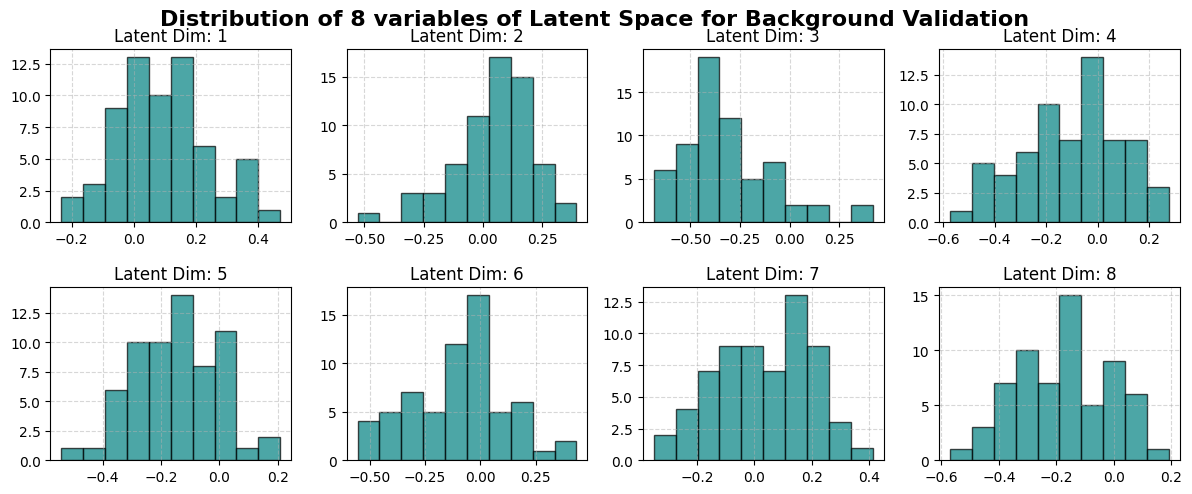

In [ ]:
#@title Latent Space visualization for one validation event
#@markdown The histograms show that all 8 latent dimensions are actively utilized and well-distributed, confirming the absence of dead or collapsed dimensions in the bottleneck layer.
model.eval()

#Use of a batch to do plots
sample_data, _ = next(iter(val_loader))
sample_data = sample_data.to(device)

with torch.no_grad():
    latent_space = model.get_latent(sample_data)
    reconstructed_data = model(sample_data)

# On cpu
sample_data_np = sample_data.cpu().numpy()
latent_space_np = latent_space.cpu().numpy()
reconstructed_data_np = reconstructed_data.cpu().numpy()


# ==========================================
# PLOT 1: LATENT SPACE
# ==========================================
plt.figure(figsize=(12, 5))
plt.suptitle("Distribution of 8 variables of Latent Space for Background Validation", fontsize=16, fontweight='bold')

for i in range(lat_dim):
    plt.subplot(2, 4, i+1)
    plt.hist(latent_space_np[:, i], bins=10, color='teal', alpha=0.7, edgecolor='black')
    plt.title(f"Latent Dim: {i+1}")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [ ]:
#@title Reconstruction of the first batch of validation

# Aggregate and flatten data from all events into a single DataFrame, sorted by pT in descending order
data = []
for ev_idx in range(len(sample_data_np)):
    # Sort original and reconstructed constituents by pT (index 0) in descending order
    o_s = sample_data_np[ev_idx][np.argsort(sample_data_np[ev_idx][:, 0])[::-1]]
    r_s = reconstructed_data_np[ev_idx][np.argsort(reconstructed_data_np[ev_idx][:, 0])[::-1]]

    for p_idx in range(len(o_s)):
        for i, lbl in enumerate(['pT', 'Eta', 'Phi']):
            data.append([ev_idx, p_idx, lbl, o_s[p_idx, i], 'Original'])
            data.append([ev_idx, p_idx, lbl, r_s[p_idx, i], 'Reconstructed'])

df = pd.DataFrame(data, columns=['Evento', 'Particle Index', 'Metric', 'Value', 'Type'])

# Generate the animated plot with an integrated event slider and 3 subplots (pT, Eta, Phi)
fig = px.line(df, x='Particle Index', y='Value', color='Type', facet_col='Metric',
              animation_frame='Evento', markers=True, category_orders={'Metric': ['pT', 'Eta', 'Phi']})



# Configure global margins to minimize whitespace (tight layout effect)
fig.update_layout(
    margin=dict(l=50, r=20, t=50, b=50),
    height=450
)

print("PLEASE, CLICK ON AUTOSCALE or ZOOM OUT, IN THE UPPER-RIGHT TO RESCALE THE AXES")
fig.show()

PLEASE, CLICK ON AUTOSCALE or ZOOM OUT, IN THE UPPER-RIGHT TO RESCALE THE AXES


## Extraction of latent space


This code uses the trained Encoder in evaluation mode to compress the full background and blackbox test datasets into their low-dimensional representations. The extracted latent vectors are then combined and saved as NumPy arrays (.npy), preparing the optimized data for the subsequent anomaly detection phase.

In [ ]:
#@title Extraction of Latent Space
path_blackbox="processed_data/latent_blackbox.npy"
path_bg="processed_data/latent_bg.npy"
if not load_saved_model or lat_dim!=8:
  print("Latent Space extraction")

  # Ensure the model is in evaluation mode
  model.eval()

  def extract_latent_space(dataloader):
      latent_vectors = []
      with torch.no_grad():
          for batch_x, _ in dataloader:
              batch_x = batch_x.to(device)
              # Use the encoder!
              latent = model.get_latent(batch_x)
              latent_vectors.append(latent.cpu().numpy())

      # Combine all batches into a single large numpy array
      return np.vstack(latent_vectors)

  # For Anomaly Detection, we need the entire background (train + val)
  # Create a single DataLoader without shuffle to extract everything in order
  X_bg_full_tensor = torch.tensor(j1_background_scaled, dtype=torch.float32)
  bg_full_loader = DataLoader(TensorDataset(X_bg_full_tensor, X_bg_full_tensor),
                              batch_size=batch_size,
                              shuffle=False)

  # Extracting!
  latent_bg = extract_latent_space(bg_full_loader)
  latent_test = extract_latent_space(test_loader)

  print(f"Dimensions Background Latent: {latent_bg.shape}")
  print(f"Dimensions BlackBox Latent: {latent_test.shape}")

  np.save(path_bg, latent_bg)
  np.save(path_blackbox, latent_test)

  print("Latent datasets successfully saved to Drive!")

# 2.1) Classical Methods of Clustering

In [ ]:
#@title Loading of latent space vectors for test and train data

if load_saved_model and lat_dim==8:
  if not os.path.exists(path_blackbox):
      print("Downloading the latent space for blackbox using gdown")
      url_="https://drive.google.com/uc?id=1fu2mYd-h6YSrpuQr1YyxuUxXlYHfz54-"
      gdown.download(url_, path_blackbox, quiet=False)
  if not os.path.exists(path_bg):
      print("Downloading the latent space for background using gdown")
      url_="https://drive.google.com/uc?id=1RbsIHjnxItK8sWzJdK3jsKF7oqG-egLK"
      gdown.download(url_, path_bg, quiet=False)


print("\n\nLoading latent space and labels")
latent_blackbox = np.load(path_blackbox)
latent_bg = np.load(path_bg)

latent_bg_train, latent_bg_vali = train_test_split(latent_bg, test_size=0.30, random_state=42)

print(f"Background Latent Space Dimensions (Train): {latent_bg_train.shape}")
print(f"Background Latent Space Dimensions (Validation): {latent_bg_vali.shape}")
print(f"BlackBox Latent Space Dimensions (Test): {latent_blackbox.shape}")
print(f"True Labels Dimensions: {true_labels.shape}")

total_true_anomalies = np.sum(true_labels == 1)
print(f"In test latent space: Number of anomalies", int(total_true_anomalies), "Number of background events", np.sum(true_labels==0))

Downloading...
From: https://drive.google.com/uc?id=1fu2mYd-h6YSrpuQr1YyxuUxXlYHfz54-
To: /content/processed_data/latent_blackbox.npy
100%|██████████| 640k/640k [00:00<00:00, 120MB/s]


Downloading...
From: https://drive.google.com/uc?id=1RbsIHjnxItK8sWzJdK3jsKF7oqG-egLK
To: /content/processed_data/latent_bg.npy
100%|██████████| 1.60M/1.60M [00:00<00:00, 195MB/s]



Loading latent space and labels
Background Latent Space Dimensions (Train): (35000, 8)
Background Latent Space Dimensions (Validation): (15000, 8)
BlackBox Latent Space Dimensions (Test): (20000, 8)
True Labels Dimensions: (20000,)
In test latent space: Number of anomalies 834 Number of background events 19166


## I. Reconstruction-loss anomaly detection

Here, we evaluate the Autoencoder’s performance directly through its reconstruction capabilities.

The core principle is that the model is trained to minimize reconstruction error on normal background data; consequently, it learns a compressed representation that successfully captures the features of these events.

**Anomalous events**, which do not conform to the learned distribution, incur a significantly **higher reconstruction loss**.

We quantify this performance by setting a threshold on the loss distribution, separating signal from background, and assessing the detection efficiency via the Receiver Operating Characteristic (ROC) curve.

**Youden's J Statistic Selection**

The threshold selection is performed using Youden’s J statistic, defined as $J = \text{TPR} - \text{FPR}$. This metric represents the vertical distance between the Receiver Operating Characteristic (ROC) curve and the chance diagonal (the line where $\text{TPR} = \text{FPR}$). By maximizing this value, we identify the optimal operating point on the ROC curve that simultaneously maximizes sensitivity (true positive rate, or recall) and specificity (1 - false positive rate), effectively balancing the trade-off between capturing true positives and minimizing false alarms.

True positive 540, Auc: 0.6516, Best fpr: 0.43, Best tpr: 0.65


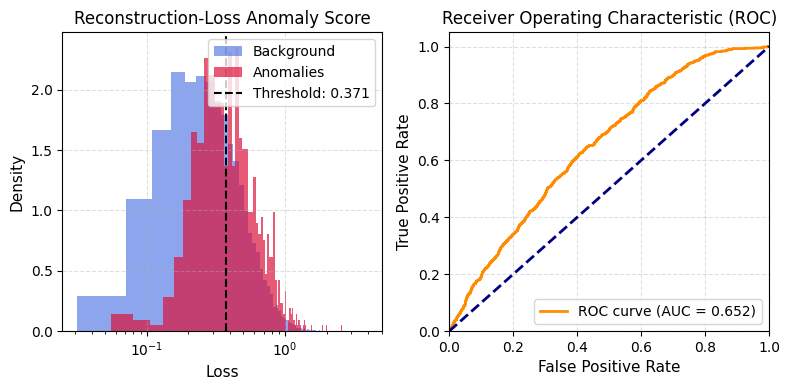

In [ ]:
#@title Reconstruction loss (con e senza maschera del padding, stesso modello pre-addestrato)
from sklearn.metrics import roc_curve, auc
model.eval()
PAD_VEC = torch.as_tensor(pad_vec, dtype=torch.float32, device=device)
reconstruction_scores = []           # CON maschera (fix Chamfer)
reconstruction_scores_unmasked = []  # SENZA maschera (comportamento originale)
with torch.no_grad():
    for batch_x, _ in test_loader:
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)

        loss_masked = criterion(reconstructed, batch_x, PAD_VEC)
        loss_unmasked = criterion(reconstructed, batch_x)
        reconstruction_scores.append(loss_masked.cpu().numpy())
        reconstruction_scores_unmasked.append(loss_unmasked.cpu().numpy())

reconstruction_scores = np.array(reconstruction_scores)
reconstruction_scores_unmasked = np.array(reconstruction_scores_unmasked)

fpr, tpr, thresholds = roc_curve(true_labels, reconstruction_scores)
roc_auc = auc(fpr, tpr)

fpr_u, tpr_u, thresholds_u = roc_curve(true_labels, reconstruction_scores_unmasked)
roc_auc_u = auc(fpr_u, tpr_u)

best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
predictions = (reconstruction_scores > best_threshold).astype(int)
true_positives=tpr[best_idx]*total_true_anomalies

print("--- Confronto sullo stesso modello pre-addestrato (max_constituents=50) ---")
print(f"SENZA maschera del padding (originale) -> AUC: {roc_auc_u:.4f}")
print(f"CON   maschera del padding (fix)       -> AUC: {roc_auc:.4f}")
print(f"True positive {int(true_positives)}, Auc: {roc_auc:.4f}, Best fpr: {fpr[best_idx]:.2f}, Best tpr: {tpr[best_idx]:.2f}")



# Create a single figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Subplot 1: Histogram Visualization
axes[0].hist(reconstruction_scores[true_labels == 0], bins=100, color='royalblue', alpha=0.6, density=True, label='Background')
axes[0].hist(reconstruction_scores[true_labels == 1], bins=100, color='crimson', alpha=0.7, density=True, label='Anomalies')
axes[0].set_title(f"Reconstruction-Loss Anomaly Score (con maschera)", fontsize=12)
axes[0].set_xlabel("Loss", fontsize=11)
axes[0].set_ylabel("Density", fontsize=11)
axes[0].set_xscale('log')
axes[0].axvline(x=best_threshold, color='black', linestyle='--', label=f'Threshold: {best_threshold:.3f}')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# Subplot 2: ROC Curve (confronto con/senza maschera)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Con maschera (AUC = {roc_auc:.3f})')
axes[1].plot(fpr_u, tpr_u, color='seagreen', lw=2, linestyle=':', label=f'Senza maschera (AUC = {roc_auc_u:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title(f"ROC: effetto della maschera del padding", fontsize=12)
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].legend(loc="lower right")
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## II. K MEANS

In this section, we use K-Means clustering to perform anomaly detection in the latent space.
The core idea is that the Autoencoder maps "normal" background data into compact clusters.
Anomalous events will likely fall far from these clusters.

To quantify this, we calculate an anomaly score defined as the minimum Euclidean distance from each test point to its nearest cluster center.
A larger distance suggests a greater deviation from the background distribution.

Furthermore, we monitor the model's '**inertia**'—the sum of squared distances of samples to their closest cluster center — to assess how tightly packed the clusters are, which helps us interpret the **internal structure** of our latent data and verify the **optimal number of clusters**, chosen via silhouette score, ideally in the elbow point of the clustering.

**Mathematical Formulation of Quantum K-Means for Anomaly Detection**


**1. Cluster Validation via the Silhouette Score**

To determine the optimal number of clusters ($k$) without relying on labeled data, we quantify the geometric separation of the formed clusters using the **Silhouette Score**. For each sample $i$ assigned to a cluster, the silhouette coefficient $s_i$ is defined as:

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

Where:

* **$a_i$ (Intra-cluster cohesion):** The mean distance between sample $i$ and all other points within the same cluster. Low values of $a_i$ means that the cluster is compact
* **$b_i$ (Inter-cluster separation):** The mean distance between sample $i$ and the points in the nearest neighboring cluster. High values of $b_i$ means that the point is well separated from other clusters.

The global Silhouette Score is the average of $s_i$ across all samples in the dataset. This metric ranges from $[-1, 1]$, where values closer to $+1$ indicate high-quality, dense, and well-separated clusters, providing a robust, unsupervised indicator of optimal model configuration. For this reason, the minimum value of k is 2.

**2. Anomaly Scoring via Distance Metrics**

Once the optimal $k$ is selected, we define the anomaly score $S(x)$ for any given sample $x$ as the minimum Euclidean distance to the nearest cluster centroid $\mu_j$:


$$S(x) = \min_{j \in \{1, \dots, k\}} \Vert \phi(x) - \mu_j \Vert^2$$

This formulation treats the cluster centroids as representatives of the "normal" training data density. Consequently:

* **Low Anomaly Score:** Points proximal to a centroid represent typical background events.
* **High Anomaly Score:** Points residing in low-density regions (far from all centroids) are flagged as potential signal anomalies.

**3. Evaluation and ROC Analysis**

To quantify the model's sensitivity and specificity, we compute the **ROC curve** (Receiver Operating Characteristic) by varying the threshold applied to the anomaly score $S(x)$. The area under this curve (**AUC**) serves as the primary metric for assessing the model's classification performance. By maximizing the Silhouette Score during model selection and subsequently validating via AUC, we ensure that the quantum latent space partitioning generalizes effectively to unseen test data, minimizing false positives while maximizing true signal recovery.

In [ ]:
#@title K-means computation
from sklearn.metrics import roc_curve, auc, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler_l = StandardScaler()
latent_bg_train_norm = scaler_l.fit_transform(latent_bg_train)
latent_bg_vali_norm = scaler_l.transform(latent_bg_vali)
latent_blackbox_norm = scaler_l.transform(latent_blackbox)
print("Latent space vectors are now normalized using StandardScaler")

# K-MEANS LOOP
kmin=2  #@param {type:"slider", min:2, max:10, step:1}
kmax=20 #@param {type:"slider", min:11, max:30, step:1}
verbose = True #@param {type:"boolean"}
k_values = list(range(kmin, kmax+1))
results = []

print(f"K-Means loop from k={k_values[0]} to k={k_values[-1]}")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    kmeans.fit(latent_bg_train_norm)

    # Calculate Silhouette Scores for train and validation datasets
    sil_train = silhouette_score(latent_bg_train_norm, kmeans.labels_, sample_size=5000, random_state=42)
    sil_val = silhouette_score(latent_bg_vali_norm, kmeans.predict(latent_bg_vali_norm), sample_size=5000, random_state=42)

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    val_distances = kmeans.transform(latent_bg_vali_norm)
    val_scores = np.min(val_distances, axis=1)
    val_inertia = np.sum(np.square(val_scores)) # Total squared distance on validation set

    # Test evaluation (For final performance plot only)
    test_distances = kmeans.transform(latent_blackbox_norm)
    test_scores = np.min(test_distances, axis=1)

    fpr, tpr, thresholds = roc_curve(true_labels, test_scores)
    roc_auc = auc(fpr, tpr)
    if roc_auc < 0.5:
        roc_auc, test_scores = 1 - roc_auc, -test_scores
        fpr, tpr, thresholds = roc_curve(true_labels, test_scores)

    best_threshold = thresholds[np.argmax(tpr - fpr)]
    n_predicted = np.sum((test_scores >= best_threshold).astype(int) == 1)
    true_positives = int(tpr[np.argmax(tpr - fpr)] * total_true_anomalies)

    results.append({
        'k': k, 'kmeans': kmeans, 'scores': test_scores, 'scores_val': val_scores,
        'fpr': fpr, 'tpr': tpr, 'auc': roc_auc, 'threshold': best_threshold,
        'n_predicted': n_predicted, 'true_positives': true_positives, 'inertia': val_inertia,
        'sil_train': sil_train, 'sil_val': sil_val
    })
    if verbose:
        print(f"  k={k:2d} | Val Inertia={val_inertia:.1f} | Sil Train={sil_train:.3f} | Sil Val={sil_val:.3f} | Test AUC={roc_auc:.4f}")

# Select the best K by maximizing the Silhouette Score on the Validation set (No Leakage)

sil_values_val = [r['sil_val'] for r in results]

best_idx = np.argmax(sil_values_val)

best_kmeans_c = results[best_idx]

print(f"---> SELECTED K: {best_kmeans_c['k']}, AUC={best_kmeans_c['auc']:.4f} and Val Inertia={best_kmeans_c['inertia']:.1f}")
print(f"     Silhouette Scores -> Train: {best_kmeans_c['sil_train']:.4f} | Vali: {best_kmeans_c['sil_val']:.4f}")

Latent space vectors are now normalized using StandardScaler
K-Means loop from k=2 to k=20
  k= 2 | Val Inertia=99002.1 | Sil Train=0.173 | Sil Val=0.174 | Test AUC=0.7665
  k= 3 | Val Inertia=86527.0 | Sil Train=0.173 | Sil Val=0.171 | Test AUC=0.7849
  k= 4 | Val Inertia=79872.4 | Sil Train=0.168 | Sil Val=0.168 | Test AUC=0.7800
  k= 5 | Val Inertia=73733.5 | Sil Train=0.173 | Sil Val=0.176 | Test AUC=0.7762
  k= 6 | Val Inertia=69383.4 | Sil Train=0.153 | Sil Val=0.154 | Test AUC=0.7766
  k= 7 | Val Inertia=66148.1 | Sil Train=0.150 | Sil Val=0.153 | Test AUC=0.7799
  k= 8 | Val Inertia=63112.1 | Sil Train=0.143 | Sil Val=0.146 | Test AUC=0.7791
  k= 9 | Val Inertia=61040.4 | Sil Train=0.144 | Sil Val=0.147 | Test AUC=0.7784
  k=10 | Val Inertia=59398.8 | Sil Train=0.131 | Sil Val=0.134 | Test AUC=0.7816
  k=11 | Val Inertia=57935.4 | Sil Train=0.128 | Sil Val=0.131 | Test AUC=0.7875
  k=12 | Val Inertia=56688.4 | Sil Train=0.122 | Sil Val=0.127 | Test AUC=0.7810
  k=13 | Val Inert

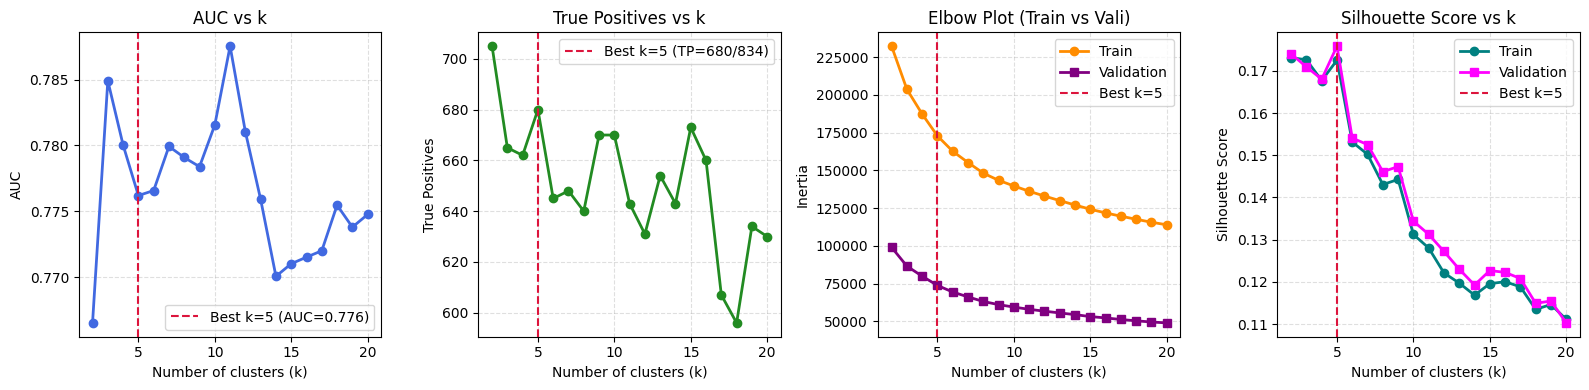

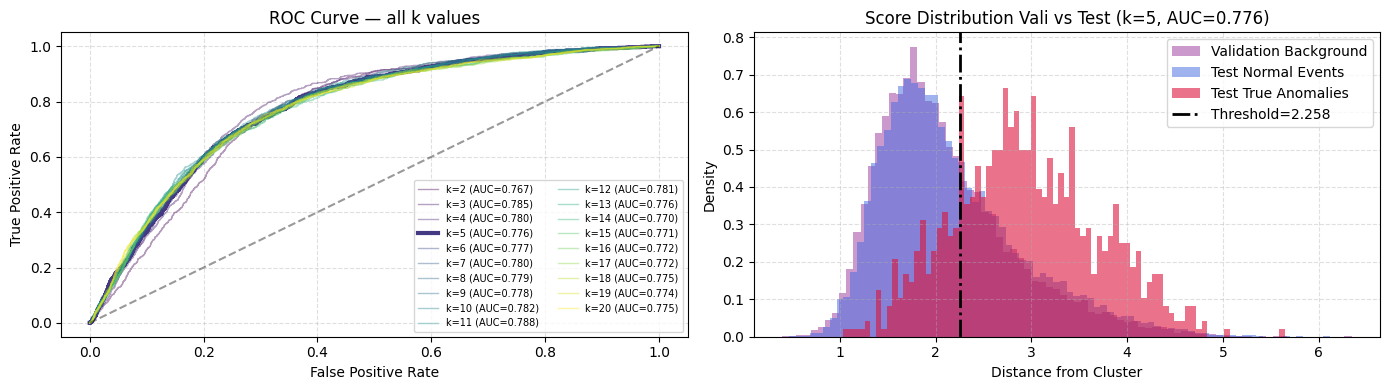

In [ ]:
#@title K-means analysis
ks       = [r['k']       for r in results]
aucs     = [r['auc']     for r in results]
inertias_val = [r['inertia'] for r in results]
inertias_train = [r.get('inertia_train', r['kmeans'].inertia_) for r in results] # Safe fallback if not in dict
sil_train = [r['sil_train'] for r in results]
sil_val   = [r['sil_val'] for r in results]
t_pos    = [r['true_positives'] for r in results]

# First row: Metrics across all k values
fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].plot(ks, aucs, marker='o', linewidth=2, color='royalblue')
axs[0].axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']} (AUC={best_kmeans_c['auc']:.3f})")
axs[0].set_xlabel("Number of clusters (k)")
axs[0].set_ylabel("AUC")
axs[0].set_title("AUC vs k")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.4)

axs[1].plot(ks, t_pos, marker='o', linewidth=2, color='forestgreen')
axs[1].axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']} (TP={best_kmeans_c['true_positives']}/{total_true_anomalies})")
axs[1].set_xlabel("Number of clusters (k)")
axs[1].set_ylabel("True Positives")
axs[1].set_title("True Positives vs k")
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.4)

axs[2].plot(ks, inertias_train, marker='o', linewidth=2, color='darkorange', label='Train')
axs[2].plot(ks, inertias_val, marker='s', linewidth=2, color='purple', label='Validation')
axs[2].axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']}")
axs[2].set_xlabel("Number of clusters (k)")
axs[2].set_ylabel("Inertia")
axs[2].set_title("Elbow Plot (Train vs Vali)")
axs[2].legend()
axs[2].grid(True, linestyle='--', alpha=0.4)

axs[3].plot(ks, sil_train, marker='o', linewidth=2, color='teal', label='Train')
axs[3].plot(ks, sil_val, marker='s', linewidth=2, color='magenta', label='Validation')
axs[3].axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']}")
axs[3].set_xlabel("Number of clusters (k)")
axs[3].set_ylabel("Silhouette Score")
axs[3].set_title("Silhouette Score vs k")
axs[3].legend()
axs[3].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##Figure below: Final performances and validation vs test scores
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(14, 4))

# --- PLOT 1: ROC Curves for all k ---
cmap = plt.cm.viridis(np.linspace(0, 1, len(results)))

for r, color in zip(results, cmap):
    lw = 3 if r['k'] == best_kmeans_c['k'] else 1
    alpha = 1.0 if r['k'] == best_kmeans_c['k'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"k={r['k']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all k values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# --- PLOT 2: Anomaly Score Distribution (Vali vs Test) for best_kmeans_c k ---
ax_hist.hist(best_kmeans_c['scores_val'], bins=80, color='purple',
             alpha=0.4, density=True, label='Validation Background')
ax_hist.hist(best_kmeans_c['scores'][true_labels == 0], bins=80, color='royalblue',
             alpha=0.5, density=True, label='Test Normal Events')
ax_hist.hist(best_kmeans_c['scores'][true_labels == 1], bins=80, color='crimson',
             alpha=0.6, density=True, label='Test True Anomalies')
ax_hist.axvline(best_kmeans_c['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_kmeans_c["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Vali vs Test (k={best_kmeans_c['k']}, AUC={best_kmeans_c['auc']:.3f})")
ax_hist.set_xlabel("Distance from Cluster")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#@title PCA
from sklearn.decomposition import PCA
import plotly.express as px

pca = PCA(n_components=3)
#@markdown Using a PCA method trained with latent-space vecotrs of the background,
#@markdown it is possibile to visualize where the anomalies are located by the Encoder
#@markdown in the most relevant 3 dimension variables.

#@markdown It is present a sufficient distinction
#@markdown bewteen Signal and Background events
pca.fit(latent_bg_train_norm)

# latent_3d_bg = pca.transform(latent_bg_norm)
latent_3d = pca.transform(latent_blackbox_norm)
cluster_centers_3d = pca.transform(best_kmeans_c['kmeans'].cluster_centers_)

true_normal_3d   = latent_3d[true_labels == 0]
true_anomaly_3d  = latent_3d[true_labels == 1]
sample_size_norm = min(10000, len(true_normal_3d))



# Create the base traces using numpy arrays directly
fig_norm = px.scatter_3d(x=true_normal_3d[:sample_size_norm, 0], y=true_normal_3d[:sample_size_norm, 1], z=true_normal_3d[:sample_size_norm, 2])
fig_anom = px.scatter_3d(x=true_anomaly_3d[:, 0], y=true_anomaly_3d[:, 1], z=true_anomaly_3d[:, 2])
fig_cent = px.scatter_3d(x=cluster_centers_3d[:, 0], y=cluster_centers_3d[:, 1], z=cluster_centers_3d[:, 2])

# Combine traces into one figure and apply styles in a single step
fig_3d = fig_norm.add_traces(list(fig_anom.data) + list(fig_cent.data))
styles = [('Normali', 'royalblue', 'circle', 2, 0.3), ('Anomalie', 'crimson', 'circle', 2, 0.4), ('Centri Cluster', 'lightgreen', 'diamond', 12, 1.0)]

for trace, (name, color, symbol, size, opacity) in zip(fig_3d.data, styles):
    trace.update(name=name, showlegend=True, marker=dict(color=color, symbol=symbol, size=size, opacity=opacity))

fig_3d.update_layout(title=f"Spazio Latente K-Means k={best_kmeans_c['k']} (PCA 3D)",
                     width=800,
                     height=400,
                     scene=dict(xaxis_title='PCA 1', yaxis_title='PCA 2', zaxis_title='PCA 3'), margin=dict(l=0, r=0, b=0, t=40))
fig_3d.show()

# Variabile kmeans aggiornata al miglior k (compatibile con il resto del notebook)
kmeans = best_kmeans_c['kmeans']
anomaly_scores = best_kmeans_c['scores']
k_clusters = best_kmeans_c['k']
roc_auc = best_kmeans_c['auc']

## III. Gaussian Mixture Model

In this section, we utilize Gaussian Mixture Models (GMM) to perform anomaly detection in the latent space. Unlike K-Means, which relies on rigid Euclidean distances, GMM models the background distribution as a mixture of $n$ multivariate Gaussian components.

The anomaly score is derived from the negative log-likelihood: points in low-density regions of the latent space are flagged as anomalies.
To select the optimal number of components ($n$), we monitor the **Bayesian Information Criterion (BIC)**.  The BIC balances model fit against complexity, penalizing overfitting. We aim for the $n$ that minimizes the BIC, ensuring a robust representation of our background data.

**Mathematical Formulation of Gaussian Mixture Models (GMM) for Anomaly Detection**

Gaussian Mixture Models (GMM) provide a probabilistic framework: by treating the "normal" background as a mixture of Gaussian distributions, GMMs capture complex, non-spherical densities in the latent space, allowing for "soft" membership that better characterizes the underlying data manifold.

**1.) The Probabilistic Framework**

We model the probability density function (PDF) of the latent space data as a weighted sum of $n$ multivariate Gaussian components. The density $p(x)$ for a sample $x$ is defined as:

$$p(x) = \sum_{i=1}^{n} \pi_i \mathcal{N}(x | \mu_i, \Sigma_i)$$

Where:

* $\pi_i$: The mixing weight of the $i$-th gaussian component, representing the probability that a point belongs to cluster $i$ (subject to $\sum \pi_i = 1$).
* $\mathcal{N}(x | \mu_i, \Sigma_i)$: The multivariate Gaussian distribution characterized by mean $\mu_i$ and covariance matrix $\Sigma_i$.

This formulation allows the model to learn not just the center of "normal" data (as K-Means does), but the shape and orientation of the background clusters through the covariance matrices $\Sigma_i$.

**2.) Anomaly Scoring via Negative Log-Likelihood**

In this generative approach, the anomaly score $S(x)$ is defined by the **negative log-likelihood** of the sample under the fitted model. Since $p(x)$ represents the probability density of a point occurring within the "normal" distribution:

$$S(x) = -\ln(p(x)) = -\ln \left( \sum_{i=1}^{n} \pi_i \mathcal{N}(x | \mu_i, \Sigma_i) \right)$$

* **Low Score:** Points that reside in high-density regions of the learned distribution (likely background) result in a large $p(x)$, yielding a small (or negative) log-likelihood.
* **High Score:** Points in low-density regions (far from any Gaussian component) result in a near-zero $p(x)$, which pushes the negative log-likelihood toward positive infinity, effectively flagging them as anomalies.

**3.) Model Selection via Bayesian Information Criterion (BIC)**

To identify the optimal number of components $n$ that balances model fit against complexity (avoiding overfitting the background noise), we utilize the **Bayesian Information Criterion (BIC)**:

$$BIC = k \ln(N) - 2 \ln(\hat{L})$$

Where:

* $N$: The number of training samples.
* $k$: The number of free parameters (determined by the number of clusters and the structure of the covariance matrices).
* $\ln(\hat{L})=\sum_{j=1}^N \ln p(x_j^{val} | \theta)$: The log of the maximized value of the likelihood function, with $\theta = \{\pi_i, \mu_i, \Sigma_i\}_{i=1}^n$

**Interpretation of the BIC Trade-off:**

* **Likelihood Term ($-2 \ln(\hat{L})$):** As we increase the number of components ($n$), the model fits the training data more closely, increasing the likelihood $\hat{L}$ and reducing this term.
* **Penalty Term ($k \ln(N)$):** This term grows with the model complexity (number of parameters). It acts as a structural penalty, preventing the model from partitioning the space into an excessive number of components.

By selecting the $n$ that minimizes the BIC, we identify the most parsimonious model—one that is complex enough to capture the true density of the background data, but simple enough to generalize reliably to new, unseen events.

In [ ]:
#@title GMM computation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc

#Cycle on numbers of components
n_min=1 #@param {type:"slider", min:1, max:10, step:1}
n_max=20  #@param {type:"slider", min:11, max:20, step:1}
verbose = True #@param {type:"boolean"}

n_values = list(range(n_min, n_max+1))
results_gmm = []

print(f"GMM loop for n_components = {n_values[0]} to n = {n_values[-1]}\n")

for n in n_values:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(latent_bg_train_norm)

    # Unsupervised BIC evaluation on train and validation sets (lower = better)
    bic_train = gmm.bic(latent_bg_train_norm)
    bic_val = gmm.bic(latent_bg_vali_norm)

    # Save validation scores for val vs test plotting step
    val_scores = -gmm.score_samples(latent_bg_vali_norm)

    # Test evaluation (For performance tracking only)
    scores = -gmm.score_samples(latent_blackbox_norm)

    fpr, tpr, thresholds = roc_curve(true_labels, scores)
    roc_auc = auc(fpr, tpr)

    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        val_scores = -val_scores
        fpr, tpr, thresholds = roc_curve(true_labels, scores)

    optimal_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[optimal_idx]
    predicted_labels = (scores >= best_threshold).astype(int)

    n_predicted = np.sum(predicted_labels == 1)
    true_positives = int(tpr[optimal_idx] * total_true_anomalies)

    results_gmm.append({
        'n': n,
        'gmm': gmm,
        'scores': scores,
        'scores_val': val_scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'threshold': best_threshold,
        'n_predicted': n_predicted,
        'true_positives': true_positives,
        'bic': bic_val,            # Saved validation BIC to mimic K-means loop structure
        'bic_train': bic_train     # Saved training BIC for comparison plots
    })
    if verbose:
        print(f"  n={n:2d} | Train BIC={bic_train:.1f} | Val BIC={bic_val:.1f} | Test AUC={roc_auc:.4f}")

# Best n selected strictly based on minimizing the Validation BIC (No Leakage)
best_gmm_c = min(results_gmm, key=lambda x: x['bic'])
print(f"---> SELECTED N: {best_gmm_c['n']}, AUC={best_gmm_c['auc']:.4f} and Val BIC={best_gmm_c['bic']:.1f}, found {best_gmm_c['true_positives']}/{total_true_anomalies} true anomalies")

roc_auc_gmm_c = best_gmm_c['auc']

GMM loop for n_components = 1 to n = 20

  n= 1 | Train BIC=759494.5 | Val BIC=324997.9 | Test AUC=0.8014
  n= 2 | Train BIC=730915.0 | Val BIC=313241.4 | Test AUC=0.7889
  n= 3 | Train BIC=708046.3 | Val BIC=303510.1 | Test AUC=0.7803
  n= 4 | Train BIC=697562.4 | Val BIC=299041.2 | Test AUC=0.7945
  n= 5 | Train BIC=693515.7 | Val BIC=297620.3 | Test AUC=0.7850
  n= 6 | Train BIC=680691.1 | Val BIC=292349.9 | Test AUC=0.7787
  n= 7 | Train BIC=681914.7 | Val BIC=293386.2 | Test AUC=0.7705
  n= 8 | Train BIC=674717.1 | Val BIC=290488.0 | Test AUC=0.7719
  n= 9 | Train BIC=671453.6 | Val BIC=289603.8 | Test AUC=0.7655
  n=10 | Train BIC=668443.8 | Val BIC=289051.2 | Test AUC=0.7628
  n=11 | Train BIC=666707.9 | Val BIC=287774.7 | Test AUC=0.7603
  n=12 | Train BIC=663761.5 | Val BIC=287585.8 | Test AUC=0.7648
  n=13 | Train BIC=661983.0 | Val BIC=286917.5 | Test AUC=0.7636
  n=14 | Train BIC=660701.1 | Val BIC=286564.3 | Test AUC=0.7668
  n=15 | Train BIC=657690.9 | Val BIC=285644.4 | 

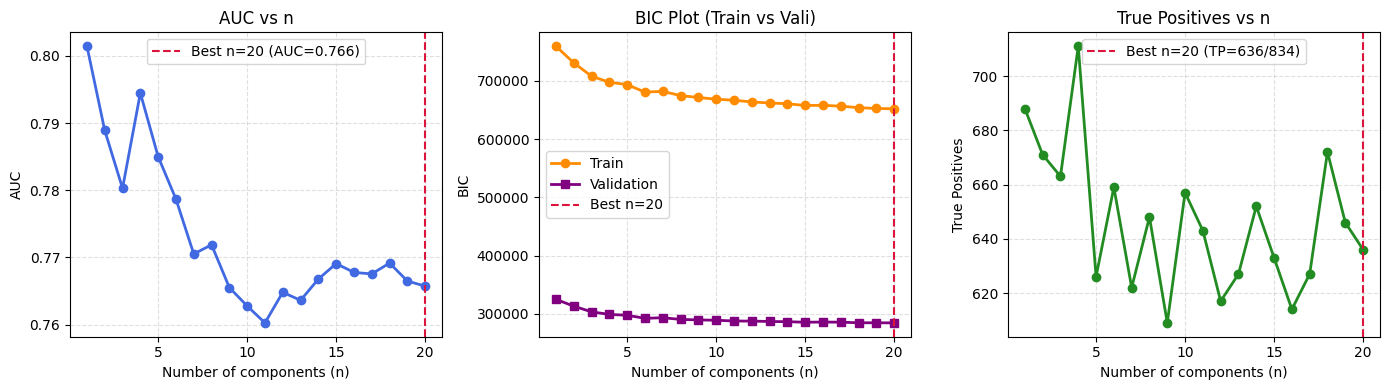

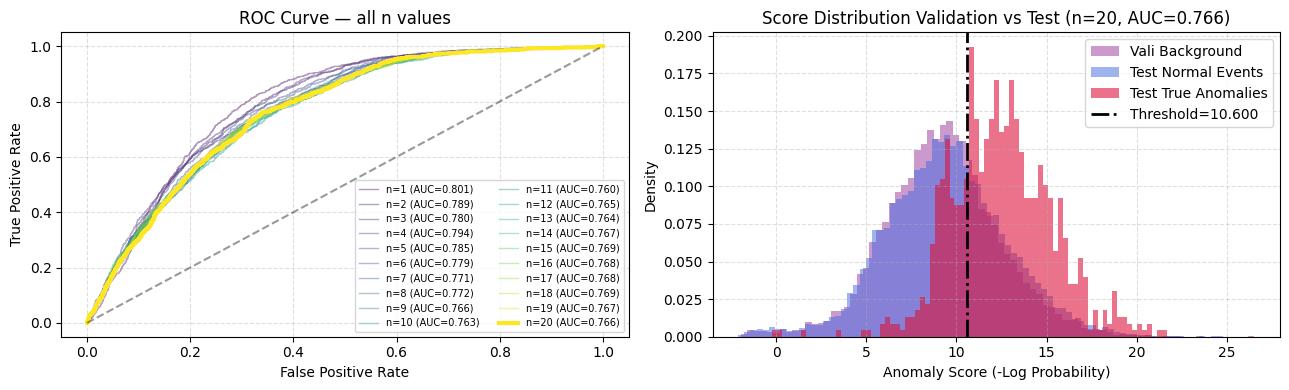

In [ ]:
#@title GMM analysis
ns       = [r['n']        for r in results_gmm]
aucs     = [r['auc']      for r in results_gmm]
bics_val = [r['bic']      for r in results_gmm]
bics_tr  = [r['bic_train'] for r in results_gmm]
t_pos    = [r['true_positives'] for r in results_gmm]

fig, (ax_auc, ax_bic, ax_tpos) = plt.subplots(1, 3, figsize=(14, 4))

ax_auc.plot(ns, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_gmm_c['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_c['n']} (AUC={best_gmm_c['auc']:.3f})")
ax_auc.set_xlabel("Number of components (n)")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs n")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(ns, t_pos, marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_gmm_c['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_c['n']} (TP={best_gmm_c['true_positives']}/{total_true_anomalies})")
ax_tpos.set_xlabel("Number of components (n)")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs n")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

ax_bic.plot(ns, bics_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_bic.plot(ns, bics_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_bic.axvline(best_gmm_c['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_c['n']}")
ax_bic.set_xlabel("Number of components (n)")
ax_bic.set_ylabel("BIC")
ax_bic.set_title("BIC Plot (Train vs Vali)")
ax_bic.legend()
ax_bic.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##Figure below
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))

# --- PLOT 1: ROC Curves for all n ---
cmap = plt.cm.viridis(np.linspace(0, 1, len(results_gmm)))

for r, color in zip(results_gmm, cmap):
    lw = 3 if r['n'] == best_gmm_c['n'] else 1
    alpha = 1.0 if r['n'] == best_gmm_c['n'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"n={r['n']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all n values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# --- PLOT 2: Anomaly Score Distribution for best n ---
ax_hist.hist(best_gmm_c['scores_val'], bins=80, color='purple',
             alpha=0.4, density=True, label='Vali Background')
ax_hist.hist(best_gmm_c['scores'][true_labels == 0], bins=80, color='royalblue',
             alpha=0.5, density=True, label='Test Normal Events')
ax_hist.hist(best_gmm_c['scores'][true_labels == 1], bins=80, color='crimson',
             alpha=0.6, density=True, label='Test True Anomalies')
ax_hist.axvline(best_gmm_c['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_gmm_c["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Validation vs Test (n={best_gmm_c['n']}, AUC={best_gmm_c['auc']:.3f})")
ax_hist.set_xlabel("Anomaly Score (-Log Probability)")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 3.) Unsupervised Quantum Kernel Method



In this section, we implement the core quantum component of the pipeline: an **Unsupervised Quantum Kernel Machine**.

The central idea is to exploit the exponentially large Hilbert space accessible via quantum circuits to define a similarity measure between data points that would be intractable to compute classically. Rather than learning a parametric model, the quantum kernel encodes data into quantum states and measures their **fidelity** — i.e., the overlap between two quantum states — as a proxy for similarity.

The approach is fully unsupervised: the kernel is trained exclusively on **Standard Model (QCD) background events** in the latent space produced by the Autoencoder. Anomalous BSM events, being out-of-distribution, are expected to produce low kernel fidelity with the background training set, making them detectable.

The pipeline in this section proceeds as follows:
1. **Quantum Feature Map**: A parameterized quantum circuit encodes each latent vector into a quantum state.
2. **Kernel Matrix Computation**: The fidelity between all pairs of quantum states is computed, yielding a kernel matrix.
3. **Inference**: Classical algorithms (One-Class SVM, Kernel PCA + K-Means, Kernel PCA + GMM) operate on the precomputed kernel matrix to identify anomalies.


In [ ]:
!pip install --upgrade qiskit qiskit-machine-learning qiskit-algorithms
!pip install matplotlib qiskit[visualization]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 89.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 14.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=930e36589aff9fdf14d864b3d75a3bfd683eade5723fba771b0388b92d22d425
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## Quantum Feature Map


---
The code implements a **Feature Map**, a technique that transforms classical data into a Hilbert space using a parameterized quantum circuit.

1. Definition and Parameterization

* **`ParameterVector('x', lat_dim)`**: Instead of using static values, Qiskit creates a vector of "symbols." These symbols act as placeholders (variables) that are later populated by the real values from your 8-dimensional latent space data.
* **`lat_dim`** and **`n_q`**: We are utilizing number of qubits equal to the latent dimension of our autoencoder. Mapping one feature to one qubit is a direct encoding strategy that maximizes the circuit's expressivity.

 2. The Core: The `.u` Gate

The `u(theta, phi, lambda)` gate is a **single-qubit universal rotation gate**. It is one of the most powerful tools in Qiskit because it can rotate a qubit to any arbitrary state on the Bloch Sphere.

* **Mathematical Definition**: The $U(\theta, \phi, \lambda)$ gate is represented by the matrix:

$$U(\theta, \phi, \lambda) = \begin{pmatrix} \cos(\theta/2) & -e^{i\lambda}\sin(\theta/2) \\ e^{i\phi}\sin(\theta/2) & e^{i(\phi+\lambda)}\cos(\theta/2) \end{pmatrix}$$


* **Implementation in the code**:
* In **Layer 1**, we use `u(pi/2, x[idx1], x[idx2], i)`. By setting $\theta = \pi/2$, we force the qubit into a specific superposition determined by your feature values $x$.
* The **Modulo operator (`%`)** (`(i + 1) % lat_dim`) creates a **circular connection**. When the loop reaches the final qubit ($x_7$), it "wraps" back to the first ($x_0$), creating cross-dependencies that help the model capture complex correlations between features.

3. Entanglement

**Layer 2** utilizes **CNOT gates (`cx`)**. This is the critical stage where qubits stop being independent and begin to share information. Entanglement is what allows the Quantum Kernel to capture non-linear correlations between the  features.

---

--- FEATURE MAP GENERATED, numbers of layers: L = 6, numbers of Qubits = 8) ---


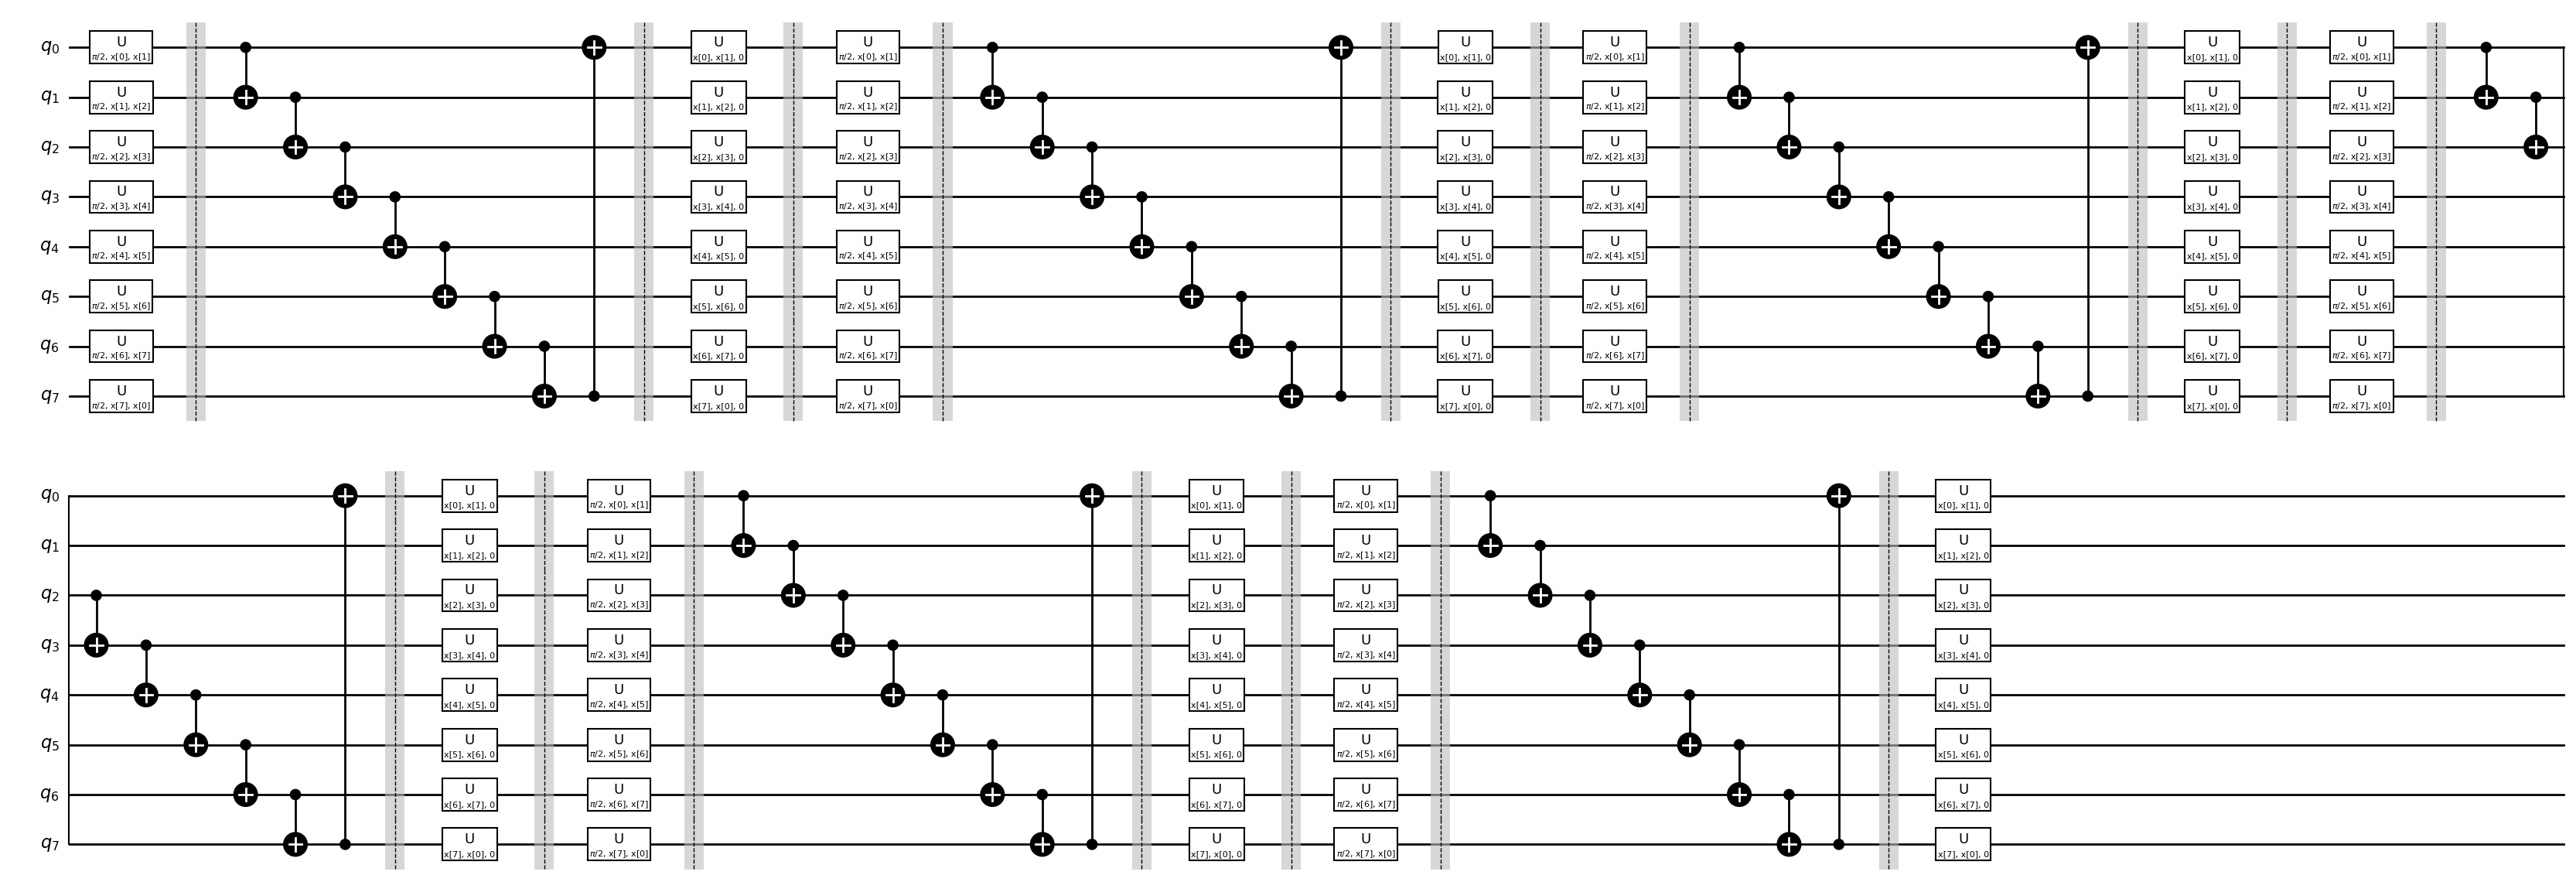

In [ ]:
#@title Creation and Visualization
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.visualization import circuit_drawer

# =====================================================================
# QUANTUM FEATURE MAP
# =====================================================================
# A parameterized quantum circuit that encodes each classical data point
# (a latent vector of dimension lat_dim) into a quantum state |phi(x)>.
#
# The resulting state defines an implicit mapping into a high-dimensional
# Hilbert space H, where the kernel function is:
#   K(x_i, x_j) = |<phi(x_i)|phi(x_j)>|^2
#
# This is known as the "fidelity kernel" or "quantum kernel".

# 1. PARAMETER VECTOR
# Each component x[i] of the latent vector becomes a rotation angle.
# Using symbolic parameters allows Qiskit to compile and optimize
# the circuit once, then evaluate it efficiently for many data points.

# 2. CIRCUIT STRUCTURE: L repeated layers, each consisting of:
#    - Layer 1: Universal single-qubit rotations U(pi/2, x[i], x[i+1])
#               -> Places each qubit in a data-dependent superposition
#               -> The modulo operator (i+1) % lat_dim creates circular
#                  feature dependencies (last qubit uses x[0])
#    - Layer 2: Linear CNOT entanglement between adjacent qubits
#               -> Creates quantum correlations between features,
#                  enabling the kernel to capture non-linear interactions
#               -> Without entanglement, qubits evolve independently
#                  and the kernel reduces to a product of 1D kernels
#    - Layer 3: Second rotation block U(x[i], x[i+1], 0)
#               -> Applies a second data-dependent rotation to increase
#                  the expressivity of the feature map

# 3. TANH NORMALIZATION OF LATENT VECTORS
# The Autoencoder's Tanh output constrains latent features to [-1, 1],
# which maps naturally to rotation angles in [-pi, pi] (via the U gate).
# This avoids phase-wrapping artifacts in the quantum encoding.

# 1. Main parameter definition
# Automatically uses the 8 columns of your latent space
n_q = lat_dim                # 1 qubit per feature
L = 6      #@param {type:"slider", min: 2, max: 10, step: 1}
                   # Circuit depth (number of repetitions)

# 2. Create the symbolic parameter vector (x0, x1, ..., x7)
x = ParameterVector('x', lat_dim)

# 3. Construct the Feature Map
feature_map = QuantumCircuit(n_q)

normfactor= 1
# Repeat the entire map 'L' times in cascade
for layer in range(L):

    # --- LAYER 1: First rotation block -> G(pi/2, phi, lambda) ---
    for i in range(n_q):
        idx1 = i
        idx2 = (i + 1) % lat_dim   # Modulo operator wraps x7 back to x0
        feature_map.u(np.pi / 2, x[idx1] /normfactor, x[idx2] /normfactor, i)

    feature_map.barrier()

    # --- LAYER 2: Linear entanglement (CNOT gates between adjacent qubits) ---
    for i in range(n_q):
        feature_map.cx(i, (i + 1)% n_q)

    feature_map.barrier()

    # --- LAYER 3: Second rotation block -> G(theta, phi, 0) ---
    for i in range(n_q):
        idx1 = i
        idx2 = (i + 1) % lat_dim   # Maintain the same consistent shift
        feature_map.u(x[idx1] /normfactor , x[idx2] /normfactor, 0, i)

    # Layer barrier (if not the last layer)
    if layer < L - 1:
        feature_map.barrier()

# 4. Initialize the Quantum Kernel
fidelity_kernel = FidelityQuantumKernel(feature_map=feature_map)

print(f"--- FEATURE MAP GENERATED, numbers of layers: L = {L}, numbers of Qubits = {n_q}) ---")
fig = circuit_drawer(feature_map, output='mpl', style='bw', fold=50, scale=1)
display(fig)

## Train Kernel Matrix

In Quantum Machine Learning, the Kernel Matrix  is the central object that bridges the gap between quantum circuits and classical machine learning algorithms (like a Support Vector Machine).

Definition: Each element $K_{ij}$ of the matrix represents the "similarity" or "fidelity" between two quantum states, $\phi(\mathbf{x}_i)$ and $\phi(\mathbf{x}_j)$, generated by the feature map for the input data points $\mathbf{x}_i$ and $\mathbf{x}_j$.The Math: It computes $K_{ij} = |\langle\phi(\mathbf{x}_i)|\phi(\mathbf{x}_j)\rangle|^2$.

**Properties of the kernel matrix:**
- The diagonal is always $1.0$ (a state has perfect fidelity with itself)
- Off-diagonal values in $[0, 1]$ measure pairwise similarity
- A **flat kernel** (all values close to the mean, low variance) is a warning sign: it indicates that the feature map has insufficient expressivity to distinguish different data points

In [ ]:
seed=242

In [ ]:
#@title Quantum Data preparation
import numpy as np
from sklearn.preprocessing import MinMaxScaler

background_indices = np.where(true_labels == 0)[0]
anomaly_indices    = np.where(true_labels == 1)[0]

TOTAL_EVENTS = 40 #@param {type: 'slider', min: 10 , max: 600, step: '10'}
TOTAL_EVENTS_TEST = 200 #@param {type: 'slider', min: 10 , max: 1000, step: '10'}
fraction_of_anomalies= 0.5 #@param {type: 'slider', min: 0.05 , max: 0.5, step: '0.05'}
n_anomalies = int(fraction_of_anomalies*(TOTAL_EVENTS_TEST))
n_bg        = TOTAL_EVENTS_TEST - n_anomalies

np.random.seed(seed)
selected_bg_indices = np.random.choice(background_indices, n_bg, replace=False)
#######################################################################
# Create the selected anomaly indices from the test set
selected_anomaly_indices = np.random.choice(anomaly_indices, n_anomalies, replace=False)

print(f"Selected {len(selected_anomaly_indices)} anomaly events and {len(selected_bg_indices)} background events")

quantum_test_indices = np.concatenate([selected_bg_indices, selected_anomaly_indices])
np.random.shuffle(quantum_test_indices)


##################################################################
total_bg_needed = 2 * TOTAL_EVENTS #validation and train same size
all_train_val_indices = np.random.choice(len(latent_bg), total_bg_needed, replace=False)

quantum_train_indices = all_train_val_indices[:TOTAL_EVENTS]
quantum_vali_indices  = all_train_val_indices[TOTAL_EVENTS:]
#################################################################
latent_train_reduced = latent_bg[quantum_train_indices]
latent_vali_reduced = latent_bg[quantum_vali_indices]
latent_test_reduced = latent_blackbox[quantum_test_indices]
true_labels_reduced = true_labels[quantum_test_indices]

print(f"Quantum training set (final): {latent_train_reduced.shape}")
print(f"Quantum validation set (final): {latent_vali_reduced.shape}")
print(f"Quantum test set (final)    : {latent_test_reduced.shape}")

Selected 100 anomaly events and 100 background events
Quantum training set (final): (40, 8)
Quantum validation set (final): (40, 8)
Quantum test set (final)    : (200, 8)


In [ ]:
#@title Kernal matrix computation for train dataset
# This command takes the feature map, replaces the 'x' parameters with the latent_bg numbers,
# and executes the circuits to provide the final matrix.
print("Calculating the Kernel matrix for training")
kernel_matrix_train = fidelity_kernel.evaluate(x_vec=latent_train_reduced)

print("\n--- TRAINING KERNEL MATRIX GENERATED ---")
print(f"Matrix shape: {kernel_matrix_train.shape}") # It will be an N_train x N_train matrix with 1.0 on the diagonal

Calculating the Kernel matrix for training

--- TRAINING KERNEL MATRIX GENERATED ---
Matrix shape: (40, 40)


In [ ]:
#@title Kernel matrix computation for validation dataset
print("Calculating the Kernel matrix for validation (Vali projected on Train)")
kernel_matrix_vali = fidelity_kernel.evaluate(x_vec=latent_vali_reduced, y_vec=latent_train_reduced)

print("\n--- VALIDATION KERNEL MATRIX GENERATED ---")
print(f"Matrix shape: {kernel_matrix_vali.shape}") # It will be an N_val x N_train matrix

Calculating the Kernel matrix for validation (Vali projected on Train)

--- VALIDATION KERNEL MATRIX GENERATED ---
Matrix shape: (40, 40)


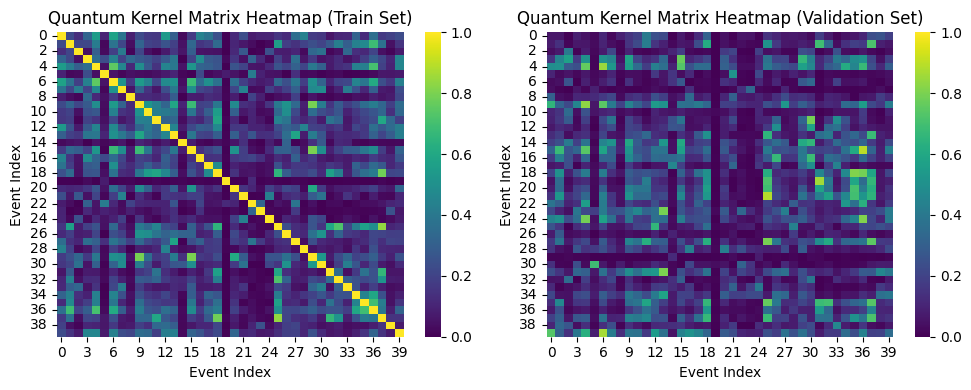

--- TRAIN KERNEL STATISTICS ---
Kernel values mean : 0.2045 
Kernel variance    : 0.0419 (If close to 0, the kernel is 'flat')

--- VALIDATION KERNEL STATISTICS ---
Kernel values mean : 0.1718 
Kernel variance    : 0.0308 (If close to 0, the kernel is 'flat')


In [ ]:
#@title Heatmap of the Kernel Matrix (Train vs Vali)
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax_train, ax_vali) = plt.subplots(1, 2, figsize=(10, 4))

# We use vmin=0 and vmax=1 because quantum kernel probabilities are in the [0, 1] range
sns.heatmap(kernel_matrix_train, cmap='viridis', vmin=0, vmax=1, ax=ax_train)
ax_train.set_title("Quantum Kernel Matrix Heatmap (Train Set)")
ax_train.set_xlabel("Event Index")
ax_train.set_ylabel("Event Index")

sns.heatmap(kernel_matrix_vali, cmap='viridis', vmin=0, vmax=1, ax=ax_vali)
ax_vali.set_title("Quantum Kernel Matrix Heatmap (Validation Set)")
ax_vali.set_xlabel("Event Index")
ax_vali.set_ylabel("Event Index")

plt.tight_layout()
plt.show()

# Statistics for Train Set
kernel_mean = np.mean(kernel_matrix_train)
kernel_var = np.var(kernel_matrix_train)
print("--- TRAIN KERNEL STATISTICS ---")
print(f"Kernel values mean : {kernel_mean:.4f} ")
print(f"Kernel variance    : {kernel_var:.4f} (If close to 0, the kernel is 'flat')\n")

# Statistics for Validation Set
kernel_mean_val = np.mean(kernel_matrix_vali)
kernel_var_val = np.var(kernel_matrix_vali)
print("--- VALIDATION KERNEL STATISTICS ---")
print(f"Kernel values mean : {kernel_mean_val:.4f} ")
print(f"Kernel variance    : {kernel_var_val:.4f} (If close to 0, the kernel is 'flat')")

## Test kernel matrix

In [ ]:
#@title Test Kernel Matrix computation (~15min)
print("Starting the calculation of the Test Kernel matrix")
print("This operation may take a few minutes\n")

# CALCULATION OF THE TEST MATRIX
# Note on parameters:
# x_vec = the new data points we want to classify (Test)
# y_vec = the historical data the model has already studied (Train)
kernel_matrix_test = fidelity_kernel.evaluate(x_vec=latent_test_reduced, y_vec=latent_train_reduced)

print("--- TEST KERNEL MATRIX GENERATED SUCCESSFULLY! ---")

# Printing the dimensions for verification
print(f"Matrix shape: {kernel_matrix_test.shape}")

Starting the calculation of the Test Kernel matrix
This operation may take a few minutes

--- TEST KERNEL MATRIX GENERATED SUCCESSFULLY! ---
Matrix shape: (200, 40)


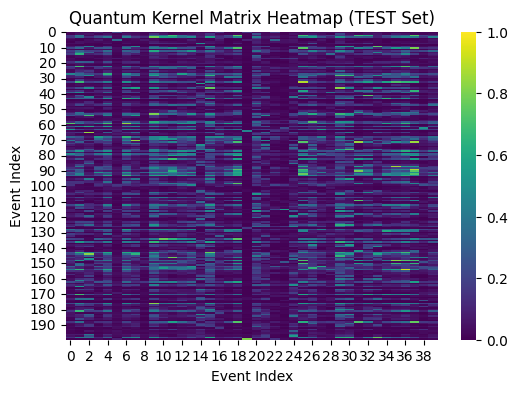

Kernel values mean : 0.1082
Kernel variance    : 0.0199 (If close to 0, the kernel is 'flat')


In [ ]:
#@title Heatmap of the Kernel Matrix for Test
plt.figure(figsize=(6, 4))
sns.heatmap(kernel_matrix_test, cmap='viridis', vmin=0, vmax=1)
plt.title("Quantum Kernel Matrix Heatmap (TEST Set)")
plt.xlabel("Event Index")
plt.ylabel("Event Index")
plt.show()

kernel_mean = np.mean(kernel_matrix_test)
kernel_var = np.var(kernel_matrix_test)
print(f"Kernel values mean : {kernel_mean:.4f}")
print(f"Kernel variance    : {kernel_var:.4f} (If close to 0, the kernel is 'flat')")

## Inference

### I. SVM with quantum kernel


**Mathematical Formulation of One-Class Support Vector Machines**

In the unsupervised scenario, the goal of the One-Class SVM is to identify a boundary that encapsulates the "normal" training dataset, effectively isolating anomalies. Geometrically, the objective is to find a hyperplane in the feature space ($\mathcal{F}$) that maximizes the distance from the coordinate origin to the normal data points.

**1. The Unsupervised Primal Problem**

To construct this boundary, we define a **decision function $f(x) = \vec{w} \cdot \vec{\phi}(x) - \rho$**, where $\rho \in \mathbb{R}$ represents the distance of the hyperplane from the origin.
By introducing slack variables $\xi_i \geq 0$ to tolerate a specific ratio of training errors, the Primal Objective Function is formulated as:
$$\min_{\vec{w}, \vec{\xi}, \rho} \frac{1}{2} \Vert{}\vec{w}\Vert{}^2 + \frac{1}{\nu N} \sum_{i=1}^{N} \xi_i - \rho$$
Subject to the following constraints for each data training point $i \in [1, N]$:

   1. $\vec{w} \cdot \vec{\phi}(x_i) \geq \rho - \xi_i \implies \rho - \vec{w} \cdot \vec{\phi}(x_i) - \xi_i \leq 0$
   2. $\xi_i \geq 0$


Where $\nu \in (0, 1]$ is the classical hyperparameter that establishes an upper bound on the fraction of training errors (anomalies) and a lower bound on the number of support vectors.

**Interpretation via the Decision Function $f(x)$:**
* **Inliers ($f(x_i) \geq 0$):** When a data point is correctly classified as part of the normal operational class, its projection lies on or above the hyperplane ($\vec{w} \cdot \vec{\phi}(x_i) \geq \rho$). In this case, no error is generated, and the slack variable vanishes ($\xi_i = 0$).
* **Outliers/Anomalies ($f(x_i) < 0$):** When a data point falls on the wrong side of the hyperplane (closer to the origin than the boundary $\rho$), it violates the margin. To satisfy Constraint 1, the model activates the slack variable ($\xi_i > 0$) to quantify the distance of this error, while Constraint 2 ensures that this tolerated error remains strictly non-negative.



**2. Defining the Lagrangian Function**

By introducing two sets of non-negative Lagrangian multipliers, $\alpha_i \geq 0$ and $\beta_i \geq 0$, to enforce the structural constraints, we construct the Lagrangian function $L$:
$$L(\vec{w}, \rho, \vec{\xi}, \vec{\alpha}, \vec{\beta}) = \frac{1}{2} \Vert{}\vec{w}\Vert{}^2 + \frac{1}{\nu N} \sum_{i=1}^{N} \xi_i - \rho - \sum_{i=1}^{N} \alpha_i \left[ \vec{w} \cdot \vec{\phi}(x_i) - \rho + \xi_i \right] - \sum_{i=1}^{N} \beta_i \xi_i$$


**3. Computing Partial Derivatives (Optimality Conditions)**

To solve the optimization problem, we minimize the Lagrangian with respect to the primal variables ($\vec{w}, \rho, \vec{\xi}$) by setting their partial derivatives to zero:

A) Derivative with respect to the weight vector $\vec{w}$
$$\frac{\partial L}{\partial \vec{w}} = \vec{w} - \sum_{i=1}^{N} \alpha_i \vec{\phi}(x_i) = 0 \implies \vec{w} = \sum_{i=1}^{N} \alpha_i \vec{\phi}(x_i)$$

B) Derivative with respect to the parameter $\rho$
$$\frac{\partial L}{\partial \rho} = -1 + \sum_{i=1}^{N} \alpha_i = 0 \implies \sum_{i=1}^{N} \alpha_i = 1$$

C) Derivative with respect to the slack variable $\xi_i$
$$\frac{\partial L}{\partial \xi_i} = \frac{1}{\nu N} - \alpha_i - \beta_i = 0 \implies \alpha_i + \beta_i = \frac{1}{\nu N}$$

**4. Transition to the Dual Problem**

By substituting the optimal conditions derived above back into the Lagrangian function, the primal variables are successfully eliminated:

* Substituting $\vec{w} = \sum_i \alpha_i \vec{\phi}(x_i)$ replaces the weight norms with inner products.
* The constraints $\sum_i \alpha_i = 1$ and $\alpha_i + \beta_i = \frac{1}{\nu N}$ cancel out the linear terms for $\rho$ and $\xi_i$.

This mathematical reduction yields the Dual Optimization Problem, which is a maximization task over the multipliers $\vec{\alpha}$:
$$\max_{\vec{\alpha}} \left( -\frac{1}{2} \sum_{i,j=1}^{N} \alpha_i \alpha_j K(x_i, x_j) \right)$$
Subject to the bounding constraints:

* $0 \leq \alpha_i \leq \frac{1}{\nu N} \quad$ (Since $\beta_i \geq 0$ and $\alpha_i + \beta_i = \frac{1}{\nu N}$)
* $\sum_{i=1}^{N} \alpha_i = 1$

Where $K(x_i, x_j) = \vec{\phi}(x_i) \cdot \vec{\phi}(x_j)$ is the Kernel matrix evaluated over the training samples ($x_i$ and $x_j$).


**Interpretation of Support Vectors**

According to optimization theory, for any inequality constraint $(g_k(x) \leq 0)$ with a multiplier $(\lambda_k \geq 0)$, the optimal solution must satisfy the complementary slackness condition:$(\lambda _{k}\cdot g_{k}(x)=0)$.

In this case, the variables must satisfy:
$$\alpha_i \left[ \vec{w} \cdot \vec{\phi}(x_i) - \rho + \xi_i \right]=\alpha_i \left[ f(x_i) + \xi_i \right]  = 0$$
This dictates the final **geometric behavior** of the system:

* If $\vec{w} \cdot \vec{\phi}(x_i) > \rho$, the data points are inside the boundary, meaning they belong to the normal distribution dataset ($\alpha_i = 0$).
* If $\vec{w} \cdot \vec{\phi}(x_i) \leq \rho$, the points fall on the border or inside the margin (**$\alpha_i > 0$**), which mathematically defines the **Support Vectors**.

In the provided code, **Inertia** acts as an unsupervised metric, calculated as the sum of squared decision scores on the validation set:


$$I_{val} = \sum \left(\text{score}(x_i)\right)^2$$


where the score is the output of the `decision_function`. It quantifies how far validation points fall from the learned normal boundary. As $\nu$ increases, the validation inertia shifts from a low, flat baseline where the boundary is loosely oversized, reaching an optimal 'elbow' that perfectly frames the true data distribution, right before exploding upward as the boundary becomes excessively tight and begins mass-rejecting healthy normal data

To select the optimal $\nu$ without relying on test labels (preventing data leakage), the code uses the **Elbow Method**. It identifies the threshold right before the model starts overfitting by finding the sharpest turn in the inertia curve. The code algorithmically detects this "elbow" by locating the maximum of the second discrete difference (`np.diff(..., n=2)`):


$$\text{Best Index} = \arg\max \left(\Delta^2 I_{val}\right) + 1$$


This mathematically pinpoints the exact $\nu$ where the rate of change of the slope is maximized.

In [ ]:
#@title ONE-CLASS Quantum SVM Computation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, auc

# range of nu hyperparameters to test
nus = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

results = []

print(f"One-Class SVM loop for nu values...")

# Loop over different nu values
for nu in nus:
    svm_q = OneClassSVM(kernel='precomputed', nu=nu)
    svm_q.fit(kernel_matrix_train)

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    # kernel_matrix_vali shape: (n_samples_val, n_samples_train)
    score_val = -svm_q.decision_function(kernel_matrix_vali)
    val_inertia = np.sum(np.square(score_val)) # Total squared distance on validation set

    # Train evaluation inertia extraction
    score_train = -svm_q.decision_function(kernel_matrix_train)
    train_inertia = np.sum(np.square(score_train))

    score_svm_q = -svm_q.decision_function(kernel_matrix_test)
    #By default, the decision_function returns positive values for inliers
    #  (data points that the model identifies as similar to the background training set) and negative values for outliers (anomalies)

    fpr_q, tpr_q, thresholds_q = roc_curve(true_labels_reduced, score_svm_q)
    auc_svm_q = auc(fpr_q, tpr_q)

    if auc_svm_q < 0.5:
        auc_svm_q = 1 - auc_svm_q
        score_svm_q = -score_svm_q
        score_val = -score_val
        fpr_q, tpr_q, thresholds_q = roc_curve(true_labels_reduced, score_svm_q)
    # ------------------------------------------------------

    # Calculate optimal threshold using Youden's J statistic (max TPR - FPR)
    idx_optimal = np.argmax(tpr_q - fpr_q)
    optimal_threshold = thresholds_q[idx_optimal]

    # Calculate True Positives at this specific threshold
    predicted_anomalies = score_svm_q >= optimal_threshold
    true_positives = np.sum((predicted_anomalies == 1) & (true_labels_reduced == 1))

    # Store results for plotting
    res = {
        'nu': nu,
        'auc': auc_svm_q,
        'fpr': fpr_q,
        'tpr': tpr_q,
        'scores': score_svm_q,
        'scores_val': score_val,
        'threshold': optimal_threshold,
        'true_positives': true_positives,
        'inertia': val_inertia,
        'inertia_train': train_inertia
    }
    results.append(res)

    print(f"  nu={nu:.2f} | Train Inertia={train_inertia:.1f} | Val Inertia={val_inertia:.1f} | Test AUC={auc_svm_q:.4f}")

# Unsupervised selection via Validation Inertia Elbow using np.diff()
# Alternative: if you want to force the paper choice, use: best_svm_q = results[0] (since nus[0] is 0.01)
inertia_values_val = [r['inertia'] for r in results]

# Calculate the second discrete difference (rate of change of the slope)
second_derivative = np.diff(inertia_values_val, n=2)

# The peak of the second derivative corresponds to the sharpest turn (the elbow).
# We add 1 to the index because np.diff(..., n=2) reduces the array size by 2,
# and the elbow is the point separating the two differences.
best_idx = np.argmax(second_derivative) + 1
best_svm_q = results[best_idx]

print(f"\n---> SELECTED NU (via Unsupervised Validation Elbow): {best_svm_q['nu']}, AUC={best_svm_q['auc']:.4f} and Val Inertia={best_svm_q['inertia']:.1f}")

One-Class SVM loop for nu values...
  nu=0.01 | Train Inertia=0.0 | Val Inertia=0.0 | Test AUC=0.8048
  nu=0.05 | Train Inertia=0.1 | Val Inertia=0.2 | Test AUC=0.8048
  nu=0.10 | Train Inertia=0.2 | Val Inertia=0.8 | Test AUC=0.8048
  nu=0.15 | Train Inertia=0.5 | Val Inertia=1.9 | Test AUC=0.8048
  nu=0.20 | Train Inertia=0.8 | Val Inertia=3.4 | Test AUC=0.8049
  nu=0.30 | Train Inertia=2.0 | Val Inertia=7.9 | Test AUC=0.8034
  nu=0.40 | Train Inertia=4.8 | Val Inertia=18.4 | Test AUC=0.8003
  nu=0.50 | Train Inertia=12.7 | Val Inertia=43.9 | Test AUC=0.8008

---> SELECTED NU (via Unsupervised Validation Elbow): 0.4, AUC=0.8003 and Val Inertia=18.4


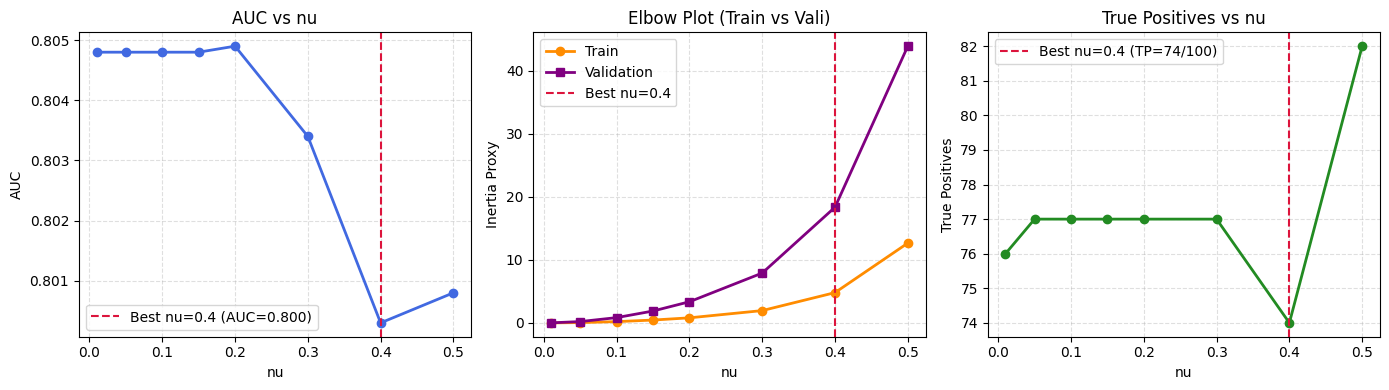

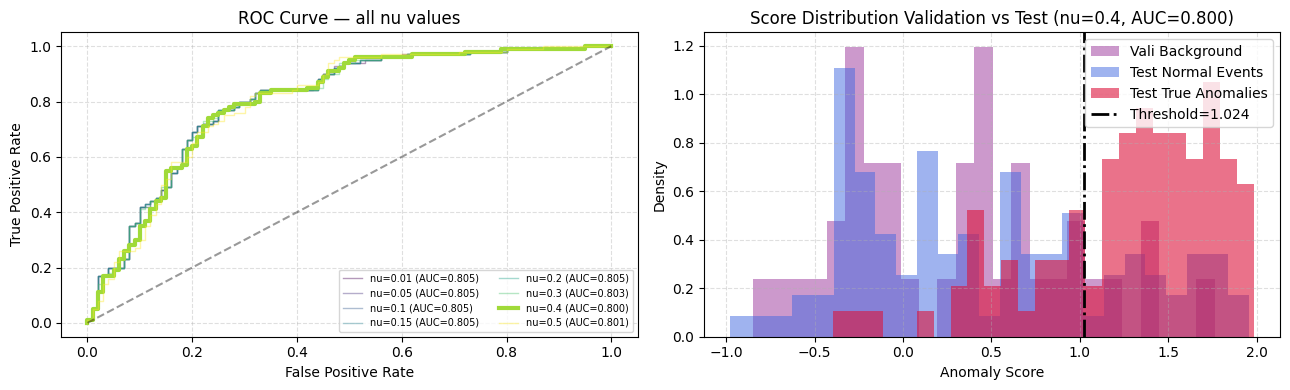

In [ ]:
#@title QUANTUM - One-Class SVM analysis
import matplotlib.pyplot as plt
import numpy as np

nus_plot     = [r['nu']            for r in results]
aucs         = [r['auc']           for r in results]
inertias_tr  = [r['inertia_train'] for r in results]
inertias_val = [r['inertia']       for r in results]
t_pos        = [r['true_positives'] for r in results]

# Plot performance metrics vs nu
fig, (ax_auc, ax_in, ax_tpos) = plt.subplots(1, 3, figsize=(14, 4))

ax_auc.plot(nus_plot, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_svm_q['nu'], color='crimson', linestyle='--', label=f"Best nu={best_svm_q['nu']} (AUC={best_svm_q['auc']:.3f})")
ax_auc.set_xlabel("nu")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs nu")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(nus_plot, t_pos, marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_svm_q['nu'], color='crimson', linestyle='--', label=f"Best nu={best_svm_q['nu']} (TP={best_svm_q['true_positives']}/{np.sum(true_labels_reduced == 1)})")
ax_tpos.set_xlabel("nu")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs nu")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

ax_in.plot(nus_plot, inertias_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_in.plot(nus_plot, inertias_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_in.axvline(best_svm_q['nu'], color='crimson', linestyle='--', label=f"Best nu={best_svm_q['nu']}")
ax_in.set_xlabel("nu")
ax_in.set_ylabel("Inertia Proxy")
ax_in.set_title("Elbow Plot (Train vs Vali)")
ax_in.legend()
ax_in.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Figure below: ROC and Histograms
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))

cmap = plt.cm.viridis(np.linspace(0, 1, len(results)))

for r, color in zip(results, cmap):
    lw = 3 if r['nu'] == best_svm_q['nu'] else 1
    alpha = 1.0 if r['nu'] == best_svm_q['nu'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"nu={r['nu']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all nu values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# Score Distribution for best nu
ax_hist.hist(best_svm_q['scores_val'], bins=25, color='purple',
             alpha=0.4, density=True, label='Vali Background')
ax_hist.hist(best_svm_q['scores'][true_labels_reduced == 0], bins=25, color='royalblue',
             alpha=0.5, density=True, label='Test Normal Events')
ax_hist.hist(best_svm_q['scores'][true_labels_reduced == 1], bins=25, color='crimson',
             alpha=0.6, density=True, label='Test True Anomalies')
ax_hist.axvline(best_svm_q['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_svm_q["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Validation vs Test (nu={best_svm_q['nu']}, AUC={best_svm_q['auc']:.3f})")
ax_hist.set_xlabel("Anomaly Score")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### II. KERNEL **PCA**


After constructing the quantum kernel matrix, a **Kernel Principal Component Analysis (KPCA)** is performed to obtain a compact representation of the data in the quantum feature space. Unlike standard PCA, which identifies directions of maximum variance in the original feature space, KPCA operates in a potentially high-dimensional feature space $\mathcal{F}$ induced by a nonlinear mapping

$$
\phi : \mathcal{X} \rightarrow \mathcal{F}.
$$

The objective is to identify the principal directions that capture the largest variance of the dataset in $\mathcal{F}$ while avoiding the explicit computation of the mapping $\phi(x)$.

**1. Covariance Matrix in Feature Space**

Consider a dataset composed of $N$ samples

$$
{x_1,x_2,\ldots,x_N}.
$$

Assuming that the mapped data are centered in feature space, the covariance matrix is defined as

$$
C = \frac{1}{N}\sum_{i=1}^{N}\phi(x_i)\phi(x_i)^T.
$$

The principal components correspond to the eigenvectors $v$ satisfying the eigenvalue equation

$$
Cv = \lambda v,
$$

where $\lambda$ represents the variance explained by the corresponding principal direction.

**2. Expressing the Eigenvectors in Terms of Training Samples**

Since the covariance matrix is constructed exclusively from the training samples, every eigenvector $v$ belongs to the span of the mapped data points:

$$
v=\sum_{i=1}^{N}\alpha_i\phi(x_i).
$$

Substituting this expansion into the eigenvalue equation yields

$$\lambda
\sum_{i=1}^{N}
\alpha_i
\phi(x_i).
$$

Taking the inner product with $\phi(x_k)$ on both sides gives

$$\lambda
\sum_{i=1}^{N}
\alpha_i K(x_k,x_i),
$$

where

$$\phi(x_i)\cdot\phi(x_j)
$$

is the kernel function.

**3. Definition of the Kernel Matrix**

The kernel trick allows the computation of inner products in feature space without explicitly evaluating the mapping $\phi(x)$.The eigenvalue problem can be rewritten in compact form as

$$
K\alpha = N\lambda\alpha,
$$

where

$$
\alpha =
(\alpha_1,\alpha_2,\ldots,\alpha_N)^T.
$$

Therefore, instead of diagonalizing the covariance matrix in feature space, KPCA only requires the eigendecomposition of the kernel matrix.

**4. Centering the Kernel Matrix**

To correctly compute the principal components, the data must be centered in feature space. Since the mapping $\phi(x)$ is generally unknown, centering is performed directly on the kernel matrix.

The final eigenvalue problem becomes

$$
K_c \alpha = N\lambda\alpha.
$$

The eigenvectors associated with the largest eigenvalues correspond to the principal directions of the dataset in the feature space.

**5. Projection onto the Principal Components**

Once the eigenvectors have been computed, a sample $x$ can be projected onto the $m$-th principal component through
$$
v_m\cdot\phi(x).
$$

Substituting the expansion of the eigenvector
$$
\sum_{i=1}^{N}
\alpha_i^{(m)}
\phi(x_i),
$$

the projection becomes
$$
\sum_{i=1}^{N}
\alpha_i^{(m)}
K(x_i,x).
$$

Thus, the coordinates of any sample in the reduced-dimensional space can be obtained entirely through kernel evaluations.

Interpretation of the Principal Components

The eigenvalues of the centered kernel matrix quantify the amount of variance captured by each principal direction:

Large eigenvalues ($\lambda$): correspond to directions containing the most relevant information about the dataset structure.
Small eigenvalues: correspond to directions associated with noise or less significant variations.

By retaining only the first $n_{\mathrm{PCA}}$ principal components, KPCA produces a compact representation of the data while preserving the dominant variance encoded in the kernel matrix.

In this work, the kernel matrix is computed through a quantum feature map, yielding the quantum kernel
$$
|\langle \Phi(x_i)|\Phi(x_j)\rangle|^2,
$$

where $|\Phi(x)\rangle$ denotes the quantum state generated by the feature map circuit. The resulting low-dimensional representation is subsequently used as input for the anomaly detection algorithms, including One-Class SVM, Quantum K-Means clustering, and Gaussian Mixture Models.


In [ ]:
#@title PCA with precomputed kernel
from sklearn.decomposition import KernelPCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import roc_curve, auc
import numpy as np

n_pca=lat_dim
#param {type:"slider", min:3, max:20, step:1}
# Kernel PCA: from kernel matrix to coordinates

# Perform Kernel PCA using the precomputed quantum kernel matrix.
# The transformation projects the samples onto the principal directions
# of the quantum feature space.
print("Running Kernel PCA...")
kpca = KernelPCA(n_components=n_pca, kernel='precomputed')
# Fit KPCA on the training kernel matrix and project the datasets
latent_quantum_train = kpca.fit_transform(kernel_matrix_train)
latent_quantum_vali= kpca.transform(kernel_matrix_vali)
latent_quantum_test  = kpca.transform(kernel_matrix_test)

# Optional standardization of the KPCA coordinates before anomaly detection
standardize= False #@param {type: "boolean"}
if standardize:
  scaler_pca = StandardScaler()
  latent_quantum_train = scaler_pca.fit_transform(latent_quantum_train)
  latent_quantum_test = scaler_pca.transform(latent_quantum_test)
  latent_quantum_vali = scaler_pca.transform(latent_quantum_vali)


print(f"Dimensions of the quantum-PCA test space: {latent_quantum_test.shape}")
print(f"Dimensions of the quantum-PCA train space: {latent_quantum_train.shape}")
print(f"Dimensions of the quantum-PCA validation space: {latent_quantum_vali.shape}")
print(f"Eigenvalues of kernel matrices:", np.linalg.eigvalsh(kernel_matrix_train), "\n Validation eignevalues: ", np.linalg.eigvalsh(kernel_matrix_vali))

Running Kernel PCA...
Dimensions of the quantum-PCA test space: (200, 8)
Dimensions of the quantum-PCA train space: (40, 8)
Dimensions of the quantum-PCA validation space: (40, 8)
Eigenvalues of kernel matrices: [0.05480696 0.07730133 0.09908669 0.13159572 0.16205131 0.20481982
 0.23502514 0.23679584 0.25891378 0.29833399 0.33107414 0.33720135
 0.3770917  0.38823747 0.40596114 0.44423698 0.46437872 0.50458855
 0.54369799 0.55579659 0.5735638  0.65023157 0.66581803 0.74093021
 0.77377912 0.83568105 0.86348964 0.88843448 0.96473497 1.00978016
 1.02668518 1.13688402 1.18904365 1.29721891 1.65980229 1.74916357
 2.23298677 2.73492604 3.42060813 9.47524318] 
 Validation eignevalues:  [-2.51381066 -1.99450718 -1.47947259 -1.23487836 -0.98932997 -0.88756371
 -0.69986498 -0.62424938 -0.53621456 -0.48058704 -0.45409255 -0.4343636
 -0.33686338 -0.32585872 -0.26926185 -0.18138185 -0.15176775 -0.08506028
 -0.05758037 -0.01571384  0.0358723   0.07726963  0.12670878  0.18494276
  0.21328301  0.239828

In [ ]:
#@title plot of K-PCA
import plotly.express as px
import numpy as np

print("Projecting quantum space in 3D using Kernel PCA (Interactive)...")

# 1. Prepare the data
# We use latent_quantum_test and latent_quantum_vali as the sources for coordinates
test_labels = np.where(true_labels_reduced == 0, 'Test Background', 'Anomaly')
vali_labels = np.array(['Validation Background'] * len(latent_quantum_vali))

# Combine test and validation sets for plotting
x_coords = np.concatenate([latent_quantum_test[:, 0], latent_quantum_vali[:, 0]])
y_coords = np.concatenate([latent_quantum_test[:, 1], latent_quantum_vali[:, 1]])
z_coords = np.concatenate([latent_quantum_test[:, 2], latent_quantum_vali[:, 2]])
labels = np.concatenate([test_labels, vali_labels])

# 2. Create the interactive 3D scatter plot
fig = px.scatter_3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    color=labels,
    symbol=labels,
    color_discrete_map={
        'Test Background': 'royalblue',
        'Anomaly': 'crimson',
        'Validation Background': 'green'
    },
    symbol_map={
        'Test Background': 'circle',
        'Anomaly': 'diamond',
        'Validation Background': 'square'
    },
    opacity=0.7,
    title="Quantum Latent Space (3D Kernel PCA)",
    labels={'x': 'Quantum Component 1', 'y': 'Quantum Component 2', 'z': 'Quantum Component 3'}
)

# 3. Final layout adjustments
fig.update_traces(marker=dict(size=5))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(x=0.05, y=0.95),
    width=800,
    height=600
)

fig.show()

Projecting quantum space in 3D using Kernel PCA (Interactive)...


### III. QUANTUM **K-MEANS**

In this section we compute the same algorithm described in **Section 2.1.II**, based on the space extracted by Kernel-Pca. Therefore the input vectors for train are with dimensions `(TOTAL_EVENTS, n_pca=lat_dim)`



**Note on Silhouette Score:**

To determine the upper search bound for the number of clusters ($k_{max}$) in this regime of **low training size**, we employ a heuristic that **scales the model complexity relative to the available training data**. The formula is defined as:

$$k_{max} = \max(2, \text{int}(\sqrt{\text{TOTAL_EVENTS}} / 2))$$

Logic and Justification:

* **Adaptive Scaling ($\sqrt{N}$):** The square root function is a standard rule in unsupervised learning. It allows the number of clusters to grow as the dataset increases, but at a diminishing rate. This prevents the model from partitioning the latent space into an excessively granular structure (overfitting) when the number of data points is large.
* **Safety Bound ($\max(2, \dots)$):** K-Means clustering is mathematically undefined for $k=1$, as a single cluster encompasses the entire dataset. This constraint ensures that our search range always includes at least a binary split, providing a meaningful baseline for anomaly detection.
* **Scaling factor ($/ 2$):** By dividing the result by 2, we apply a conservative scaling factor. This ensures that even as the dataset grows, the clusters remain statistically significant and well-populated, preventing the formation of "noise" clusters that could arise if $k$ were allowed to increase too aggressively.

In essence, this formula prevents the "curse of dimensionality" and overfitting by ensuring that the search space for $k$ is strictly proportional to the statistical power of the training set, balancing the need for model flexibility against the risk of creating arbitrary partitions.

In [ ]:
#@title QUANTUM K-means computation
from sklearn.metrics import roc_curve, auc, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np


kmin = 2
kmax = max(2, int(np.sqrt(TOTAL_EVENTS / 2)))


verbose = True #@param {type:"boolean"}
k_values = range(kmin, kmax + 1)

results = []

print(f"Quantum K-Means loop from k={k_values[0]} to k={k_values[-1]}")

for k in k_values:
    # Train on quantum-transformed data (latent_quantum_train)
    kmeans_q = KMeans(n_clusters=k, random_state=seed, n_init=1000)
    kmeans_q.fit(latent_quantum_train)

    # Calculate Silhouette Scores for train and validation datasets
    sil_train = silhouette_score(latent_quantum_train, kmeans_q.labels_, random_state=seed)
    try:
        sil_val = silhouette_score(latent_quantum_vali, kmeans_q.predict(latent_quantum_vali), random_state=seed)
    except ValueError:
        sil_val = -1.0 # Minimum possible silhouette score if only 1 cluster is populated

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    val_distances = kmeans_q.transform(latent_quantum_vali)
    val_scores = np.min(val_distances, axis=1)
    val_inertia = np.sum(np.square(val_scores)) # Total squared distance on validation set

    # Train evaluation inertia extraction
    train_inertia = kmeans_q.inertia_

    # Compute distances to cluster centers in quantum space
    distances_q = kmeans_q.transform(latent_quantum_test)
    scores = np.min(distances_q, axis=1)

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)
    roc_auc = auc(fpr, tpr)

    # Ensure AUC > 0.5 by inverting if necessary
    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        val_scores = -val_scores
        fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)

    # Find optimal threshold using Youden's J statistic
    optimal_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[optimal_idx]
    predicted_labels = (scores >= best_threshold).astype(int)

    # Evaluate metrics
    n_predicted = np.sum(predicted_labels == 1)
    # Using np.sum on true_labels_100 to get total anomalies
    true_positives = int(tpr[optimal_idx] * np.sum(true_labels_reduced == 1))

    results.append({
        'k': k,
        'kmeans': kmeans_q,
        'scores': scores,
        'scores_val': val_scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'threshold': best_threshold,
        'n_predicted': n_predicted,
        'true_positives': true_positives,
        'inertia': val_inertia,
        'inertia_train': train_inertia,
        'sil_train': sil_train,
        'sil_val': sil_val
    })

    if verbose:
        print(f"  k={k:2d} | Train Inertia={train_inertia:.1f} | Val Inertia={val_inertia:.1f} | Sil Train={sil_train:.3f} | Sil Val={sil_val:.3f} | Test AUC={roc_auc:.4f}")

# Select the best K by maximizing the Silhouette Score on the Validation set (No Leakage)
sil_values_val = [r['sil_val'] for r in results]
best_idx = np.argmax(sil_values_val)
best_kmeans_q = results[best_idx]

print(f"---> SELECTED K (via Silhouette): {best_kmeans_q['k']}, AUC={best_kmeans_q['auc']:.4f} and Val Inertia={best_kmeans_q['inertia']:.1f}")
print(f"     Silhouette Scores -> Train: {best_kmeans_q['sil_train']:.4f} | Vali: {best_kmeans_q['sil_val']:.4f}")

Quantum K-Means loop from k=2 to k=4
  k= 2 | Train Inertia=13.6 | Val Inertia=7.5 | Sil Train=0.166 | Sil Val=0.300 | Test AUC=0.6995
  k= 3 | Train Inertia=11.3 | Val Inertia=6.5 | Sil Train=0.201 | Sil Val=0.257 | Test AUC=0.5750
  k= 4 | Train Inertia=9.5 | Val Inertia=5.5 | Sil Train=0.229 | Sil Val=0.281 | Test AUC=0.5061
---> SELECTED K (via Silhouette): 2, AUC=0.6995 and Val Inertia=7.5
     Silhouette Scores -> Train: 0.1665 | Vali: 0.3003


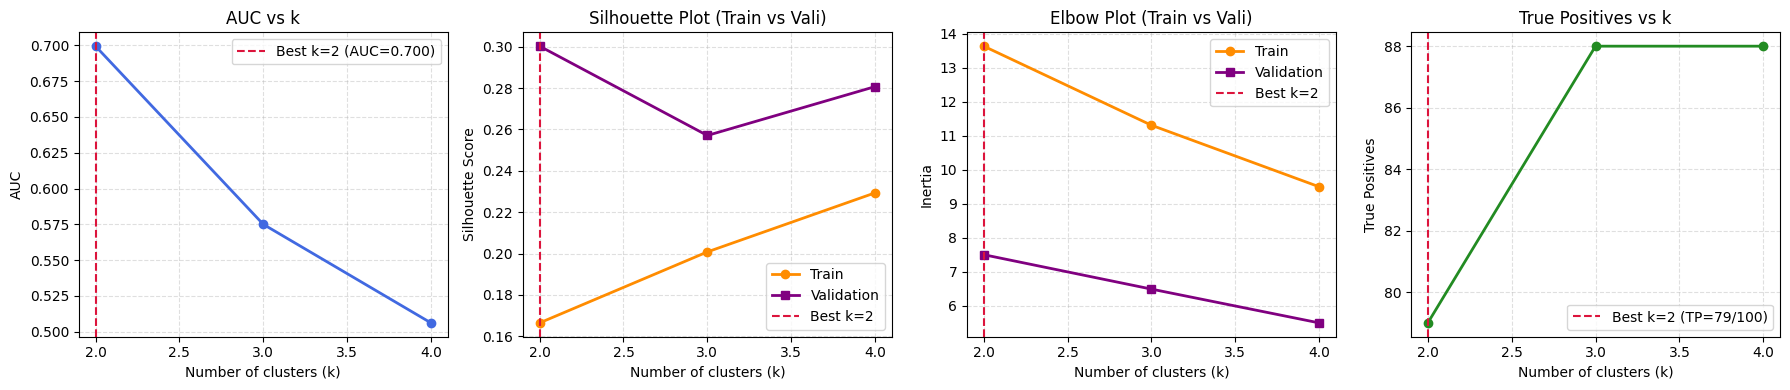

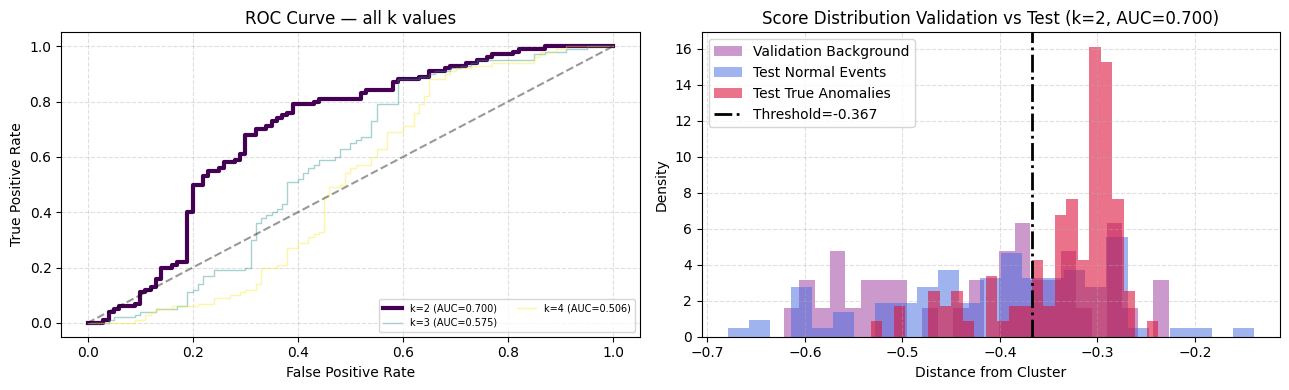

In [ ]:
#@title QUANTUM K-means analysis
import matplotlib.pyplot as plt

ks = [r['k'] for r in results]
aucs = [r['auc'] for r in results]
inertias_tr = [r['inertia_train'] for r in results]
inertias_val = [r['inertia'] for r in results]
sil_tr = [r['sil_train'] for r in results]
sil_val = [r['sil_val'] for r in results]
t_pos = [r['true_positives'] for r in results]

# Plot performance metrics vs k
fig, (ax_auc, ax_sil, ax_in, ax_tpos) = plt.subplots(1, 4, figsize=(18, 4))

ax_auc.plot(ks, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_kmeans_q['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_q['k']} (AUC={best_kmeans_q['auc']:.3f})")
ax_auc.set_xlabel("Number of clusters (k)")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs k")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(ks, t_pos, marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_kmeans_q['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_q['k']} (TP={best_kmeans_q['true_positives']}/{np.sum(true_labels_reduced == 1)})")
ax_tpos.set_xlabel("Number of clusters (k)")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs k")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

ax_sil.plot(ks, sil_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_sil.plot(ks, sil_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_sil.axvline(best_kmeans_q['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_q['k']}")
ax_sil.set_xlabel("Number of clusters (k)")
ax_sil.set_ylabel("Silhouette Score")
ax_sil.set_title("Silhouette Plot (Train vs Vali)")
ax_sil.legend()
ax_sil.grid(True, linestyle='--', alpha=0.4)

ax_in.plot(ks, inertias_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_in.plot(ks, inertias_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_in.axvline(best_kmeans_q['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_q['k']}")
ax_in.set_xlabel("Number of clusters (k)")
ax_in.set_ylabel("Inertia")
ax_in.set_title("Elbow Plot (Train vs Vali)")
ax_in.legend()
ax_in.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Plot ROC and Score Distribution for best k
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))

cmap = plt.cm.viridis(np.linspace(0, 1, len(results)))
for r, color in zip(results, cmap):
    lw = 3 if r['k'] == best_kmeans_q['k'] else 1
    alpha = 1.0 if r['k'] == best_kmeans_q['k'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"k={r['k']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all k values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

ax_hist.hist(best_kmeans_q['scores_val'], bins=25, color='purple',
             alpha=0.4, density=True, label='Validation Background')
ax_hist.hist(best_kmeans_q['scores'][true_labels_reduced == 0], bins=25, color='royalblue',
             alpha=0.5, density=True, label='Test Normal Events')
ax_hist.hist(best_kmeans_q['scores'][true_labels_reduced == 1], bins=25, color='crimson',
             alpha=0.6, density=True, label='Test True Anomalies')
ax_hist.axvline(best_kmeans_q['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_kmeans_q["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Validation vs Test (k={best_kmeans_q['k']}, AUC={best_kmeans_q['auc']:.3f})")
ax_hist.set_xlabel("Distance from Cluster")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#@title Plot of pca space with k-means clusters
import plotly.graph_objects as go
import numpy as np

# Centroidi estratti direttamente dal modello (senza predict)
centers = best_kmeans_q['kmeans'].cluster_centers_

# Maschere per separare i dati di test
test_bg_mask = (true_labels_reduced == 0)
test_anom_mask = (true_labels_reduced == 1)

# Creazione delle tracce
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=latent_quantum_train[:, 0],
    y=latent_quantum_train[:, 1],
    z=latent_quantum_train[:, 2],
    mode='markers',
    name='Train',
    marker=dict(
        size=4,
        color='purple',
        symbol='circle',
        opacity=0.4
    )
))
# 1. Test Background (Blue)
fig.add_trace(go.Scatter3d(
    x=latent_quantum_test[test_bg_mask, 0],
    y=latent_quantum_test[test_bg_mask, 1],
    z=latent_quantum_test[test_bg_mask, 2],
    mode='markers',
    name='Test Background',
    marker=dict(size=4, color='royalblue', symbol='circle', opacity=0.6)
))

# 2. Test Anomaly (Red)
fig.add_trace(go.Scatter3d(
    x=latent_quantum_test[test_anom_mask, 0],
    y=latent_quantum_test[test_anom_mask, 1],
    z=latent_quantum_test[test_anom_mask, 2],
    mode='markers',
    name='Anomaly',
    marker=dict(size=4, color='crimson', symbol='diamond', opacity=0.8)
))

# 3. Validation (Green)
fig.add_trace(go.Scatter3d(
    x=latent_quantum_vali[:, 0],
    y=latent_quantum_vali[:, 1],
    z=latent_quantum_vali[:, 2],
    mode='markers',
    name='Validation',
    marker=dict(size=4, color='green', symbol='circle', opacity=0.5)
))

# 4. Centroids
fig.add_trace(go.Scatter3d(
    x=centers[:, 0],
    y=centers[:, 1],
    z=centers[:, 2],
    mode='markers',
    name='Centroids',
    marker=dict(size=8, color='black', symbol='square', line=dict(color='white', width=1))
))

# Layout
fig.update_layout(
    title=f"Quantum Latent Space: Clusters & Data (k={best_kmeans_q['k']})",
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(x=0.05, y=0.95),
    width=900,
    height=700
)

# Slider fix
if fig.layout.sliders:
    fig.layout.sliders[0].font.color = 'rgba(0,0,0,0)'

fig.show()

### IV. QUANTUM GMM

In this section we compute the same algorithm described in **Section 2.1.III**, based on the space extracted by Kernel-Pca. Therefore the input vectors for train are with dimensions `(TOTAL_EVENTS, n_pca=lat_dim)`



**Note on GMM Component Selection**

To determine the upper search bound for the number of Gaussian components ($n_{max}$) in this regime of low statistics, we employ a heuristic that scales the model complexity relative to the statistical power of the training data and the dimensionality of the latent space. The formula is defined as:

$$n_{max} = \max(1, \text{TOTAL_EVENTS} // (\text{n_pca} + 1)) $$

Logic and Justification:

* **Statistical Stability (Degrees of Freedom):** Each Gaussian component with a ***diagonal covariance matrix*** requires the estimation of approximately $2d + 1$ parameters (where $d$ is the number of PCA dimensions for mean and variance). This heuristic ensures that the number of data points per component is sufficient to obtain stable parameter estimates. Dividing by `n_pca + 1` provides a conservative proxy to prevent the model from becoming unstable or singular.
* **Dimensionality Scaling:** Using `covariance_type='diag'` limits the covariance structure to axis-aligned elipsoids, which scales linearly with dimensionality. This formula reflects the need of low parameters in regimes of low statistics
* **The Role of BIC:** While `n_max` defines the mathematical "ceiling" of our search to prevent over-parametrization, the **Bayesian Information Criterion (BIC)** acts as the selection mechanism. The BIC explicitly penalizes the model for adding extra parameters ($k \ln(N)$). Even if our heuristic allows searching up to $n_{max}$, the BIC curve will naturally balance goodness-of-fit against complexity, identifying the point of diminishing returns before overfitting occurs.

In essence, this formula prevents the model from partitioning the space into an excessive number of components that would result in overfitting or singular covariance matrices. By bounding the search space proportional to the data availability and dimensionality, we ensure that the BIC can reliably identify the most parsimonious model—one complex enough to capture the true density of the background data, but simple enough to generalize in low statistics regime.

In [ ]:
covariance_type='diag'

In [ ]:
#@title QUANTUM - GMM computation
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
import numpy as np

# Cycle on numbers of components
n_min = 1
n_max = max(1, TOTAL_EVENTS // (n_pca + 1))
verbose = True #@param {type:"boolean"}

n_values = list(range(n_min, n_max + 1))
results_gmm = []

print(f"GMM loop for n_components = {n_values[0]} to n = {n_values[-1]}\n")

for n in n_values:
    # Fitting the GMM on quantum latent space
    gmm = GaussianMixture(n_components=n, covariance_type=covariance_type, reg_covar=1e-3, random_state=seed)
    gmm.fit(latent_quantum_train)

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    val_scores = -gmm.score_samples(latent_quantum_vali)
    val_bic = gmm.bic(latent_quantum_vali)

    # Train evaluation BIC extraction
    train_bic = gmm.bic(latent_quantum_train)

    # Scoring samples based on negative log-likelihood
    scores = -gmm.score_samples(latent_quantum_test)

    fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)
    roc_auc = auc(fpr, tpr)

    # Ensure AUC > 0.5
    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        val_scores = -val_scores
        fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)

    # Find optimal threshold using Youden's J statistic
    optimal_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[optimal_idx]
    predicted_labels = (scores >= best_threshold).astype(int)

    # Metrics
    n_predicted = np.sum(predicted_labels == 1)
    true_positives = int(tpr[optimal_idx] * np.sum(true_labels_reduced == 1))

    results_gmm.append({
        'n': n,
        'gmm': gmm,
        'scores': scores,
        'scores_val': val_scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'threshold': best_threshold,
        'n_predicted': n_predicted,
        'true_positives': true_positives,
        'bic': val_bic,
        'bic_train': train_bic
    })
    if verbose:
        train_ll = np.mean(gmm.score_samples(latent_quantum_train))
        val_ll   = np.mean(gmm.score_samples(latent_quantum_vali))
        print(
            f"n={n} | "
            f"Train LL={train_ll:.3f} | "
            f"Val LL={val_ll:.3f} | "
            f"Train BIC={train_bic:.1f} | "
            f"Val BIC={val_bic:.1f}"
        )

# Select the best N by minimizing the BIC on the Validation set (No Leakage)
bic_values_val = [r['bic'] for r in results_gmm]
best_idx = np.argmin(bic_values_val)
best_gmm_q = results_gmm[best_idx]

print(f"---> SELECTED N (via BIC): {best_gmm_q['n']}, AUC={best_gmm_q['auc']:.4f} and Val BIC={best_gmm_q['bic']:.1f}")
print(f"     BIC Values -> Train: {best_gmm_q['bic_train']:.1f} | Vali: {best_gmm_q['bic']:.1f}")

GMM loop for n_components = 1 to n = 4

n=1 | Train LL=0.804 | Val LL=2.597 | Train BIC=-5.3 | Val BIC=-148.8
n=2 | Train LL=1.193 | Val LL=2.931 | Train BIC=26.3 | Val BIC=-112.8
n=3 | Train LL=1.847 | Val LL=3.283 | Train BIC=36.7 | Val BIC=-78.2
n=4 | Train LL=2.085 | Val LL=3.186 | Train BIC=80.4 | Val BIC=-7.7
---> SELECTED N (via BIC): 1, AUC=0.7509 and Val BIC=-148.8
     BIC Values -> Train: -5.3 | Vali: -148.8


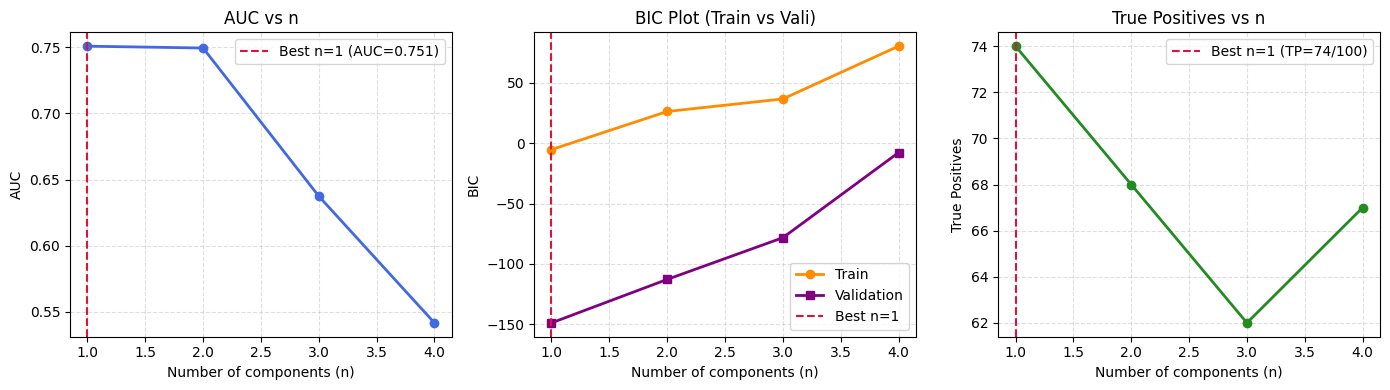

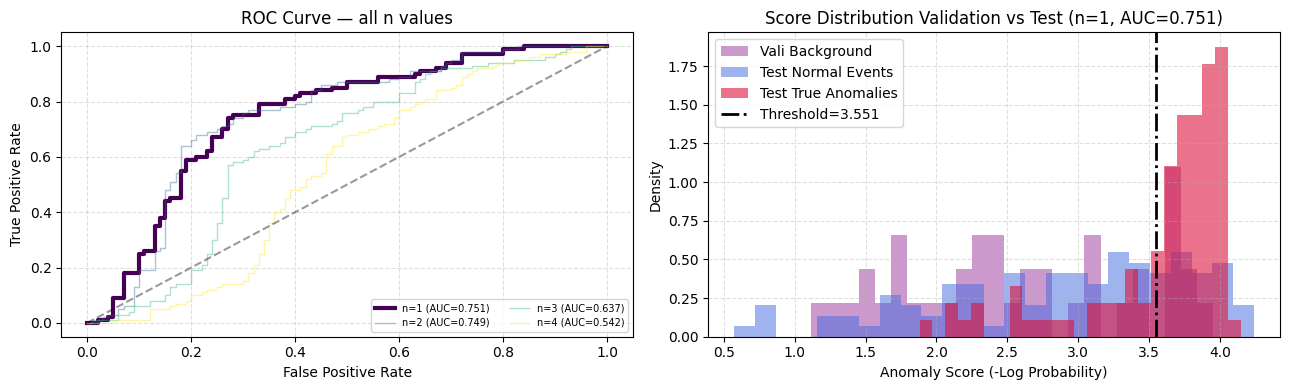

In [ ]:
#@title QUANTUM - GMM analysis
import matplotlib.pyplot as plt
import numpy as np

ns           = [r['n']           for r in results_gmm]
aucs         = [r['auc']         for r in results_gmm]
bics_tr      = [r['bic_train']   for r in results_gmm]
bics_val     = [r['bic']         for r in results_gmm]
t_pos        = [r['true_positives'] for r in results_gmm]

# Plot performance metrics vs n
fig, (ax_auc, ax_bic, ax_tpos) = plt.subplots(1, 3, figsize=(14, 4))

ax_auc.plot(ns, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_gmm_q['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_q['n']} (AUC={best_gmm_q['auc']:.3f})")
ax_auc.set_xlabel("Number of components (n)")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs n")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(ns, t_pos, marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_gmm_q['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_q['n']} (TP={best_gmm_q['true_positives']}/{np.sum(true_labels_reduced == 1)})")
ax_tpos.set_xlabel("Number of components (n)")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs n")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

ax_bic.plot(ns, bics_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_bic.plot(ns, bics_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_bic.axvline(best_gmm_q['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_q['n']}")
ax_bic.set_xlabel("Number of components (n)")
ax_bic.set_ylabel("BIC")
ax_bic.set_title("BIC Plot (Train vs Vali)")
ax_bic.legend()
ax_bic.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Figure below: ROC and Histograms
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))

cmap = plt.cm.viridis(np.linspace(0, 1, len(results_gmm)))

for r, color in zip(results_gmm, cmap):
    lw = 3 if r['n'] == best_gmm_q['n'] else 1
    alpha = 1.0 if r['n'] == best_gmm_q['n'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"n={r['n']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all n values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# Score Distribution for best n
ax_hist.hist(best_gmm_q['scores_val'], bins=25, color='purple',
             alpha=0.4, density=True, label='Vali Background')
ax_hist.hist(best_gmm_q['scores'][true_labels_reduced == 0], bins=25, color='royalblue',
             alpha=0.5, density=True, label='Test Normal Events')
ax_hist.hist(best_gmm_q['scores'][true_labels_reduced == 1], bins=25, color='crimson',
             alpha=0.6, density=True, label='Test True Anomalies')
ax_hist.axvline(best_gmm_q['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_gmm_q["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Validation vs Test (n={best_gmm_q['n']}, AUC={best_gmm_q['auc']:.3f})")
ax_hist.set_xlabel("Anomaly Score (-Log Probability)")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 4.) Comparison against Classical Baselines

In this section we compute again some classical AD algorithms, in order to evaluate a comparison between classical and quantum, using the same size (i.e.  `TOTAL_EVENTS`) of training and test dataset of the latent space.

## I. Classical ONE-CLASS SVM with RBF

In this section we compute a ONE-CLASS SVM with Radial Basis Function kernel.

The Radial Basis Function (RBF) Kernel, also known as the Gaussian kernel, is a non-linear kernel defined as:

$$K(x_i, x_j) = \exp(-\gamma \Vert x_i - x_j \Vert^2)$$

To understand the mechanics of the decision function, we look at the mathematical formulation:


$$f(x) = \sum_{i=1}^{N} \alpha_i K(x_i, x) - \rho$$

By substituting the RBF kernel equation, the function becomes:


$$f(x) = \sum_{i=1}^{N} \alpha_i \exp(-\gamma \Vert x_i - x \Vert^2) - \rho$$

**1. Influence of Each Training Point ($x_i$)**
The summation technically iterates through every training point ($x_i$), but the Lagrangian multipliers ($\alpha_i$) determine the functional impact of each:

* **Support Vectors ($\alpha_i > 0$):** These specific pointsv $x_i$ are the only ones that define the decision boundary. Each Support Vector acts as the center of its own localized Gaussian bell curve. If a new test point $x$ is close to a Support Vector, the function outputs a value closer to 1; as it moves away, the contribution decays exponentially toward 0.
* **Non-Support Vectors ($\alpha_i = 0$):** Although these points exist within the training dataset, they do not contribute to the final summation. Because their weight ($\alpha_i$) is zero, they are effectively ignored by the model and do not shape the decision boundary.

**2. Taking a Linear Combination**
The algorithm constructs the global model by summing the weighted Gaussian influences of all Support Vectors. The $\alpha_i$ coefficients act as "weights" that scale the intensity of each Gaussian kernel. The model does not treat all points equally; it prioritizes those that are critical to the boundary definition (the Support Vectors) while discarding the rest.

**3. The Final Boundary Geometry**
The parameter $\rho$ functions as a global threshold. The non-linear boundary is the specific isosurface where the sum of these weighted Gaussian bells exactly equals $\rho$ ($f(x) = 0$):

* **Normal Inliers ($f(x) \geq 0$):** Regions where the overlapping Gaussian values are sufficiently high, exceeding the threshold.
* **Anomalies ($f(x) < 0$):** Regions where the Gaussian curves have decayed, causing the score to drop below the threshold.


In [ ]:
#@title CLASSICAL SVM computation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_curve, auc
from sklearn.metrics.pairwise import rbf_kernel

# Precompute classical RBF kernels
kernel_rbf_train = rbf_kernel(latent_train_reduced)
kernel_rbf_vali  = rbf_kernel(latent_vali_reduced, latent_train_reduced)
kernel_rbf_test  = rbf_kernel(latent_test_reduced, latent_train_reduced)

# Define the range of nu hyperparameters to test
nus_c = nus # same of Q. SVM
results_c = []

print(f"Classical One-Class SVM loop for nu values...")

# Loop over different nu values
for nu in nus_c:
    # --- Original logic (modified only to loop over nu) ---
    svm_c = OneClassSVM(kernel='precomputed', nu=nu)
    svm_c.fit(kernel_rbf_train)

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    score_val = -svm_c.decision_function(kernel_rbf_vali)
    val_inertia = np.sum(np.square(score_val)) # Total squared distance on validation set

    # Train evaluation inertia extraction
    score_train = -svm_c.decision_function(kernel_rbf_train)
    train_inertia = np.sum(np.square(score_train))

    score_svm_c = -svm_c.decision_function(kernel_rbf_test)

    fpr_c, tpr_c, thresholds_c = roc_curve(true_labels_reduced, score_svm_c)
    auc_svm_c = auc(fpr_c, tpr_c)

    if auc_svm_c < 0.5:
        auc_svm_c = 1 - auc_svm_c
        score_svm_c = -score_svm_c
        score_val = -score_val
        fpr_c, tpr_c, thresholds_c = roc_curve(true_labels_reduced, score_svm_c)
    # ------------------------------------------------------

    # Calculate optimal threshold using Youden's J statistic (max TPR - FPR)
    idx_optimal = np.argmax(tpr_c - fpr_c)
    optimal_threshold = thresholds_c[idx_optimal]

    # Calculate True Positives at this specific threshold
    predicted_anomalies = score_svm_c >= optimal_threshold
    true_positives = np.sum((predicted_anomalies == 1) & (true_labels_reduced == 1))

    # Store results for plotting
    res = {
        'nu': nu,
        'auc': auc_svm_c,
        'fpr': fpr_c,
        'tpr': tpr_c,
        'scores': score_svm_c,
        'scores_val': score_val,
        'threshold': optimal_threshold,
        'true_positives': true_positives,
        'inertia': val_inertia,
        'inertia_train': train_inertia
    }
    results_c.append(res)

    print(f"  nu={nu:.2f} | Train Inertia={train_inertia:.1f} | Val Inertia={val_inertia:.1f} | Test AUC={auc_svm_c:.4f}")

# Unsupervised selection via Validation Inertia Elbow using np.diff()
inertia_values_val_c = [r['inertia'] for r in results_c]
second_derivative_c = np.diff(inertia_values_val_c, n=2)

# The peak of the second derivative corresponds to the sharpest turn (the elbow).
best_idx_c = np.argmax(second_derivative_c) + 1
best_svm_c = results_c[best_idx_c]

# Assign final global variables for the summary plots and table compatibility
auc_svm_c = best_svm_c['auc']
fpr_c = best_svm_c['fpr']
tpr_c = best_svm_c['tpr']

print(f"\n---> SELECTED CLASSSICAL NU (via Unsupervised Validation Elbow): {best_svm_c['nu']}, AUC={best_svm_c['auc']:.4f} and Val Inertia={best_svm_c['inertia']:.4f}")

Classical One-Class SVM loop for nu values...
  nu=0.01 | Train Inertia=0.0 | Val Inertia=0.0 | Test AUC=0.6896
  nu=0.05 | Train Inertia=0.1 | Val Inertia=0.1 | Test AUC=0.6944
  nu=0.10 | Train Inertia=0.3 | Val Inertia=0.3 | Test AUC=0.7559
  nu=0.15 | Train Inertia=0.6 | Val Inertia=0.6 | Test AUC=0.7655
  nu=0.20 | Train Inertia=1.0 | Val Inertia=1.0 | Test AUC=0.7680
  nu=0.30 | Train Inertia=2.2 | Val Inertia=2.2 | Test AUC=0.7727
  nu=0.40 | Train Inertia=4.0 | Val Inertia=4.5 | Test AUC=0.7728
  nu=0.50 | Train Inertia=6.9 | Val Inertia=7.4 | Test AUC=0.7702

---> SELECTED CLASSSICAL NU (via Unsupervised Validation Elbow): 0.3, AUC=0.7727 and Val Inertia=2.2324


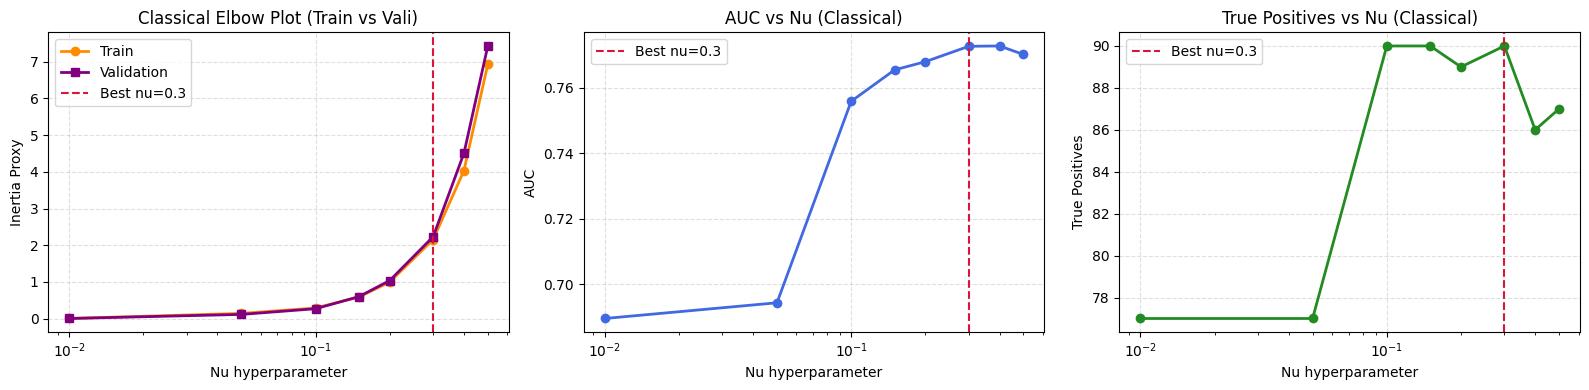

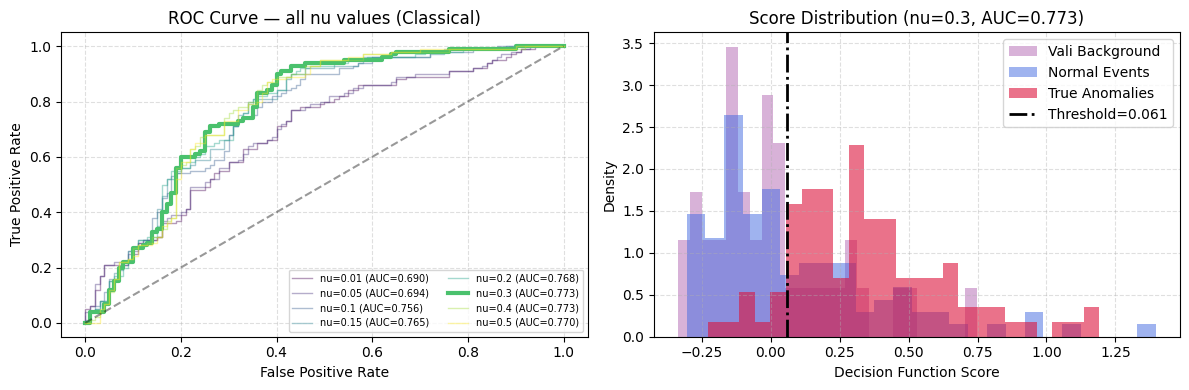

In [ ]:
#@title CLASSICAL ONE-CLASS SVM analysis

# Plot performance metrics including Elbow Plot
fig, (ax_in, ax_auc, ax_tpos) = plt.subplots(1, 3, figsize=(16, 4))

# New: Elbow Plot for Classical Inertia
ax_in.plot(nus_c, [r['inertia_train'] for r in results_c], marker='o', linewidth=2, color='darkorange', label='Train')
ax_in.plot(nus_c, [r['inertia'] for r in results_c], marker='s', linewidth=2, color='purple', label='Validation')
ax_in.axvline(best_svm_c['nu'], color='crimson', linestyle='--', label=f"Best nu={best_svm_c['nu']}")
ax_in.set_xscale('log')
ax_in.set_xlabel("Nu hyperparameter")
ax_in.set_ylabel("Inertia Proxy")
ax_in.set_title("Classical Elbow Plot (Train vs Vali)")
ax_in.legend()
ax_in.grid(True, linestyle='--', alpha=0.4)

ax_auc.plot(nus_c, [r['auc'] for r in results_c], marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_svm_c['nu'], color='crimson', linestyle='--', label=f"Best nu={best_svm_c['nu']}")
ax_auc.set_xscale('log')
ax_auc.set_xlabel("Nu hyperparameter")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs Nu (Classical)")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(nus_c, [r['true_positives'] for r in results_c], marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_svm_c['nu'], color='crimson', linestyle='--', label=f"Best nu={best_svm_c['nu']}")
ax_tpos.set_xscale('log')
ax_tpos.set_xlabel("Nu hyperparameter")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs Nu (Classical)")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Plot ROC and Score Distribution for best nu
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(12, 4))

cmap = plt.cm.viridis(np.linspace(0, 1, len(results_c)))
for r, color in zip(results_c, cmap):
    lw = 3 if r['nu'] == best_svm_c['nu'] else 1
    alpha = 1.0 if r['nu'] == best_svm_c['nu'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"nu={r['nu']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all nu values (Classical)")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

ax_hist.hist(best_svm_c['scores_val'], bins=25, color='purple', alpha=0.3, density=True, label='Vali Background')
ax_hist.hist(best_svm_c['scores'][true_labels_reduced == 0], bins=25, color='royalblue',
             alpha=0.5, density=True, label='Normal Events')
ax_hist.hist(best_svm_c['scores'][true_labels_reduced == 1], bins=25, color='crimson',
             alpha=0.6, density=True, label='True Anomalies')
ax_hist.axvline(best_svm_c['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_svm_c["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution (nu={best_svm_c['nu']}, AUC={best_svm_c['auc']:.3f})")
ax_hist.set_xlabel("Decision Function Score")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## II. K MEANS CLASSIC, WITH REDUCED LATENT SPACE

In [ ]:
#@title K-means computation, with reduced latent space
from sklearn.metrics import roc_curve, auc, silhouette_score
from sklearn.cluster import KMeans
import numpy as np

# K-MEANS LOOP
verbose = True #@param {type:"boolean"}
results = []

print(f"K-Means loop from k={k_values[0]} to k={k_values[-1]}")

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=seed, n_init=100)
    kmeans.fit(latent_train_reduced)

    # Calculate Silhouette Scores for train and validation datasets
    sil_train = silhouette_score(latent_train_reduced, kmeans.labels_, random_state=42)

    # Safely handle cases where validation points end up in a single cluster
    try:
        sil_val = silhouette_score(latent_vali_reduced, kmeans.predict(latent_vali_reduced), random_state=seed)
    except ValueError:
        sil_val = -1.0 # Minimum possible silhouette score if only 1 cluster is populated

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    val_distances = kmeans.transform(latent_vali_reduced)
    val_scores = np.min(val_distances, axis=1)
    val_inertia = np.sum(np.square(val_scores)) # Total squared distance on validation set

    # Train evaluation inertia extraction
    train_inertia = kmeans.inertia_

    distances = kmeans.transform(latent_test_reduced)
    scores = np.min(distances, axis=1)

    fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)
    roc_auc = auc(fpr, tpr)

    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)

    # Find optimal threshold to classify anomalies
    optimal_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[optimal_idx]
    predicted_labels = (scores >= best_threshold).astype(int)

    # Counting Anomolies to evaluate RECALL
    n_predicted = np.sum(predicted_labels == 1)
    true_positives = int(tpr[optimal_idx] * np.sum(true_labels_reduced == 1))

    results.append({
        'k': k,
        'kmeans': kmeans,
        'scores': scores,
        'scores_val': val_scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'threshold': best_threshold,
        'n_predicted': n_predicted,
        'true_positives': true_positives,
        'inertia': val_inertia,
        'inertia_train': train_inertia,
        'sil_train': sil_train,
        'sil_val': sil_val
    })
    if verbose:
        print(f"  k={k:2d} | Train Inertia={train_inertia:.1f} | Val Inertia={val_inertia:.1f} | Sil Train={sil_train:.3f} | Sil Val={sil_val:.3f} | Test AUC={roc_auc:.4f}")

# Select the best K by maximizing the Silhouette Score on the Validation set (No Leakage)
sil_values_val = [r['sil_val'] for r in results]
best_idx = np.argmax(sil_values_val)
best_kmeans_c = results[best_idx]

print(f"---> SELECTED K (via Silhouette): {best_kmeans_c['k']}, AUC={best_kmeans_c['auc']:.4f} and Val Inertia={best_kmeans_c['inertia']:.1f}, found {best_kmeans_c['true_positives']}/{np.sum(true_labels_reduced == 1)} anomalies")
print(f"     Silhouette Scores -> Train: {best_kmeans_c['sil_train']:.4f} | Vali: {best_kmeans_c['sil_val']:.4f}")

K-Means loop from k=2 to k=4
  k= 2 | Train Inertia=6.6 | Val Inertia=8.9 | Sil Train=0.330 | Sil Val=0.289 | Test AUC=0.7857
  k= 3 | Train Inertia=5.2 | Val Inertia=7.2 | Sil Train=0.222 | Sil Val=0.217 | Test AUC=0.7849
  k= 4 | Train Inertia=4.5 | Val Inertia=6.5 | Sil Train=0.205 | Sil Val=0.143 | Test AUC=0.7889
---> SELECTED K (via Silhouette): 2, AUC=0.7857 and Val Inertia=8.9, found 97/100 anomalies
     Silhouette Scores -> Train: 0.3305 | Vali: 0.2895


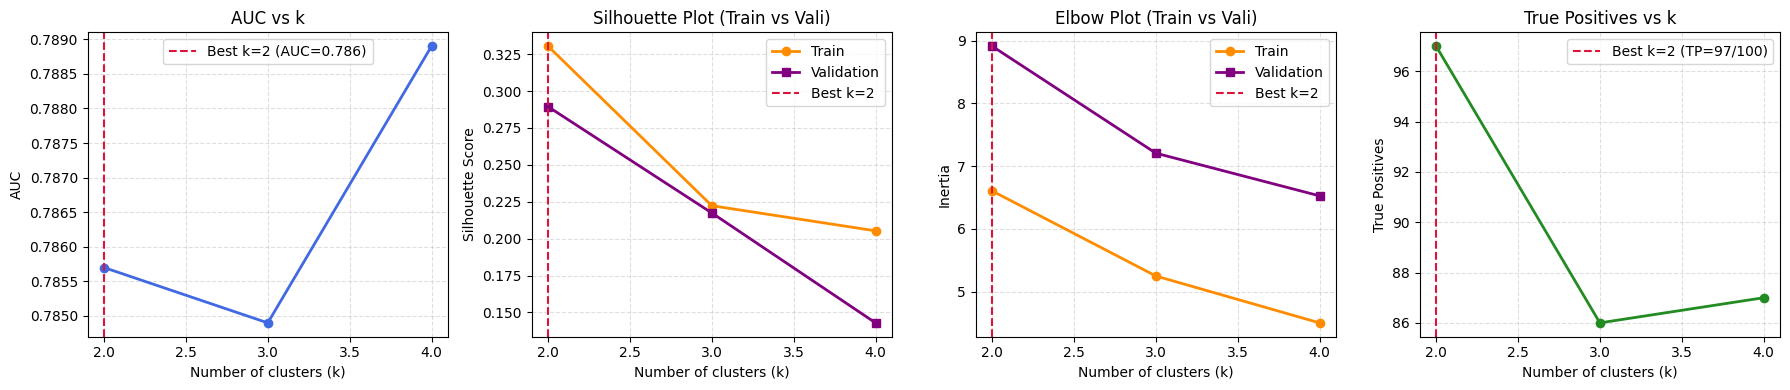

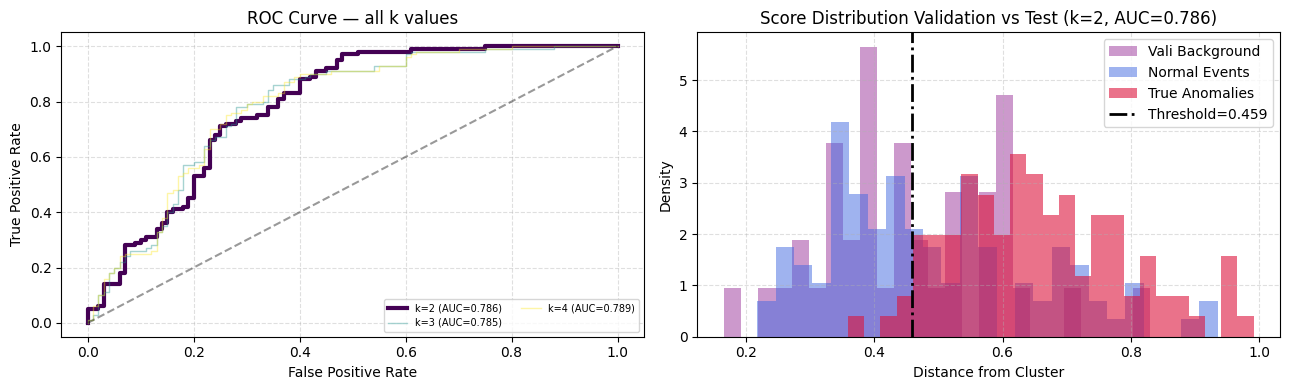

In [ ]:
#@title K-means analysis, with reduced latent space
import matplotlib.pyplot as plt
import numpy as np

ks           = [r['k']           for r in results]
aucs         = [r['auc']         for r in results]
inertias_tr  = [r['inertia_train'] for r in results]
inertias_val = [r['inertia']     for r in results]
sil_tr       = [r['sil_train']   for r in results]
sil_val      = [r['sil_val']     for r in results]
t_pos        = [r['true_positives'] for r in results]

# Plot performance metrics vs k
fig, (ax_auc, ax_sil, ax_in, ax_tpos) = plt.subplots(1, 4, figsize=(18, 4))

ax_auc.plot(ks, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']} (AUC={best_kmeans_c['auc']:.3f})")
ax_auc.set_xlabel("Number of clusters (k)")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs k")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(ks, t_pos, marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']} (TP={best_kmeans_c['true_positives']}/{np.sum(true_labels_reduced == 1)})")
ax_tpos.set_xlabel("Number of clusters (k)")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs k")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

ax_sil.plot(ks, sil_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_sil.plot(ks, sil_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_sil.axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']}")
ax_sil.set_xlabel("Number of clusters (k)")
ax_sil.set_ylabel("Silhouette Score")
ax_sil.set_title("Silhouette Plot (Train vs Vali)")
ax_sil.legend()
ax_sil.grid(True, linestyle='--', alpha=0.4)

ax_in.plot(ks, inertias_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_in.plot(ks, inertias_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_in.axvline(best_kmeans_c['k'], color='crimson', linestyle='--', label=f"Best k={best_kmeans_c['k']}")
ax_in.set_xlabel("Number of clusters (k)")
ax_in.set_ylabel("Inertia")
ax_in.set_title("Elbow Plot (Train vs Vali)")
ax_in.legend()
ax_in.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##Figure below
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))

# --- PLOT 1: ROC Curves for all k ---
cmap = plt.cm.viridis(np.linspace(0, 1, len(results)))

for r, color in zip(results, cmap):
    lw = 3 if r['k'] == best_kmeans_c['k'] else 1
    alpha = 1.0 if r['k'] == best_kmeans_c['k'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"k={r['k']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all k values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# --- PLOT 2: Anomaly Score Distribution for best_kmeans_c k ---
ax_hist.hist(best_kmeans_c['scores_val'], bins=25, color='purple',
             alpha=0.4, density=True, label='Vali Background')
ax_hist.hist(best_kmeans_c['scores'][true_labels_reduced == 0], bins=25, color='royalblue',
             alpha=0.5, density=True, label='Normal Events')
ax_hist.hist(best_kmeans_c['scores'][true_labels_reduced == 1], bins=25, color='crimson',
             alpha=0.6, density=True, label='True Anomalies')
ax_hist.axvline(best_kmeans_c['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_kmeans_c["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Validation vs Test (k={best_kmeans_c['k']}, AUC={best_kmeans_c['auc']:.3f})")
ax_hist.set_xlabel("Distance from Cluster")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## III. Gaussian Mixture Model, with reduced latent space

In [ ]:
#@title GMM computation with reduced latent space
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc
import numpy as np

#Cycle on numbers of components
verbose = True #@param {type:"boolean"}
results_gmm = []

print(f"GMM loop for n_components = {n_values[0]} to n = {n_values[-1]}\n")

for n in n_values:
    gmm = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=42)
    gmm.fit(latent_train_reduced)

    # Validation evaluation (Unsupervised, no labels used, So no leakage)
    val_scores = -gmm.score_samples(latent_vali_reduced)
    val_bic = gmm.bic(latent_vali_reduced)

    # Train evaluation BIC extraction
    train_bic = gmm.bic(latent_train_reduced)

    # Scoring samples based on negative log-likelihood
    scores = -gmm.score_samples(latent_test_reduced)

    fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)
    roc_auc = auc(fpr, tpr)

    if roc_auc < 0.5:
        roc_auc = 1 - roc_auc
        scores = -scores
        fpr, tpr, thresholds = roc_curve(true_labels_reduced, scores)

    optimal_idx = np.argmax(tpr - fpr)
    best_threshold = thresholds[optimal_idx]
    predicted_labels = (scores >= best_threshold).astype(int)

    n_predicted = np.sum(predicted_labels == 1)
    true_positives = int(tpr[optimal_idx] * np.sum(true_labels_reduced == 1))

    results_gmm.append({
        'n': n,
        'gmm': gmm,
        'scores': scores,
        'scores_val': val_scores,
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc,
        'threshold': best_threshold,
        'n_predicted': n_predicted,
        'true_positives': true_positives,
        'bic': val_bic,
        'bic_train': train_bic
    })
    if verbose:
        print(f"  n={n:2d} | Train BIC={train_bic:.1f} | Val BIC={val_bic:.1f} | Test AUC={roc_auc:.4f} | Predicted Anomalies={n_predicted} | True Positives={true_positives}/{np.sum(true_labels_reduced == 1)}")

# Select the best N by minimizing the BIC on the Validation set (No Leakage)
bic_values_val = [r['bic'] for r in results_gmm]
best_idx = np.argmin(bic_values_val)
best_gmm_c = results_gmm[best_idx]

print(f"-----> SELECTED N (via BIC): {best_gmm_c['n']}, AUC={best_gmm_c['auc']:.4f} and Val BIC={best_gmm_c['bic']:.1f}, found {best_gmm_c['true_positives']}/{np.sum(true_labels_reduced==1)} true anomalies")
print(f"     BIC Values -> Train: {best_gmm_c['bic_train']:.1f} | Vali: {best_gmm_c['bic']:.1f}")

# Updated variables for the best n (compatible with the rest of the notebook)
roc_auc_gmm_c = best_gmm_c['auc']

GMM loop for n_components = 1 to n = 4

  n= 1 | Train BIC=-192.1 | Val BIC=-142.0 | Test AUC=0.7469 | Predicted Anomalies=142 | True Positives=93/100
  n= 2 | Train BIC=-191.0 | Val BIC=-76.4 | Test AUC=0.7854 | Predicted Anomalies=92 | True Positives=70/100
  n= 3 | Train BIC=-177.9 | Val BIC=9.3 | Test AUC=0.7769 | Predicted Anomalies=95 | True Positives=70/100
  n= 4 | Train BIC=-150.4 | Val BIC=115.1 | Test AUC=0.8036 | Predicted Anomalies=107 | True Positives=82/100
-----> SELECTED N (via BIC): 1, AUC=0.7469 and Val BIC=-142.0, found 93/100 true anomalies
     BIC Values -> Train: -192.1 | Vali: -142.0


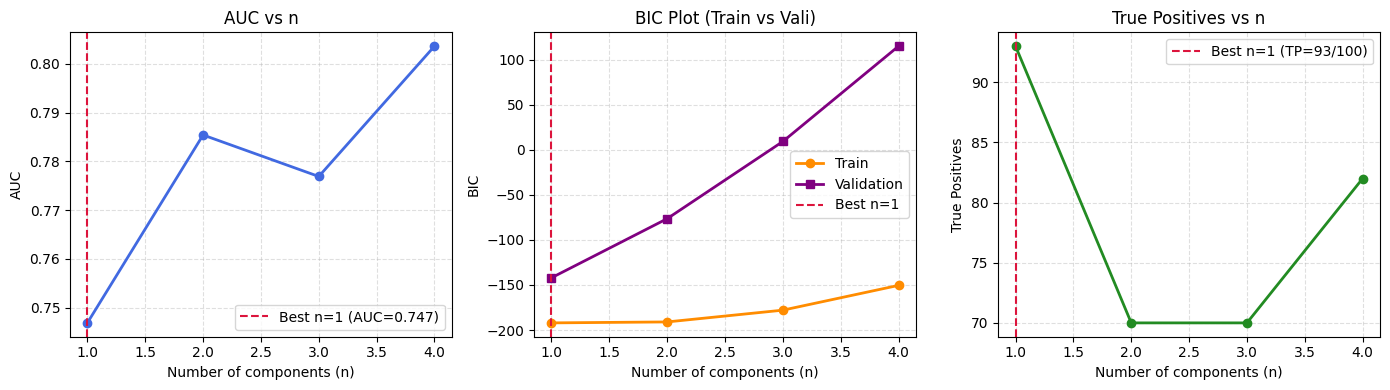

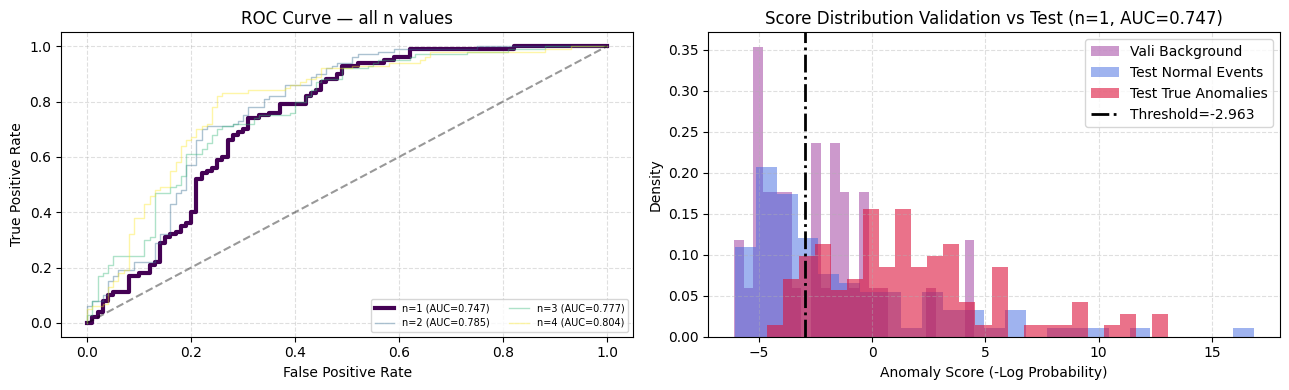

In [ ]:
#@title GMM analysis with reduced latent space
import matplotlib.pyplot as plt
import numpy as np

ns           = [r['n']           for r in results_gmm]
aucs         = [r['auc']         for r in results_gmm]
bics_tr      = [r['bic_train']   for r in results_gmm]
bics_val     = [r['bic']         for r in results_gmm]
t_pos        = [r['true_positives'] for r in results_gmm]

fig, (ax_auc, ax_bic, ax_tpos) = plt.subplots(1, 3, figsize=(14, 4))

ax_auc.plot(ns, aucs, marker='o', linewidth=2, color='royalblue')
ax_auc.axvline(best_gmm_c['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_c['n']} (AUC={best_gmm_c['auc']:.3f})")
ax_auc.set_xlabel("Number of components (n)")
ax_auc.set_ylabel("AUC")
ax_auc.set_title("AUC vs n")
ax_auc.legend()
ax_auc.grid(True, linestyle='--', alpha=0.4)

ax_tpos.plot(ns, t_pos, marker='o', linewidth=2, color='forestgreen')
ax_tpos.axvline(best_gmm_c['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_c['n']} (TP={best_gmm_c['true_positives']}/{np.sum(true_labels_reduced == 1)})")
ax_tpos.set_xlabel("Number of components (n)")
ax_tpos.set_ylabel("True Positives")
ax_tpos.set_title("True Positives vs n")
ax_tpos.legend()
ax_tpos.grid(True, linestyle='--', alpha=0.4)

ax_bic.plot(ns, bics_tr, marker='o', linewidth=2, color='darkorange', label='Train')
ax_bic.plot(ns, bics_val, marker='s', linewidth=2, color='purple', label='Validation')
ax_bic.axvline(best_gmm_c['n'], color='crimson', linestyle='--', label=f"Best n={best_gmm_c['n']}")
ax_bic.set_xlabel("Number of components (n)")
ax_bic.set_ylabel("BIC")
ax_bic.set_title("BIC Plot (Train vs Vali)")
ax_bic.legend()
ax_bic.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

##Figure below
fig, (ax_roc, ax_hist) = plt.subplots(1, 2, figsize=(13, 4))

# --- PLOT 1: ROC Curves for all n ---
cmap = plt.cm.viridis(np.linspace(0, 1, len(results_gmm)))

for r, color in zip(results_gmm, cmap):
    lw = 3 if r['n'] == best_gmm_c['n'] else 1
    alpha = 1.0 if r['n'] == best_gmm_c['n'] else 0.4
    ax_roc.plot(r['fpr'], r['tpr'], color=color, linewidth=lw, alpha=alpha,
                label=f"n={r['n']} (AUC={r['auc']:.3f})")

ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.set_title("ROC Curve — all n values")
ax_roc.legend(fontsize=7, loc='lower right', ncol=2)
ax_roc.grid(True, linestyle='--', alpha=0.4)

# --- PLOT 2: Anomaly Score Distribution for best n ---
ax_hist.hist(best_gmm_c['scores_val'], bins=25, color='purple',
             alpha=0.4, density=True, label='Vali Background')
ax_hist.hist(best_gmm_c['scores'][true_labels_reduced == 0], bins=25, color='royalblue',
             alpha=0.5, density=True, label='Test Normal Events')
ax_hist.hist(best_gmm_c['scores'][true_labels_reduced == 1], bins=25, color='crimson',
             alpha=0.6, density=True, label='Test True Anomalies')
ax_hist.axvline(best_gmm_c['threshold'], color='black', linestyle='-.', linewidth=2,
                label=f'Threshold={best_gmm_c["threshold"]:.3f}')
ax_hist.set_title(f"Score Distribution Validation vs Test (n={best_gmm_c['n']}, AUC={best_gmm_c['auc']:.3f})")
ax_hist.set_xlabel("Anomaly Score (-Log Probability)")
ax_hist.set_ylabel("Density")
ax_hist.legend()
ax_hist.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## Comparison


METHOD                         KERNEL            AUC
One-Class SVM                  Classical RBF   0.7727
One-Class SVM                  Quantum        0.8003
K-Means                        Classical      0.7857
K-Means                        Quantum        0.6995
GMM                            Classical      0.7469
GMM                            Quantum        0.7509


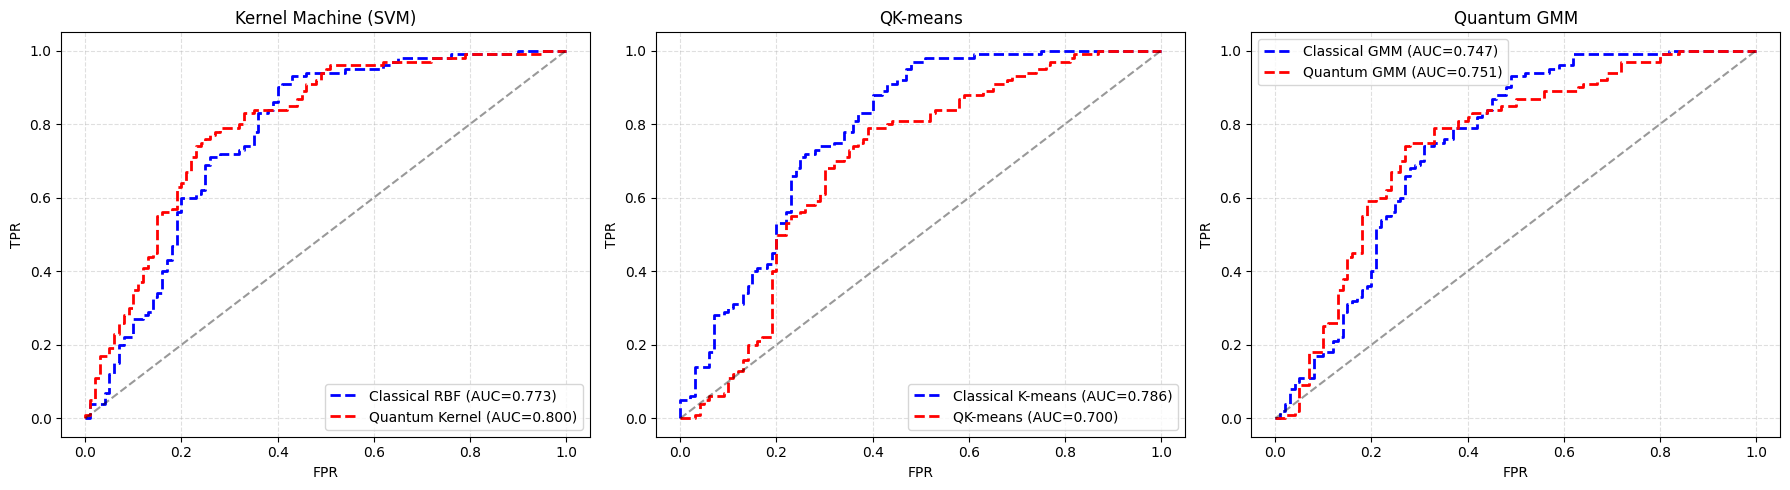

In [ ]:
#@title Summary table
print("\n" + "="*55)
print(f"{'METHOD':<30} {'KERNEL':<12} {'AUC':>8}")
print("="*55)
print(f"{'One-Class SVM':<30} {'Classical RBF':<12} {best_svm_c['auc']:>8.4f}")
print(f"{'One-Class SVM':<30} {'Quantum':<12} {best_svm_q['auc']:>8.4f}")

print(f"{'K-Means':<30} {'Classical':<12} {best_kmeans_c['auc']:>8.4f}")
print(f"{'K-Means':<30} {'Quantum':<12} {best_kmeans_q['auc']:>8.4f}")

print(f"{'GMM':<30} {'Classical':<12} {best_gmm_c['auc']:>8.4f}")
print(f"{'GMM':<30} {'Quantum':<12} {best_gmm_q['auc']:>8.4f}")

print("="*55)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Kernel Machine (SVM)
ax1.plot(best_svm_c['fpr'], best_svm_c['tpr'], lw=2, color='blue', linestyle='--', label=f"Classical RBF (AUC={best_svm_c['auc']:.3f})")
ax1.plot(best_svm_q['fpr'], best_svm_q['tpr'], lw=2, color='red', linestyle='--',label=f"Quantum Kernel (AUC={best_svm_q['auc']:.3f})")
ax1.plot([0,1], [0,1], 'k--', alpha=0.4)
ax1.set_xlabel("FPR")
ax1.set_ylabel("TPR")
ax1.set_title("Kernel Machine (SVM)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.4)

# Plot 2: K-means
ax2.plot(best_kmeans_c['fpr'], best_kmeans_c['tpr'], lw=2, color='blue', linestyle='--', label=f"Classical K-means (AUC={best_kmeans_c['auc']:.3f})")
ax2.plot(best_kmeans_q['fpr'], best_kmeans_q['tpr'], lw=2, color='red',linestyle='--', label=f"QK-means (AUC={best_kmeans_q['auc']:.3f})")
ax2.plot([0,1], [0,1], 'k--', alpha=0.4)
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.set_title("QK-means")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.4)

# Plot 3: GMM
ax3.plot(best_gmm_c['fpr'], best_gmm_c['tpr'], lw=2, color='blue', linestyle='--', label=f"Classical GMM (AUC={best_gmm_c['auc']:.3f})")
ax3.plot(best_gmm_q['fpr'], best_gmm_q['tpr'], lw=2, color='red', linestyle='--', label=f"Quantum GMM (AUC={best_gmm_q['auc']:.3f})")
ax3.plot([0,1], [0,1], 'k--', alpha=0.4)
ax3.set_xlabel("FPR")
ax3.set_ylabel("TPR")
ax3.set_title("Quantum GMM")
ax3.legend()
ax3.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## BACKGROUND REJECTION

This cell evaluates the performance of different anomaly detection algorithms by fixing the **Signal Efficiency ($\epsilon_s$)** using the interactive slider and observing how well each model rejects the background processes.

This script computes and compares the background rejection capabilities of both **Classical (C)** and **Quantum (Q)** implementations of the algorithms.

---

**The 3 Output Parameters Explained**

The code prints a table with 3 primary metrics evaluated at  chosen target signal efficiency ($\epsilon_s$):

**1. Classical Background Rejection ($R_b$ or $\epsilon_b^{-1}$)**

* **Formula:**
$$R_b(\text{Classical}) = \epsilon_b^{-1}(\epsilon_s; C) = \frac{1}{\text{FPR}_{\text{classical}}}=1+ \frac{TN}{FP}$$


* **Meaning:** In HEP nomenclature, the False Positive Rate (FPR) is known as **background efficiency ($\epsilon_b$)**. The inverse of this rate ($\epsilon_b^{-1}$) is the **Background Rejection**. It represents the factor by which the model suppresses the background. For example, an $R_b$ of $100$ means that for every 1000 background events passing into the system, the classical model successfully rejects $TN=990$ of them and is wrong in $FP=10$, while keeping the target fraction ($\epsilon_s$) of signal events.

**2. Quantum Background Rejection ($R_b$ or $\epsilon_b^{-1}$)**

* **Formula:**
$$R_b(\text{Quantum}) = \epsilon_b^{-1}(\epsilon_s; Q) = \frac{1}{\text{FPR}_{\text{quantum}}}$$


* **Meaning:** Exactly the same concept as the classical background rejection, but computed using the ROC curve of the **Quantum** machine learning model.

**3. $\Delta$ QC (Quantum-vs-Classical Ratio)**

* **Formula (Equation 1 from the paper):**
$$\Delta_{QC}(\epsilon_s) = \frac{\epsilon_b^{-1}(\epsilon_s; Q)}{\epsilon_b^{-1}(\epsilon_s; C)} = \frac{R_b(C)}{R_b(Q)}$$


* **Meaning:** This is a relative metric to explicitly quantify the performance gain (or loss) of moving from a classical model to a quantum model at a specific working point ($\epsilon_s$). It shows how many times better the quantum model rejects background compared to its classical counterpart.

---

**Interpretation of results**
* **$\Delta$ QC $> 1$ (Quantum Advantage):** The quantum model achieves better background suppression than the classical model at this specific signal efficiency. A value of $\Delta_{QC} = 5.0$, for instance, means the quantum model is **5 times more effective** at rejecting background noise than the classical benchmark.
* **$\Delta$ QC $= 1$ (Parity):** Both the classical and quantum models perform identically.
* **$\Delta$ QC $< 1$ (Classical Superiority):** The classical model is outperforming the quantum model. This typically happens in regimes with low quantum resources (e.g., low qubit counts $n_q$ or lack of circuit entanglement).



In [ ]:
#@title analysis of background rejection at fixed efficiency (epsilon_s)
epsilon_s = 0.75 #@param {type:"slider", min:0.1, max:0.95, step:0.05}



def compute_bg_rejection(fpr, tpr, target_eps):
    """
    Finds the FPR corresponding to the desired signal efficiency (target_eps)
    via linear interpolation and returns the Background Rejection (1 / FPR).
    """
    # np.interp requires the x-axis (tpr) to be monotonically increasing.
    # Since roc_curve returns increasing tpr, the interpolation is straightforward.
    fpr_at_eps = np.interp(target_eps, tpr, fpr)

    if fpr_at_eps > 0:
        return 1.0 / fpr_at_eps
    else:
        return float('inf') # If FPR is zero, rejection is ideally infinite

# --- Model Mapping Dictionary ---
models_data = {
    'SVM': {
        'Classical': (best_svm_c['fpr'], best_svm_c['tpr']) ,
        'Quantum': (best_svm_q['fpr'], best_svm_q['tpr']) },
    'K-Means': {
        'Classical': (best_kmeans_c['fpr'], best_kmeans_c['tpr']),
        'Quantum': (best_kmeans_q['fpr'], best_kmeans_q['tpr']) },
    'GMM': {
        'Classical': (best_gmm_c['fpr'], best_gmm_c['tpr']),
        'Quantum': (best_gmm_q['fpr'], best_gmm_q['tpr'])
    }
}

print(f"{'Algorithm':<15} | {'Classical $R_b$':<18} | {'Quantum $R_b$':<18} | {'$\\Delta$ QC':<10}")
print("-" * 65)

for method, kernels in models_data.items():
    fpr_c, tpr_c = kernels['Classical']
    fpr_q, tpr_q = kernels['Quantum']

    rej_c = compute_bg_rejection(fpr_c, tpr_c, epsilon_s)
    rej_q = compute_bg_rejection(fpr_q, tpr_q, epsilon_s)
    delta = rej_q / rej_c

    # Stampa formattata senza LaTeX (più leggibile in console)
    print(f"{method:<15} | {rej_c:<15.2f} | {rej_q:<15.2f} | {delta:<10.3f}")

Algorithm       | Classical $R_b$    | Quantum $R_b$      | $\Delta$ QC
-----------------------------------------------------------------
SVM             | 2.86            | 4.00            | 1.400     
K-Means         | 2.94            | 2.63            | 0.895     
GMM             | 2.86            | 3.03            | 1.061     


# 5.) Extension B: Dependence on quantum resources


In this section, we conduct a systematic investigation into the scalability and impact of quantum resources on anomaly detection performance within the latent space.

In order to evaluate performance in a small-scale hardware implementation but with a robust proof of concept, we use a reduced train size  `TOTAL_EVENTS=10` e `TOTAL_EVENTS_TEST=100`. This condition actually provides an interesting regime of studies, when the amount of training data is small.

We performed for each configuration a multiseed initialization, in order to explore different training condition, and several validation-test events, with final mean and standard deviation of the results achieved.

----------------------------------------------
To map the model's capacity and identify optimal computational configurations, we implement a multi-dimensional sweep focusing on three structural hyperparameters: quantum circuit depth, entanglement architecture, and training sample size.

The analysis and dataset exploration are structured along the following logical axes:

* **Layer Sweep ($L$):** We progressively vary the number of layers $L$ within the variational quantum circuit to control its depth. This sweep documents the model's transition from low-expressivity regimes (shallow circuits) to high-complexity configurations (deep circuits), allowing us to identify the ideal balance between the representational richness of the Hilbert space and the noise or vanishing gradients (barren plateaus) with high L size.
* **Entanglement Topology:** We explore different entanglement configurations, in which we vary the numbers of entangling gates used in a layer. This mapping allows us to rigorously quantify the role of non-classical correlations in capturing the non-linear structures and high-dimensional correlations.
* **Training Size Dependence ($N_{train}$):** We subject the pipeline to a small progressive sampling of the original training dataset, in order to verify that Clustering algorithms like our Quantum kmeans and Quantum gmm increase their performances with more samples.

Each configuration derived from this three-dimensional sweep is systematically evaluated on the validation dataset and tested on the "blackbox" set, monitoring the AUC (Area Under the ROC Curve) trends and the stability of statistical scores. This framework allows us to empirically delineate the minimum hardware and sampling requirements for robust and efficient predictive behavior.

### Dependence on circuit depth L




In this section, we conduct a systematic parametric sweep over the number of layers ($L$) — also referred to as repetitions — within the Quantum Feature Map.The parameter $L$ directly dictates the depth of the quantum circuit and represents the primary dial controlling the expressivity and complexity of the quantum embedding.

**Theoretical Background & The Expressivity-Trainability Trade-Off**

Increasing the number of layers $L$ corresponds to sequentially applying deeper blocks of single-qubit rotations (encoding the classical latent variables) alternating with multi-qubit entangling gates. Theoretically, a higher value of $L$ allows the quantum circuit to map the data into highly non-linear, intricate combinations of features within the Hilbert space. This process aims to deform the quantum kernel matrix to uncover subtle, non-local correlations between the jet kinematic properties that are otherwise invisible to classical algorithms.

However, scaling $L$ introduces a well-known pathological trade-off in Quantum Information Theory:
1. **Under-parameterization ($Low\ L$):** If $L$ is too low (e.g., $L=1$), the circuit lack the depth required to construct a sufficiently complex quantum state. The resulting kernel matrix might behave linearly or overly simplistic, failing to offer any distinct advantage over a classical RBF or polynomial kernel.
2. **Over-parameterization and Expressive Flattening ($High\ L$):** Conversely, as $L$ grows, the quantum state space becomes highly symmetric and uniformly distributed. This leads to the phenomenon of **Kernel Concentration** and is intimately linked to **Geometric Barren Plateaus**. In this regime, the inner product between any two quantum states exponentially converges toward a constant value:
   $$\lim_{L \to \infty} K(x_i, x_j) \approx \text{constant}$$
   As a consequence, the variance of the kernel matrix vanishes, causing the entire feature space to flatten out. This collapses the spatial separability and renders the anomaly detection models (SVM, K-Means, GMM) incapable of distinguishing between the Standard Model background and Beyond the Standard Model (BSM) signals.

In [ ]:
#@title Run the sweep for Lsize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.svm import OneClassSVM
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc, silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
import pickle
import os
import gdown

number_of_seeds = 20 #@param {"type":"slider","min":3,"max":20,"step":1}
seeds = []
for i in range(number_of_seeds):
    seeds.append(int(42 + i*100))

TOTAL_EVENTS = 10 #@param {type: 'slider', min: 10 , max: 600, step: '10'}
TOTAL_EVENTS_TEST = 100 # @param {"type":"slider","min":10,"max":800,"step":10}
fraction_of_anomalies = 0.5 # @param {"type":"slider","min":0.05,"max":0.5,"step":0.05}

n_anomalies = int(fraction_of_anomalies * TOTAL_EVENTS_TEST)
n_bg = TOTAL_EVENTS_TEST - n_anomalies
standardize = False #@param {type: "boolean"}

L_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
n_comp = lat_dim

nus_sweep = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
k_values_sweep = range(2, max(2, int(np.sqrt(TOTAL_EVENTS / 2))) +1)
n_values_sweep = range(1,  max(1, TOTAL_EVENTS // (lat_dim + 1))    +1)

epsilon_s_list = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
covariance_type = 'diag' #param ['full', 'tied', 'diag', 'spherical']


# --- CONFIGURATION ---
download_results = True #@param {'type': 'boolean'}

if download_results:
    path_results = 'processed_data/all_results.csv'
    print("Loading of data, computed with:",
          "\nTOTAL_EVENTS = 10 TOTAL_EVENTS_TEST = 100 fraction_of_anomalies = 0.5 ",
          "\n epsilon_s_list = [0.6, 0.7, 0.8, 0.9] nus_sweep:  [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]",
          "\n n_comp = lat_dim =8, k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1), n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)")
    if not os.path.exists(path_results):
        print("Downloading results:")
        url_ = "https://drive.google.com/uc?id=1hURVcgf03GUjWeRaZ5eC0h2xmvzyaG7k"
        gdown.download(url_, path_results, quiet=False)
    path_results_pickle='processed_data/all_results.pkl'
    if not os.path.exists(path_results_pickle):
        print("Downloading results file pickle:")
        url_ = "https://drive.google.com/uc?id=1glqORO5IMrBgEtTcfojhsguBjAZL09Ky"
        gdown.download(url_, path_results_pickle, quiet=False)
    print("Results ready.")

else:

    def compute_bg_rejection(fpr, tpr, target_eps):
        fpr_at_eps = np.interp(target_eps, tpr, fpr)
        return 1.0 / fpr_at_eps if fpr_at_eps > 0 else float('inf')

    # Elbow Method
    def get_elbow_idx(values):
        if len(values) < 3: return np.argmin(values)
        second_derivative = np.diff(values, n=2)
        return np.argmax(second_derivative) + 1

    all_results = []

    print(f"Starting sweep for L in {L_values} across {len(seeds)} random seeds\n")

    for seed in seeds:
        print(f"\n==========================================================================================")
        print(f" RUNNING SEED: {seed}")
        print(f"==========================================================================================")

        # --- 1. DATA PREPARATION FOR CURRENT SEED ---
        np.random.seed(seed)
        selected_bg_indices = np.random.choice(background_indices, n_bg, replace=False)

        #######################################################################
        # Create the selected anomaly indices from the test set
        selected_anomaly_indices = np.random.choice(anomaly_indices, n_anomalies, replace=False)
        quantum_test_indices = np.concatenate([selected_bg_indices, selected_anomaly_indices])
        np.random.shuffle(quantum_test_indices)
        ##################################################################
        total_bg_needed = 2 * TOTAL_EVENTS #validation and train same size
        all_train_val_indices = np.random.choice(len(latent_bg), total_bg_needed, replace=False)

        quantum_train_indices = all_train_val_indices[:TOTAL_EVENTS]
        quantum_vali_indices  = all_train_val_indices[TOTAL_EVENTS:]


        true_labels_100 = true_labels[quantum_test_indices]
        latent_train_100 = latent_bg[quantum_train_indices]
        latent_vali_100  = latent_bg[quantum_vali_indices]
        latent_test_100  = latent_blackbox[quantum_test_indices]


        # --- 1.5 COMPUTE CLASSICAL BASELINES FOR THIS SPECIFIC SEED ---
        kernel_rbf_train = rbf_kernel(latent_train_100)
        kernel_rbf_test  = rbf_kernel(latent_test_100, latent_train_100)
        kernel_rbf_vali  = rbf_kernel(latent_vali_100, latent_train_100)
        classical_baselines_per_eps = {}

        # Classical SVM (Elbow Method with Inertia - Unstandardized)
        svm_res = []
        for nu in nus_sweep:
            svm_c = OneClassSVM(kernel='precomputed', nu=nu).fit(kernel_rbf_train)

            inertia_train = np.sum(np.square(svm_c.decision_function(kernel_rbf_train)))
            inertia_vali  = np.sum(np.square(svm_c.decision_function(kernel_rbf_vali)))
            inertia_test  = np.sum(np.square(svm_c.decision_function(kernel_rbf_test)))
            svm_res.append({
                'nu': nu,
                'inertia_train': inertia_train,
                'inertia_vali': inertia_vali,
                'inertia_test': inertia_test,
                'model': svm_c
            })

        best_idx = get_elbow_idx([r['inertia_vali'] for r in svm_res])
        best_svm_c = svm_res[best_idx]
        chosen_c_nu = best_svm_c['nu']

        scores = -best_svm_c['model'].decision_function(kernel_rbf_test)
        fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_svm_auc = auc(fpr, tpr)
        if best_c_svm_auc < 0.5:
            best_c_svm_auc = 1 - best_c_svm_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_svm_fpr, best_c_svm_tpr = fpr, tpr

        # --- SELECTIVE STANDARDIZATION FOR CLASSICAL CLUSTERING ---
        if standardize:
            scaler_c = StandardScaler()
            latent_train_clust = scaler_c.fit_transform(latent_train_100)
            latent_vali_clust  = scaler_c.transform(latent_vali_100)
            latent_test_clust  = scaler_c.transform(latent_test_100)
            print("-> Classical clustering inputs standardized successfully.")
        else:
            latent_train_clust = latent_train_100
            latent_vali_clust  = latent_vali_100
            latent_test_clust  = latent_test_100

        # Classical KMeans (Silhouette)
        km_res = []
        for k in k_values_sweep:
            kmeans_c = KMeans(n_clusters=k, random_state=seed, n_init=100).fit(latent_train_clust)

            labels_train = kmeans_c.labels_
            score_train = silhouette_score(latent_train_clust, labels_train) if len(set(labels_train)) > 1 else -1

            labels_vali = kmeans_c.predict(latent_vali_clust)
            score_vali = silhouette_score(latent_vali_clust, labels_vali) if len(set(labels_vali)) > 1 else -1

            labels_test = kmeans_c.predict(latent_test_clust)
            score_test = silhouette_score(latent_test_clust, labels_test) if len(set(labels_test)) > 1 else -1

            km_res.append({
                'k': k,
                'silhouette_train': score_train,
                'silhouette_vali': score_vali,
                'silhouette_test': score_test,
                'inertia_train': kmeans_c.inertia_,
                'inertia_vali': -kmeans_c.score(latent_vali_clust),
                'inertia_test': -kmeans_c.score(latent_test_clust),
                'model': kmeans_c
            })

        best_km_c = max(km_res, key=lambda x: x['silhouette_vali'])
        chosen_c_k = best_km_c['k']

        scores = np.min(best_km_c['model'].transform(latent_test_clust), axis=1)
        fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_km_auc = auc(fpr, tpr)
        if best_c_km_auc < 0.5:
            best_c_km_auc = 1 - best_c_km_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_km_fpr, best_c_km_tpr = fpr, tpr

        # Classical GMM (Log-Likelihood)
        gmm_res = []
        for n in n_values_sweep:
            gmm_c = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=seed).fit(latent_train_clust)
            gmm_res.append({
                'n': n,
                'bic_train': gmm_c.bic(latent_train_clust),
                'score_train': gmm_c.score(latent_train_clust),
                'score_vali': gmm_c.score(latent_vali_clust),
                'score_test': gmm_c.score(latent_test_clust),
                'model': gmm_c
            })

        best_gmm_c = max(gmm_res, key=lambda x: x['score_vali'])
        chosen_c_n = best_gmm_c['n']

        scores = -best_gmm_c['model'].score_samples(latent_test_clust)
        fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_gmm_auc = auc(fpr, tpr)
        if best_c_gmm_auc < 0.5:
            best_c_gmm_auc = 1 - best_c_gmm_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_gmm_fpr, best_c_gmm_tpr = fpr, tpr

        for eps in epsilon_s_list:
            classical_baselines_per_eps[eps] = {
                'auc': (best_c_svm_auc, best_c_km_auc, best_c_gmm_auc),
                'rb': (compute_bg_rejection(best_c_svm_fpr, best_c_svm_tpr, eps),
                       compute_bg_rejection(best_c_km_fpr, best_c_km_tpr, eps),
                       compute_bg_rejection(best_c_gmm_fpr, best_c_gmm_tpr, eps)),
                'fpr': (best_c_svm_fpr, best_c_km_fpr, best_c_gmm_fpr),
                'tpr': (best_c_svm_tpr, best_c_km_tpr, best_c_gmm_tpr),
                'params': (chosen_c_nu, chosen_c_k, chosen_c_n)
            }

        print(f"--- CLASSICAL BASELINES Reference (Optimal Params Selected) ---")
        print(f"  SVM   -> AUC: {best_c_svm_auc:.4f} | chosen nu: {best_svm_c['nu']:.2f} | Iner_Train: {best_svm_c['inertia_train']:.2f} | Iner_Vali: {best_svm_c['inertia_vali']:.2f}")
        print(f"  KM    -> AUC: {best_c_km_auc:.4f} | chosen k : {best_km_c['k']} | Sil_Train: {best_km_c['silhouette_train']:.3f} | Sil_Vali: {best_km_c['silhouette_vali']:.3f}")
        print(f"  GMM   -> AUC: {best_c_gmm_auc:.4f} | chosen n : {best_gmm_c['n']} | LL_Train: {best_gmm_c['score_train']:.2f} | LL_Vali: {best_gmm_c['score_vali']:.2f} | BIC: {best_gmm_c['bic_train']:.1f}")
        print(f"------------------------------------------------------------------------------------------")

        # --- 2. HYPERPARAMETER L SWEEP (QUANTUM) ---
        for L in L_values:
            x = ParameterVector('x', lat_dim)
            feature_per_qubit = 1
            REPETITIONS = 1
            mult = 0
            norm = 1
            n_q = (lat_dim // feature_per_qubit) * REPETITIONS
            feature_map = QuantumCircuit(n_q)

            for layer in range(L):
                for i in range(n_q):
                    idx1 = (feature_per_qubit * i + mult*layer ) % lat_dim
                    idx2 = (feature_per_qubit * i + 1 + mult*layer) % lat_dim
                    feature_map.u(np.pi / 2, x[idx1]/(norm), x[idx2]/(norm), i)
                feature_map.barrier()
                for i in range(n_q):
                    feature_map.cx(i, (i + 1) % n_q)
                feature_map.barrier()
                for i in range(n_q):
                    idx1 = (feature_per_qubit * i + mult*layer) % lat_dim
                    idx2 = (feature_per_qubit * i + 1 + mult*layer) % lat_dim
                    feature_map.u(x[idx1]/(norm), x[idx2]/(norm), 0, i)
                if layer < L - 1:
                    feature_map.barrier()

            # Fidelity Quantum Kernel evaluated using original unstandardized coordinates
            fidelity_kernel = FidelityQuantumKernel(feature_map=feature_map)
            kernel_matrix_train_sweep = fidelity_kernel.evaluate(x_vec=latent_train_100)
            kernel_matrix_test_sweep = fidelity_kernel.evaluate(x_vec=latent_test_100, y_vec=latent_train_100)
            kernel_matrix_vali_sweep = fidelity_kernel.evaluate(x_vec=latent_vali_100, y_vec=latent_train_100)

            # QUANTUM SVM (Elbow with Inertia - Unstandardized Matrix)
            q_svm_res = []
            for nu in nus_sweep:
                svm_q = OneClassSVM(kernel='precomputed', nu=nu).fit(kernel_matrix_train_sweep)
                inertia_train = np.sum(np.square(svm_q.decision_function(kernel_matrix_train_sweep)))
                inertia_vali  = np.sum(np.square(svm_q.decision_function(kernel_matrix_vali_sweep)))
                inertia_test  = np.sum(np.square(svm_q.decision_function(kernel_matrix_test_sweep)))
                q_svm_res.append({
                    'nu': nu,
                    'inertia_train': inertia_train,
                    'inertia_vali': inertia_vali,
                    'inertia_test': inertia_test,
                    'model': svm_q
                })

            best_q_svm = q_svm_res[get_elbow_idx([r['inertia_vali'] for r in q_svm_res])]
            chosen_nu, svm_q = best_q_svm['nu'], best_q_svm['model']
            best_q_svm_inertia = best_q_svm['inertia_vali']

            scores = -svm_q.decision_function(kernel_matrix_test_sweep)
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_svm_auc = auc(fpr, tpr)
            if best_q_svm_auc < 0.5:
                best_q_svm_auc, scores = 1 - best_q_svm_auc, -scores
                fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_svm_fpr, best_q_svm_tpr = fpr, tpr

            # Kernel PCA transformation from unstandardized matrices
            kpca = KernelPCA(n_components=n_comp, kernel='precomputed')
            latent_q_train_sweep = kpca.fit_transform(kernel_matrix_train_sweep)
            latent_q_test_sweep = kpca.transform(kernel_matrix_test_sweep)
            latent_q_vali_sweep = kpca.transform(kernel_matrix_vali_sweep)

            # --- SELECTIVE STANDARDIZATION ON KERNEL PCA OUTPUTS ---
            if standardize:
                scaler_q = StandardScaler()
                latent_q_train_sweep = scaler_q.fit_transform(latent_q_train_sweep)
                latent_q_test_sweep = scaler_q.transform(latent_q_test_sweep)
                latent_q_vali_sweep = scaler_q.transform(latent_q_vali_sweep)

            # QUANTUM K-MEANS (Silhouette)
            q_km_res = []
            for k in k_values_sweep:
                kmeans_q = KMeans(n_clusters=k, random_state=seed, n_init=100).fit(latent_q_train_sweep)

                labels_q_train = kmeans_q.labels_
                score_train = silhouette_score(latent_q_train_sweep, labels_q_train) if len(set(labels_q_train)) > 1 else -1

                labels_q_vali = kmeans_q.predict(latent_q_vali_sweep)
                score_vali = silhouette_score(latent_q_vali_sweep, labels_q_vali) if len(set(labels_q_vali)) > 1 else -1

                labels_q_test = kmeans_q.predict(latent_q_test_sweep)
                score_test = silhouette_score(latent_q_test_sweep, labels_q_test) if len(set(labels_q_test)) > 1 else -1

                q_km_res.append({
                    'k': k,
                    'silhouette_train': score_train,
                    'silhouette_vali': score_vali,
                    'silhouette_test': score_test,
                    'inertia_train': kmeans_q.inertia_,
                    'inertia_vali': -kmeans_q.score(latent_q_vali_sweep),
                    'inertia_test': -kmeans_q.score(latent_q_test_sweep),
                    'model': kmeans_q
                })

            best_q_km = max(q_km_res, key=lambda x: x['silhouette_vali'])
            chosen_k, kmeans_q = best_q_km['k'], best_q_km['model']
            best_q_km_sil = best_q_km['silhouette_vali']

            scores = np.min(kmeans_q.transform(latent_q_test_sweep), axis=1)
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_km_auc = auc(fpr, tpr)
            if best_q_km_auc < 0.5:
                best_q_km_auc, scores = 1 - best_q_km_auc, -scores
                fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_km_fpr, best_q_km_tpr = fpr, tpr

            # QUANTUM GMM (Log-Likelihood)
            q_gmm_res = []
            for n in n_values_sweep:
                gmm_q = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=seed).fit(latent_q_train_sweep)
                q_gmm_res.append({
                    'n': n,
                    'bic_train': gmm_q.bic(latent_q_train_sweep),
                    'score_train': gmm_q.score(latent_q_train_sweep),
                    'score_vali': gmm_q.score(latent_q_vali_sweep),
                    'score_test': gmm_q.score(latent_q_test_sweep),
                    'model': gmm_q
                })

            best_q_gmm = max(q_gmm_res, key=lambda x: x['score_vali'])
            chosen_n, gmm_q = best_q_gmm['n'], best_q_gmm['model']
            best_q_gmm_ll = best_q_gmm['score_vali']

            scores = -gmm_q.score_samples(latent_q_test_sweep)
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_gmm_auc = auc(fpr, tpr)
            if best_q_gmm_auc < 0.5:
                best_q_gmm_auc, scores = 1 - best_q_gmm_auc, -scores
                fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_gmm_fpr, best_q_gmm_tpr = fpr, tpr

            print(
                f"L={L:2d} | SVM [Ratio: {best_q_svm_auc/best_c_svm_auc:.3f}] -> AUC(Q/C): {best_q_svm_auc:.3f}/{best_c_svm_auc:.3f} | nu(Q/C): {chosen_nu:.2f}/{chosen_c_nu:.2f} (Iner_Q_Vali: {best_q_svm_inertia:.2f})\n"
                f"    KM  [Ratio: {best_q_km_auc/best_c_km_auc:.3f}] -> AUC(Q/C): {best_q_km_auc:.3f}/{best_c_km_auc:.3f} | k(Q/C): {chosen_k}/{chosen_c_k} (Sil_Q_Vali: {best_q_km_sil:.3f})\n"
                f"    GMM [Ratio: {best_q_gmm_auc/best_c_gmm_auc:.3f}] -> AUC(Q/C): {best_q_gmm_auc:.3f}/{best_c_gmm_auc:.3f} | n(Q/C): {chosen_n}/{chosen_c_n} (LL_Q_Vali: {best_q_gmm_ll:.3f})"
            )
            for eps in epsilon_s_list:
                c_data = classical_baselines_per_eps[eps]
                all_results.append({
                    'Seed': seed, 'L': L, 'Epsilon_s': eps,
                    'Q_SVM_AUC': best_q_svm_auc, 'Q_SVM_FPR': best_q_svm_fpr, 'Q_SVM_TPR': best_q_svm_tpr, 'SVM_nu_chosen': chosen_nu, 'C_SVM_nu_chosen': chosen_c_nu, 'Q_SVM_Rb': compute_bg_rejection(best_q_svm_fpr, best_q_svm_tpr, eps),
                    'Delta_QC_SVM': compute_bg_rejection(best_q_svm_fpr, best_q_svm_tpr, eps) / c_data['rb'][0],
                    'Q_KMEANS_AUC': best_q_km_auc, 'Q_KMEANS_FPR': best_q_km_fpr, 'Q_KMEANS_TPR': best_q_km_tpr, 'KM_k_chosen': chosen_k, 'C_KM_k_chosen': chosen_c_k, 'Q_KMEANS_Rb': compute_bg_rejection(best_q_km_fpr, best_q_km_tpr, eps),
                    'Delta_QC_KMEANS': compute_bg_rejection(best_q_km_fpr, best_q_km_tpr, eps) / c_data['rb'][1],
                    'Q_GMM_AUC': best_q_gmm_auc, 'Q_GMM_FPR': best_q_gmm_fpr, 'Q_GMM_TPR': best_q_gmm_tpr, 'GMM_n_chosen': chosen_n, 'C_GMM_n_chosen': chosen_c_n, 'Q_GMM_Rb': compute_bg_rejection(best_q_gmm_fpr, best_q_gmm_tpr, eps),
                    'Delta_QC_GMM': compute_bg_rejection(best_q_gmm_fpr, best_q_gmm_tpr, eps) / c_data['rb'][2],
                    'C_SVM_AUC': c_data['auc'][0], 'C_SVM_FPR': c_data['fpr'][0], 'C_SVM_TPR': c_data['tpr'][0],
                    'C_KMEANS_AUC': c_data['auc'][1], 'C_KMEANS_FPR': c_data['fpr'][1], 'C_KMEANS_TPR': c_data['tpr'][1],
                    'C_GMM_AUC': c_data['auc'][2], 'C_GMM_FPR': c_data['fpr'][2], 'C_GMM_TPR': c_data['tpr'][2],
                    'Ktrain_mu': kernel_matrix_train_sweep.mean(), 'Ktrain_std': kernel_matrix_train_sweep.std(),
                    'Ktest_mu': kernel_matrix_test_sweep.mean(), 'Ktest_std': kernel_matrix_test_sweep.std(),
                    'Kvali_mu': kernel_matrix_vali_sweep.mean(), 'Kvali_std': kernel_matrix_vali_sweep.std(),

                    'C_KMEANS_inertia_train': best_km_c['inertia_train'],
                    'C_KMEANS_inertia_vali':  best_km_c['inertia_vali'],
                    'C_KMEANS_inertia_test':  best_km_c['inertia_test'],
                    'C_GMM_score_train':      best_gmm_c['score_train'],

                    'Q_KMEANS_inertia_train': best_q_km['inertia_train'],
                    'Q_KMEANS_inertia_vali':  best_q_km['inertia_vali'],
                    'Q_KMEANS_inertia_test':  best_q_km['inertia_test'],
                    'Q_GMM_score_train':      best_q_gmm['score_train'],

                    'svm_c_curve_train': [r['inertia_train'] for r in svm_res],
                    'svm_c_curve_vali':  [r['inertia_vali'] for r in svm_res],
                    'svm_c_curve_test':  [r['inertia_test'] for r in svm_res],

                    'km_c_curve_train':  [r['silhouette_train'] for r in km_res],
                    'km_c_curve_vali':   [r['silhouette_vali'] for r in km_res],
                    'km_c_curve_test':   [r['silhouette_test'] for r in km_res],
                    'km_c_curve_inertia_train': [r['inertia_train'] for r in km_res],
                    'km_c_curve_inertia_vali':  [r['inertia_vali'] for r in km_res],
                    'km_c_curve_inertia_test':  [r['inertia_test'] for r in km_res],

                    'gmm_c_curve_train': [r['bic_train'] for r in gmm_res],
                    'gmm_c_curve_vali':  [r['score_vali'] for r in gmm_res],
                    'gmm_c_curve_test':  [r['score_test'] for r in gmm_res],
                    'gmm_c_curve_score_train': [r['score_train'] for r in gmm_res],

                    'svm_q_curve_train': [r['inertia_train'] for r in q_svm_res],
                    'svm_q_curve_vali':  [r['inertia_vali'] for r in q_svm_res],
                    'svm_q_curve_test':  [r['inertia_test'] for r in q_svm_res],

                    'km_q_curve_train':  [r['silhouette_train'] for r in q_km_res],
                    'km_q_curve_vali':   [r['silhouette_vali'] for r in q_km_res],
                    'km_q_curve_test':   [r['silhouette_test'] for r in q_km_res],
                    'km_q_curve_inertia_train': [r['inertia_train'] for r in q_km_res],
                    'km_q_curve_inertia_vali':  [r['inertia_vali'] for r in q_km_res],
                    'km_q_curve_inertia_test':  [r['inertia_test'] for r in q_km_res],

                    'gmm_q_curve_train': [r['bic_train'] for r in q_gmm_res],
                    'gmm_q_curve_vali':  [r['score_vali'] for r in q_gmm_res],
                    'gmm_q_curve_test':  [r['score_test'] for r in q_gmm_res],
                    'gmm_q_curve_score_train': [r['score_train'] for r in q_gmm_res],
                })

    print("\nSweep Completed!")

    # --- FILE SAVING SECTIONS ---
    with open('processed_data/all_results.pkl', 'wb') as f:
        pickle.dump(all_results, f)
    print("Results saved in 'all_results.pkl'")

    df_export = pd.DataFrame(all_results)
    df_export.to_csv('processed_data/all_results.csv', index=False)
    print("Results saved in 'all_results.csv'")

Loading of data, computed with: 
TOTAL_EVENTS = 10 TOTAL_EVENTS_TEST = 100 fraction_of_anomalies = 0.5  
 epsilon_s_list = [0.6, 0.7, 0.8, 0.9] nus_sweep:  [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5] 
 n_comp = lat_dim =8, k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1), n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)


Downloading...
From: https://drive.google.com/uc?id=1hURVcgf03GUjWeRaZ5eC0h2xmvzyaG7k
To: /content/processed_data/all_results.csv
100%|██████████| 7.43M/7.43M [00:00<00:00, 30.0MB/s]


Downloading...
From: https://drive.google.com/uc?id=1glqORO5IMrBgEtTcfojhsguBjAZL09Ky
To: /content/processed_data/all_results.pkl
100%|██████████| 2.13M/2.13M [00:00<00:00, 186MB/s]

Results ready.


**Comments**

In this plot, we recognize an increasing behaviour with the depth L, especially for Q-SVM, that from $L \geq 4$, on average outperforms Classical RBF kernel metjods, and Q-GMM, that eventually reach a plateau of Quantum-Classical parity. Meanwhile Q-kmeans oscillates, remaining on average still below the baseline of parity between Qunatum and Classical: this is due to the low regime statistics, and therefore K-means cannot assess an efficient subdivision of the PCA space, neither can describe well anomalies position using Euclidean Distances

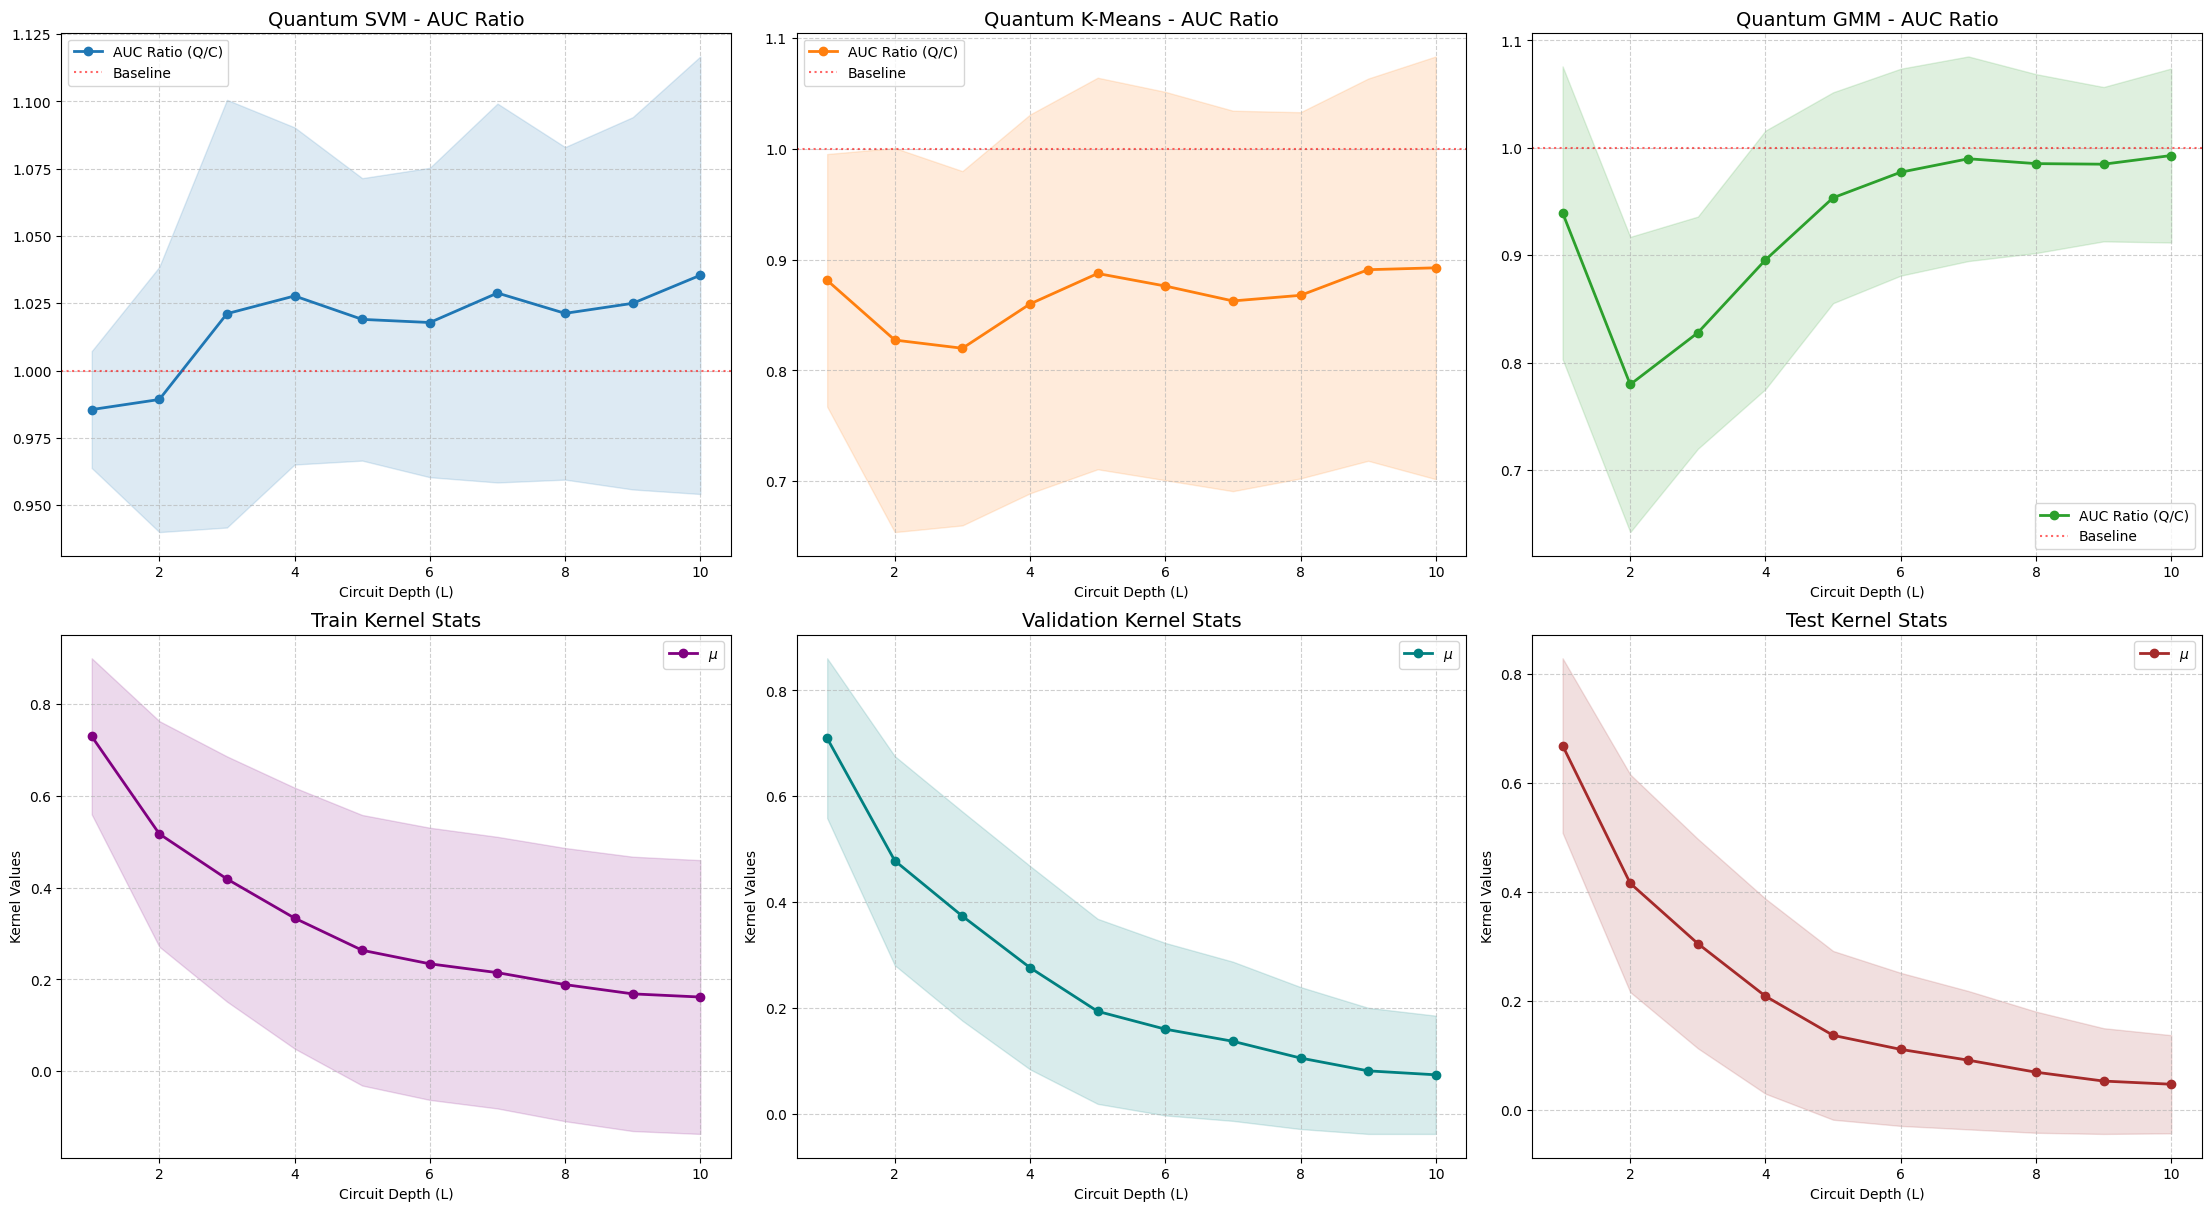

In [ ]:
#@title AUC ratio (Quantum/Classical) and Kernel ANALYSIS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load data
if download_results:
    df_all = pd.read_csv('processed_data/all_results.csv')
elif 'all_results' in globals()and len(all_results) != 0:
    df_all = pd.DataFrame(all_results)
else:
    raise Exception("No results to load!")

# Normalize quantum values
df_all['Ratio_SVM'] = df_all['Q_SVM_AUC'] / df_all['C_SVM_AUC']
df_all['Ratio_KMEANS'] = df_all['Q_KMEANS_AUC'] / df_all['C_KMEANS_AUC']
df_all['Ratio_GMM'] = df_all['Q_GMM_AUC'] / df_all['C_GMM_AUC']

# Grouping
df_mean = df_all.groupby(['L', 'Epsilon_s']).mean(numeric_only=True).reset_index()
df_std = df_all.groupby(['L', 'Epsilon_s']).std(numeric_only=True).reset_index()

df_m_ref = df_mean[df_mean['Epsilon_s'] == 0.7]
df_s_ref = df_std[df_std['Epsilon_s'] == 0.7]
L_plot = df_m_ref['L'].values

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)

# 1. Models Row (Top)
models = [
    ('Ratio_SVM', 'tab:blue', 'Quantum SVM'),
    ('Ratio_KMEANS', 'tab:orange', 'Quantum K-Means'),
    ('Ratio_GMM', 'tab:green', 'Quantum GMM')
]

for i, (col, color, title) in enumerate(models):
    ax = axes[0, i]
    ax.plot(L_plot, df_m_ref[col], marker='o', lw=2, color=color, label='AUC Ratio (Q/C)')
    ax.fill_between(L_plot, df_m_ref[col] - df_s_ref[col], df_m_ref[col] + df_s_ref[col], color=color, alpha=0.15)
    ax.axhline(1.0, color='red', linestyle=':', alpha=0.6, label='Baseline')
    ax.set_title(f"{title} - AUC Ratio", fontsize=14)
    ax.set_xlabel("Circuit Depth (L)")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

# 2. Kernel Stats Row (Bottom)
kernel_stats = [
    ('Ktrain_mu', 'Ktrain_std', 'purple', 'Train Kernel'),
    ('Kvali_mu', 'Kvali_std', 'teal', 'Validation Kernel'),
    ('Ktest_mu', 'Ktest_std', 'brown', 'Test Kernel')
]

for i, (mu_col, std_col, color, title) in enumerate(kernel_stats):
    ax = axes[1, i]
    ax.plot(L_plot, df_m_ref[mu_col], marker='o', lw=2, color=color, label=r'$\mu$')
    ax.fill_between(L_plot, df_m_ref[mu_col] - df_m_ref[std_col], df_m_ref[mu_col] + df_m_ref[std_col], color=color, alpha=0.15)
    ax.set_title(f"{title} Stats", fontsize=14)
    ax.set_xlabel("Circuit Depth (L)")
    ax.set_ylabel("Kernel Values")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.show()

In [ ]:
#@title Interactive Background rejection analysis
print("\n---  Interactive Plotly Dashboard for Delta_QC ---")

# Prepare data for Plotly by melting the delta columns into a long format
delta_cols = ['Delta_QC_SVM', 'Delta_QC_KMEANS', 'Delta_QC_GMM']
df_mean_long = df_mean.melt(id_vars=['L', 'Epsilon_s'], value_vars=delta_cols, var_name='Model', value_name='Delta_QC_mean')
df_std_long = df_std.melt(id_vars=['L', 'Epsilon_s'], value_vars=delta_cols, var_name='Model_std', value_name='Delta_QC_std')

# Merge mean and std for error bars
df_plotly = df_mean_long.copy()
df_plotly['Delta_QC_std'] = df_std_long['Delta_QC_std']
df_plotly['Model'] = df_plotly['Model'].str.replace('Delta_QC_', '') # Clean labels (SVM, KMEANS, GMM)

# Sort dataframe sequentially to prevent overlapping drawing artifacts on the slider
df_plotly = df_plotly.sort_values(by=['Epsilon_s', 'L'])

# Create interactive faceted plot (one column per Model) controlled by an Epsilon slider
fig_plotly = px.line(
    df_plotly,
    x='L',
    y='Delta_QC_mean',
    color='Model',               # Match static plot colors dynamically
    animation_frame='Epsilon_s', # Interactive slider component replacing discrete color traces
    facet_col='Model',
    error_y='Delta_QC_std',      # Error bars for ALL epsilon sweeps
    markers=True,
    title="Interactive Delta_QC Sweep across Models and Epsilon Targets",
    labels={'Delta_QC_mean': 'Delta QC (Q / C)', 'L': 'Circuit Depth (L)', 'Epsilon_s': 'Epsilon Target'},
    category_orders={"Model": ["SVM", "KMEANS", "GMM"]},
    color_discrete_map={"SVM": "#1f77b4", "KMEANS": "#ff7f0e", "GMM": "#2ca02c"} # Explicit matching colors mapping
)

# Add baseline horizontal reference line at 1.0 across all subplots
fig_plotly.add_hline(y=1.0, line_dash="dot", line_color="red", opacity=0.7, row="all", col="all")

# Improve layout styling
fig_plotly.update_layout(
    height=400,
    hovermode='x unified',
    title_font_size=16,
    showlegend=False # Hide redundant legend since models are cleanly split via facet_col
)
fig_plotly.update_traces(error_y_thickness=1.2, error_y_width=4)

fig_plotly.show()


---  Interactive Plotly Dashboard for Delta_QC ---


In [ ]:
#@title SVM-METRIC DECISION CURVES
import plotly.express as px
import pandas as pd
import pickle

# --- DATA INITIALIZATION ---
if 'all_results' not in globals() or len(all_results) == 0:
    with open('processed_data/all_results.pkl', 'rb') as f:
        all_results = pickle.load(f)


rows = []
seen_states = set()

for res in all_results:
    state_key = (res['Seed'], res['L'])
    if state_key in seen_states:
        continue
    seen_states.add(state_key)

    state = f"Seed: {res['Seed']} | L: {res['L']}"

    # Filtered only for SVM
    configs = [
        ('Classic', 'SVM', nus_sweep, res['svm_c_curve_train'], res['svm_c_curve_vali'], res['C_SVM_nu_chosen']),
        ('Quantum', 'SVM', nus_sweep, res['svm_q_curve_train'], res['svm_q_curve_vali'], res['SVM_nu_chosen']),
    ]

    for m_type, algo, x_vals, train_vals, vali_vals, chosen_val in configs:
        for i, x in enumerate(x_vals):
            rows.append({'Seed': res['Seed'], 'L': res['L'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': x, 'Score': train_vals[i], 'Curve': 'Train'})
            rows.append({'Seed': res['Seed'], 'L': res['L'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': x, 'Score': vali_vals[i], 'Curve': 'Vali'})

        y_min = min(min(train_vals), min(vali_vals))
        y_max = max(max(train_vals), max(vali_vals))
        y_margin = (y_max - y_min) * 0.15 if y_max != y_min else 0.1

        rows.append({'Seed': res['Seed'], 'L': res['L'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': chosen_val, 'Score': y_min - y_margin, 'Curve': 'Chosen Threshold'})
        rows.append({'Seed': res['Seed'], 'L': res['L'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': chosen_val, 'Score': y_max + y_margin, 'Curve': 'Chosen Threshold'})

df_viz = pd.DataFrame(rows).sort_values(by=['Seed', 'L', 'Type', 'Algorithm', 'Curve', 'X'])
ordered_states = df_viz['State'].unique().tolist()

fig = px.line(
    df_viz,
    x='X',
    y='Score',
    color='Curve',
    facet_row='Type',
    facet_col='Algorithm',
    animation_frame='State',
    category_orders={
        "Type": ["Classic", "Quantum"],
        "Algorithm": ["SVM"],
        "State": ordered_states
    },
    title="SVM Model Optimization Curves Comparison",
    color_discrete_map={
        'Train': '#1f77b4',
        'Vali': '#ff7f0e',
        'Chosen Threshold': 'red'
    },
    height=600, width=1200
)

# Line styling
fig.for_each_trace(
    lambda t: t.update(line=dict(dash='dash', width=2.5)) if t.name == 'Chosen Threshold' else t.update(line=dict(width=2))
)

fig.update_xaxes(matches=None)
fig.update_yaxes(matches=None)

# Set custom X padding
fig.update_xaxes(range=[-0.03, 0.54], col=1)

# Add clean bounding boxes
fig.update_xaxes(showline=True, linewidth=1, linecolor='rgba(100,100,100,0.6)', mirror=True, gridcolor='rgba(220,220,220,0.5)')
fig.update_yaxes(showline=True, linewidth=1, linecolor='rgba(100,100,100,0.6)', mirror=True, gridcolor='rgba(220,220,220,0.5)')

fig.update_xaxes(title_text="Nu Hyperparameter", col=1)
fig.update_yaxes(title_text="Inertia", col=1)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.update_layout(
    hovermode='x unified',
    legend_title_text='Curve Type',
    margin=dict(t=80, b=80, l=80, r=80)
)

fig.show()

## Dependence on entangling gates

In this section, a systematic and exploratory study (sweep) is conducted to numerically quantify the impact of quantum correlations on the discrimination capability of the anomaly detection model. When developing an algorithm based on **Quantum Kernel Methods**, the topology and intensity of entanglement within the *Quantum Feature Map* represent the true key hyperparameters dictating the success of the embedding into the Hilbert space.

Entanglement introduces non-local correlations among the different components of the latent vector (previously extracted by the classical Autoencoder). From a geometric perspective, applying two-qubit logic gates—such as the linear or circular CNOTs used in the circuit—allows the deformation and structuring of the metric induced by the quantum kernel:

$$K(x_i, x_j) = |\langle\phi(x_i)|\phi(x_j)\rangle|^2$$

Without this component, the qubits would evolve completely independently, reducing the algorithm to a trivial product of classical, one-dimensional kernels that are inherently incapable of mapping complex, non-linear interactions among the energetic jet features of the LHC Olympics dataset.

However, excessive entanglement or an overly high number of repeated layers risks inducing the **exponential flattening** phenomenon (closely related to geometric *Barren Plateaus*). In this regime, the kernel matrix decays toward a uniformly flat value, vanishing the variance and destroying the spatial separability between the Standard Model background and Beyond the Standard Model (BSM) signals.

In [ ]:
# Sweep over different entanglement connectivity scales with fixed L=6 and Real-time Circuit Drawing

#@title Run the sweep for Connectivity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.svm import OneClassSVM
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc, silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
import pickle

# --- CONFIGURATION ---
number_of_seeds = 10 #@param {"type":"slider","min":3,"max":20,"step":1}
seeds = []
for i in range(number_of_seeds):
    seeds.append(int(42 + i*100))

TOTAL_EVENTS = 10 #@param {type: 'slider', min: 10 , max: 600, step: '10'}
TOTAL_EVENTS_TEST = 100 # @param {"type":"slider","min":10,"max":800,"step":10}
fraction_of_anomalies = 0.5 # @param {"type":"slider","min":0.05,"max":0.5,"step":0.05}

n_anomalies = int(fraction_of_anomalies * TOTAL_EVENTS_TEST)
n_bg = TOTAL_EVENTS_TEST - n_anomalies
standardize = False #@param {type: "boolean"}

# --- VARIABLE CONFIGURATION---
FIXED_L = 6 #@param{type: 'slider', min:2, max:10, step:'1'}

# Generate the list of parameter to connect
n_q_connected_values = list(range(lat_dim, 1, -1))

nus_sweep = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1)
n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)
epsilon_s_list = [0.6, 0.7, 0.8, 0.9]
n_comp = lat_dim
covariance_type = 'diag' #@param ['full', 'tied', 'diag', 'spherical']

# --- CONFIGURATION ---
download_results = True #@param {'type': 'boolean'}

if download_results:
    path_results = 'processed_data/all_results_entanglement.csv'
    print("Loading of data, computed with:",
          "\nTOTAL_EVENTS = 10 TOTAL_EVENTS_TEST = 100 fraction_of_anomalies = 0.5 "," covariance_type = 'diag' ",
          "\n epsilon_s_list = [0.6, 0.7, 0.8, 0.9] nus_sweep:  [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]",
          "\n n_comp = lat_dim =8, k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1), n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)")
    if not os.path.exists(path_results):
        print("Downloading results:")
        url_ = "https://drive.google.com/uc?id=1YXCeJknlpMTvPOyVXP10Th1wAEhIehya"
        gdown.download(url_, path_results, quiet=False)
    path_results_pickle='processed_data/all_results_entanglement.pkl'
    print("Results ready.")

else:
    def compute_bg_rejection(fpr, tpr, target_eps):
        fpr_at_eps = np.interp(target_eps, tpr, fpr)
        return 1.0 / fpr_at_eps if fpr_at_eps > 0 else float('inf')

    # Helper for Elbow Method
    def get_elbow_idx(values):
        if len(values) < 3: return np.argmin(values)
        second_derivative = np.diff(values, n=2)
        return np.argmax(second_derivative) + 1

    # ==========================================================================================
    # --- SWEEP OVER L ---
    # ==========================================================================================
    all_results = []

    print(f"Starting sweep for Connectivity across {len(seeds)} random seeds with fixed L={FIXED_L}...\n")

    for seed in seeds:
        print(f"\n==========================================================================================")
        print(f" RUNNING SEED: {seed}")
        print(f"==========================================================================================")

        # --- 1. DATA PREPARATION FOR CURRENT SEED ---
        np.random.seed(seed)
        selected_bg_indices = np.random.choice(background_indices, n_bg, replace=False)

        #######################################################################
        # Create the selected anomaly indices from the test set
        selected_anomaly_indices = np.random.choice(anomaly_indices, n_anomalies, replace=False)
        quantum_test_indices = np.concatenate([selected_bg_indices, selected_anomaly_indices])
        np.random.shuffle(quantum_test_indices)
        ##################################################################
        total_bg_needed = 2 * TOTAL_EVENTS #validation and train same size
        all_train_val_indices = np.random.choice(len(latent_bg), total_bg_needed, replace=False)

        quantum_train_indices = all_train_val_indices[:TOTAL_EVENTS]
        quantum_vali_indices  = all_train_val_indices[TOTAL_EVENTS:]


        true_labels_100 = true_labels[quantum_test_indices]
        latent_train_100 = latent_bg[quantum_train_indices]
        latent_vali_100  = latent_bg[quantum_vali_indices]
        latent_test_100  = latent_blackbox[quantum_test_indices]


        # --- 1.5 COMPUTE CLASSICAL BASELINES FOR THIS SPECIFIC SEED ---
        kernel_rbf_train = rbf_kernel(latent_train_100)
        kernel_rbf_test  = rbf_kernel(latent_test_100, latent_train_100)
        kernel_rbf_vali  = rbf_kernel(latent_vali_100, latent_train_100)
        classical_baselines_per_eps = {}

        # Classical SVM (Elbow Method)
        svm_res = []
        for nu in nus_sweep:
            svm_c = OneClassSVM(kernel='precomputed', nu=nu).fit(kernel_rbf_train)

            inertia_train = np.sum(np.square(svm_c.decision_function(kernel_rbf_train)))
            inertia_vali  = np.sum(np.square(svm_c.decision_function(kernel_rbf_vali)))
            inertia_test  = np.sum(np.square(svm_c.decision_function(kernel_rbf_test)))
            svm_res.append({
                'nu': nu,
                'inertia_train': inertia_train,
                'inertia_vali': inertia_vali,
                'inertia_test': inertia_test,
                'model': svm_c
            })

        best_idx = get_elbow_idx([r['inertia_vali'] for r in svm_res])
        best_svm_c = svm_res[best_idx]
        chosen_c_nu = best_svm_c['nu']

        scores = -best_svm_c['model'].decision_function(kernel_rbf_test)
        fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_svm_auc = auc(fpr, tpr)
        if best_c_svm_auc < 0.5:
            best_c_svm_auc = 1 - best_c_svm_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_svm_fpr, best_c_svm_tpr = fpr, tpr

        # Classical KMeans (Silhouette)
        km_res = []
        for k in k_values_sweep:
            kmeans_c = KMeans(n_clusters=k, random_state=seed, n_init=100).fit(latent_train_100)

            labels_train = kmeans_c.labels_
            score_train = silhouette_score(latent_train_100, labels_train) if len(set(labels_train)) > 1 else -1

            labels_vali = kmeans_c.predict(latent_vali_100)
            score_vali = silhouette_score(latent_vali_100, labels_vali) if len(set(labels_vali)) > 1 else -1

            labels_test = kmeans_c.predict(latent_test_100)
            score_test = silhouette_score(latent_test_100, labels_test) if len(set(labels_test)) > 1 else -1

            km_res.append({
                'k': k,
                'silhouette_train': score_train,
                'silhouette_vali': score_vali,
                'silhouette_test': score_test,
                'model': kmeans_c
            })

        best_km_c = max(km_res, key=lambda x: x['silhouette_vali'])
        chosen_c_k = best_km_c['k']

        scores = np.min(best_km_c['model'].transform(latent_test_100), axis=1)
        fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_km_auc = auc(fpr, tpr)
        if best_c_km_auc < 0.5:
            best_c_km_auc = 1 - best_c_km_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_km_fpr, best_c_km_tpr = fpr, tpr

        # Classical GMM (BIC)
        gmm_res = []
        for n in n_values_sweep:
            gmm_c = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=seed).fit(latent_train_100)
            gmm_res.append({
                'n': n,
                'bic_train': gmm_c.bic(latent_train_100),
                'bic_vali': gmm_c.bic(latent_vali_100),
                'bic_test': gmm_c.bic(latent_test_100),
                'model': gmm_c
            })

        best_gmm_c = min(gmm_res, key=lambda x: x['bic_vali'])
        chosen_c_n = best_gmm_c['n']

        scores = -best_gmm_c['model'].score_samples(latent_test_100)
        fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_gmm_auc = auc(fpr, tpr)
        if best_c_gmm_auc < 0.5:
            best_c_gmm_auc = 1 - best_c_gmm_auc
            scores = -scores
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
        best_c_gmm_fpr, best_c_gmm_tpr = fpr, tpr

        for eps in epsilon_s_list:
            classical_baselines_per_eps[eps] = {
                'auc': (best_c_svm_auc, best_c_km_auc, best_c_gmm_auc),
                'rb': (compute_bg_rejection(best_c_svm_fpr, best_c_svm_tpr, eps),
                      compute_bg_rejection(best_c_km_fpr, best_c_km_tpr, eps),
                      compute_bg_rejection(best_c_gmm_fpr, best_c_gmm_tpr, eps)),
                'fpr': (best_c_svm_fpr, best_c_km_fpr, best_c_gmm_fpr),
                'tpr': (best_c_svm_tpr, best_c_km_tpr, best_c_gmm_tpr),
                'params': (chosen_c_nu, chosen_c_k, chosen_c_n)
            }

        # Print baseline reference for this seed
        print(f"--- CLASSICAL BASELINES Reference (Optimal Params Selected) ---")
        print(f"  SVM   -> AUC: {best_c_svm_auc:.4f} | chosen nu: {chosen_c_nu}")
        print(f"  KM    -> AUC: {best_c_km_auc:.4f} | chosen k : {chosen_c_k}")
        print(f"  GMM   -> AUC: {best_c_gmm_auc:.4f} | chosen n : {chosen_c_n}")
        print(f"------------------------------------------------------------------------------------------")

        # --- 2. SWEEP OVER CONNECTIVITY ---
        for n_connected in n_q_connected_values:
            x = ParameterVector('x', lat_dim)
            feature_per_qubit = 1
            REPETITIONS = 1
            mult = 0
            norm = 1
            n_q = (lat_dim // feature_per_qubit) * REPETITIONS
            feature_map = QuantumCircuit(n_q)


            for layer in range(FIXED_L):
                for i in range(n_q):
                    idx1 = (feature_per_qubit * i + mult*layer ) % lat_dim
                    idx2 = (feature_per_qubit * i + 1 + mult*layer) % lat_dim
                    feature_map.u(np.pi / 2, x[idx1]/(norm), x[idx2]/(norm), i)
                feature_map.barrier()

                # --- limited entangled ---
                for i in range(n_connected):
                    target_qubit = (i + 1) % n_q
                    feature_map.cx(i, target_qubit)
                feature_map.barrier()

                for i in range(n_q):
                    idx1 = (feature_per_qubit * i + mult*layer) % lat_dim
                    idx2 = (feature_per_qubit * i + 1 + mult*layer) % lat_dim
                    feature_map.u(x[idx1]/(norm), x[idx2]/(norm), 0, i)
                if layer < FIXED_L - 1:
                    feature_map.barrier()

            # --- INSERIMENTO DISEGNO IN TEMPO REALE ---
            # Disegnamo il circuito ad ogni step solo per il primo seed per evitare sovraccarichi grafici
            #if seed == seeds[0]:
            #   print(f"\n[DISEGNO CIRCUITO] Visualizzazione per Connettività = {n_connected} (Visualizzato solo per il primo Seed)")
            #  display(feature_map.draw(output='mpl', style='iqp'))
            # plt.show() # Assicura la corretta chiusura e rendering della figura Matplotlib

            fidelity_kernel = FidelityQuantumKernel(feature_map=feature_map)
            kernel_matrix_train_sweep = fidelity_kernel.evaluate(x_vec=latent_train_100)
            kernel_matrix_test_sweep = fidelity_kernel.evaluate(x_vec=latent_test_100, y_vec=latent_train_100)
            kernel_matrix_vali_sweep = fidelity_kernel.evaluate(x_vec=latent_vali_100, y_vec=latent_train_100)

            # QUANTUM SVM (Elbow)
            q_svm_res = []
            for nu in nus_sweep:
                svm_q = OneClassSVM(kernel='precomputed', nu=nu).fit(kernel_matrix_train_sweep)
                inertia_train = np.sum(np.square(svm_q.decision_function(kernel_matrix_train_sweep)))
                inertia_vali  = np.sum(np.square(svm_q.decision_function(kernel_matrix_vali_sweep)))
                inertia_test  = np.sum(np.square(svm_q.decision_function(kernel_matrix_test_sweep)))
                q_svm_res.append({
                    'nu': nu,
                    'inertia_train': inertia_train,
                    'inertia_vali': inertia_vali,
                    'inertia_test': inertia_test,
                    'model': svm_q
                })

            best_q = q_svm_res[get_elbow_idx([r['inertia_vali'] for r in q_svm_res])]
            chosen_nu, svm_q = best_q['nu'], best_q['model']

            scores = -svm_q.decision_function(kernel_matrix_test_sweep)
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_svm_auc = auc(fpr, tpr)
            if best_q_svm_auc < 0.5:
                best_q_svm_auc, scores = 1 - best_q_svm_auc, -scores
                fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_svm_fpr, best_q_svm_tpr = fpr, tpr

            # QUANTUM K-MEANS (Silhouette)
            kpca = KernelPCA(n_components=n_comp, kernel='precomputed')
            latent_q_train_sweep = kpca.fit_transform(kernel_matrix_train_sweep)
            latent_q_test_sweep = kpca.transform(kernel_matrix_test_sweep)
            latent_q_vali_sweep = kpca.transform(kernel_matrix_vali_sweep)

            q_km_res = []
            for k in k_values_sweep:
                kmeans_q = KMeans(n_clusters=k, random_state=seed, n_init=100).fit(latent_q_train_sweep)

                labels_q_train = kmeans_q.labels_
                score_train = silhouette_score(latent_q_train_sweep, labels_q_train) if len(set(labels_q_train)) > 1 else -1

                labels_q_vali = kmeans_q.predict(latent_q_vali_sweep)
                score_vali = silhouette_score(latent_q_vali_sweep, labels_q_vali) if len(set(labels_q_vali)) > 1 else -1

                labels_q_test = kmeans_q.predict(latent_q_test_sweep)
                score_test = silhouette_score(latent_q_test_sweep, labels_q_test) if len(set(labels_q_test)) > 1 else -1

                q_km_res.append({
                    'k': k,
                    'silhouette_train': score_train,
                    'silhouette_vali': score_vali,
                    'silhouette_test': score_test,
                    'model': kmeans_q
                })

            best_q_km = max(q_km_res, key=lambda x: x['silhouette_vali'])
            chosen_k, kmeans_q = best_q_km['k'], best_q_km['model']

            scores = np.min(kmeans_q.transform(latent_q_test_sweep), axis=1)
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_km_auc = auc(fpr, tpr)
            if best_q_km_auc < 0.5:
                best_q_km_auc, scores = 1 - best_q_km_auc, -scores
                fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_km_fpr, best_q_km_tpr = fpr, tpr

            # QUANTUM GMM (BIC)
            q_gmm_res = []
            for n in n_values_sweep:
                gmm_q = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=seed).fit(latent_q_train_sweep)
                q_gmm_res.append({
                    'n': n,
                    'bic_train': gmm_q.bic(latent_q_train_sweep),
                    'bic_vali': gmm_q.bic(latent_q_vali_sweep),
                    'bic_test': gmm_q.bic(latent_q_test_sweep),
                    'model': gmm_q
                })

            best_q_gmm = min(q_gmm_res, key=lambda x: x['bic_vali'])
            chosen_n, gmm_q = best_q_gmm['n'], best_q_gmm['model']

            scores = -gmm_q.score_samples(latent_q_test_sweep)
            fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_gmm_auc = auc(fpr, tpr)
            if best_q_gmm_auc < 0.5:
                best_q_gmm_auc, scores = 1 - best_q_gmm_auc, -scores
                fpr, tpr, _ = roc_curve(true_labels_100, scores)
            best_q_gmm_fpr, best_q_gmm_tpr = fpr, tpr

            # Log delle performance stampato subito dopo l'immagine corrispondente
            print(
                f"Connected Qubits={n_connected:2d}/{n_q} | "
                f"SVM [Ratio: {best_q_svm_auc/best_c_svm_auc:.3f}] -> AUC(Q/C): {best_q_svm_auc:.3f}/{best_c_svm_auc:.3f} | nu(Q/C): {chosen_nu:.2f}/{chosen_c_nu:.2f}\n"
                f"    KM  [Ratio: {best_q_km_auc/best_c_km_auc:.3f}] -> AUC(Q/C): {best_q_km_auc:.3f}/{best_c_km_auc:.3f} | k(Q/C): {chosen_k}/{chosen_c_k} (Sil_Q_Vali: {max([r['silhouette_vali'] for r in q_km_res]):.3f})\n"
                f"    GMM [Ratio: {best_q_gmm_auc/best_c_gmm_auc:.3f}] -> AUC(Q/C): {best_q_gmm_auc:.3f}/{best_c_gmm_auc:.3f} | n(Q/C): {chosen_n}/{chosen_c_n} (BIC_Q_Vali: {min([r['bic_vali'] for r in q_gmm_res]):.1f})\n"
                f"------------------------------------------------------------------------------------------"
            )

            for eps in epsilon_s_list:
                c_data = classical_baselines_per_eps[eps]
                all_results.append({
                    'Seed': seed, 'L': FIXED_L, 'Connected_Qubits': n_connected, 'Epsilon_s': eps,
                    'Q_SVM_AUC': best_q_svm_auc, 'Q_SVM_FPR': best_q_svm_fpr, 'Q_SVM_TPR': best_q_svm_tpr, 'SVM_nu_chosen': chosen_nu, 'C_SVM_nu_chosen': chosen_c_nu, 'Q_SVM_Rb': compute_bg_rejection(best_q_svm_fpr, best_q_svm_tpr, eps),
                    'Delta_QC_SVM': compute_bg_rejection(best_q_svm_fpr, best_q_svm_tpr, eps) / c_data['rb'][0],
                    'Q_KMEANS_AUC': best_q_km_auc, 'Q_KMEANS_FPR': best_q_km_fpr, 'Q_KMEANS_TPR': best_q_km_tpr, 'KM_k_chosen': chosen_k, 'C_KM_k_chosen': chosen_c_k, 'Q_KMEANS_Rb': compute_bg_rejection(best_q_km_fpr, best_q_km_tpr, eps),
                    'Delta_QC_KMEANS': compute_bg_rejection(best_q_km_fpr, best_q_km_tpr, eps) / c_data['rb'][1],
                    'Q_GMM_AUC': best_q_gmm_auc, 'Q_GMM_FPR': best_q_gmm_fpr, 'Q_GMM_TPR': best_q_gmm_tpr, 'GMM_n_chosen': chosen_n, 'C_GMM_n_chosen': chosen_c_n, 'Q_GMM_Rb': compute_bg_rejection(best_q_gmm_fpr, best_q_gmm_tpr, eps),
                    'Delta_QC_GMM': compute_bg_rejection(best_q_gmm_fpr, best_q_gmm_tpr, eps) / c_data['rb'][2],
                    'C_SVM_AUC': c_data['auc'][0], 'C_SVM_FPR': c_data['fpr'][0], 'C_SVM_TPR': c_data['tpr'][0],
                    'C_KMEANS_AUC': c_data['auc'][1], 'C_KMEANS_FPR': c_data['fpr'][1], 'C_KMEANS_TPR': c_data['tpr'][1],
                    'C_GMM_AUC': c_data['auc'][2], 'C_GMM_FPR': c_data['fpr'][2], 'C_GMM_TPR': c_data['tpr'][2],
                    'Ktrain_mu': kernel_matrix_train_sweep.mean(), 'Ktrain_std': kernel_matrix_train_sweep.std(),
                    'Ktest_mu': kernel_matrix_test_sweep.mean(), 'Ktest_std': kernel_matrix_test_sweep.std(),

                    'svm_c_curve_train': [r['inertia_train'] for r in svm_res],
                    'svm_c_curve_vali':  [r['inertia_vali'] for r in svm_res],
                    'svm_c_curve_test':  [r['inertia_test'] for r in svm_res],

                    'km_c_curve_train':  [r['silhouette_train'] for r in km_res],
                    'km_c_curve_vali':   [r['silhouette_vali'] for r in km_res],
                    'km_c_curve_test':   [r['silhouette_test'] for r in km_res],

                    'gmm_c_curve_train': [r['bic_train'] for r in gmm_res],
                    'gmm_c_curve_vali':  [r['bic_vali'] for r in gmm_res],
                    'gmm_c_curve_test':  [r['bic_test'] for r in gmm_res],

                    'svm_q_curve_train': [r['inertia_train'] for r in q_svm_res],
                    'svm_q_curve_vali':  [r['inertia_vali'] for r in q_svm_res],
                    'svm_q_curve_test':  [r['inertia_test'] for r in q_svm_res],

                    'km_q_curve_train':  [r['silhouette_train'] for r in q_km_res],
                    'km_q_curve_vali':   [r['silhouette_vali'] for r in q_km_res],
                    'km_q_curve_test':   [r['silhouette_test'] for r in q_km_res],

                    'gmm_q_curve_train': [r['bic_train'] for r in q_gmm_res],
                    'gmm_q_curve_vali':  [r['bic_vali'] for r in q_gmm_res],
                    'gmm_q_curve_test':  [r['bic_test'] for r in q_gmm_res],
                    })

    print("\nSweep Completed!")

    # --- FILE SAVING SECTIONS ---
    with open('processed_data/all_results_entanglement.pkl', 'wb') as f:
        pickle.dump(all_results, f)
    print("Results saved in 'all_results_entanglement.pkl'")

    df_export = pd.DataFrame(all_results)
    df_export.to_csv('processed_data/all_results_entanglement.csv', index=False)
    print("Results saved in 'all_results_entanglement.csv'")

Loading of data, computed with: 
TOTAL_EVENTS = 10 TOTAL_EVENTS_TEST = 100 fraction_of_anomalies = 0.5   covariance_type = 'diag'  
 epsilon_s_list = [0.6, 0.7, 0.8, 0.9] nus_sweep:  [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5] 
 n_comp = lat_dim =8, k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1), n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)


Downloading...
From: https://drive.google.com/uc?id=1YXCeJknlpMTvPOyVXP10Th1wAEhIehya
To: /content/processed_data/all_results_entanglement.csv
100%|██████████| 2.12M/2.12M [00:00<00:00, 165MB/s]

Results ready.


### Comments
In this plot, we recognize an increasing behavior with the entanglement level, especially for **Q-SVM**, which from 4 entangled qubits onward scales up monotonically, outperforming the classical RBF baseline by ~5% at full ring topology (8 qubits) and proving that Hilbert space connectivity is essential to unlock quantum expressivity.

Meanwhile, **Q-GMM** and **Q-KMeans** remain consistently below the classical threshold: Q-GMM eventually reaches a plateau of quantum-classical parity, while Q-KMeans oscillates without matching the baseline. This sub-classical performance is due to the intermediate Kernel PCA step required by clustering, which acts as a low-pass filter and dilutes the quantum signal in the PCA space.


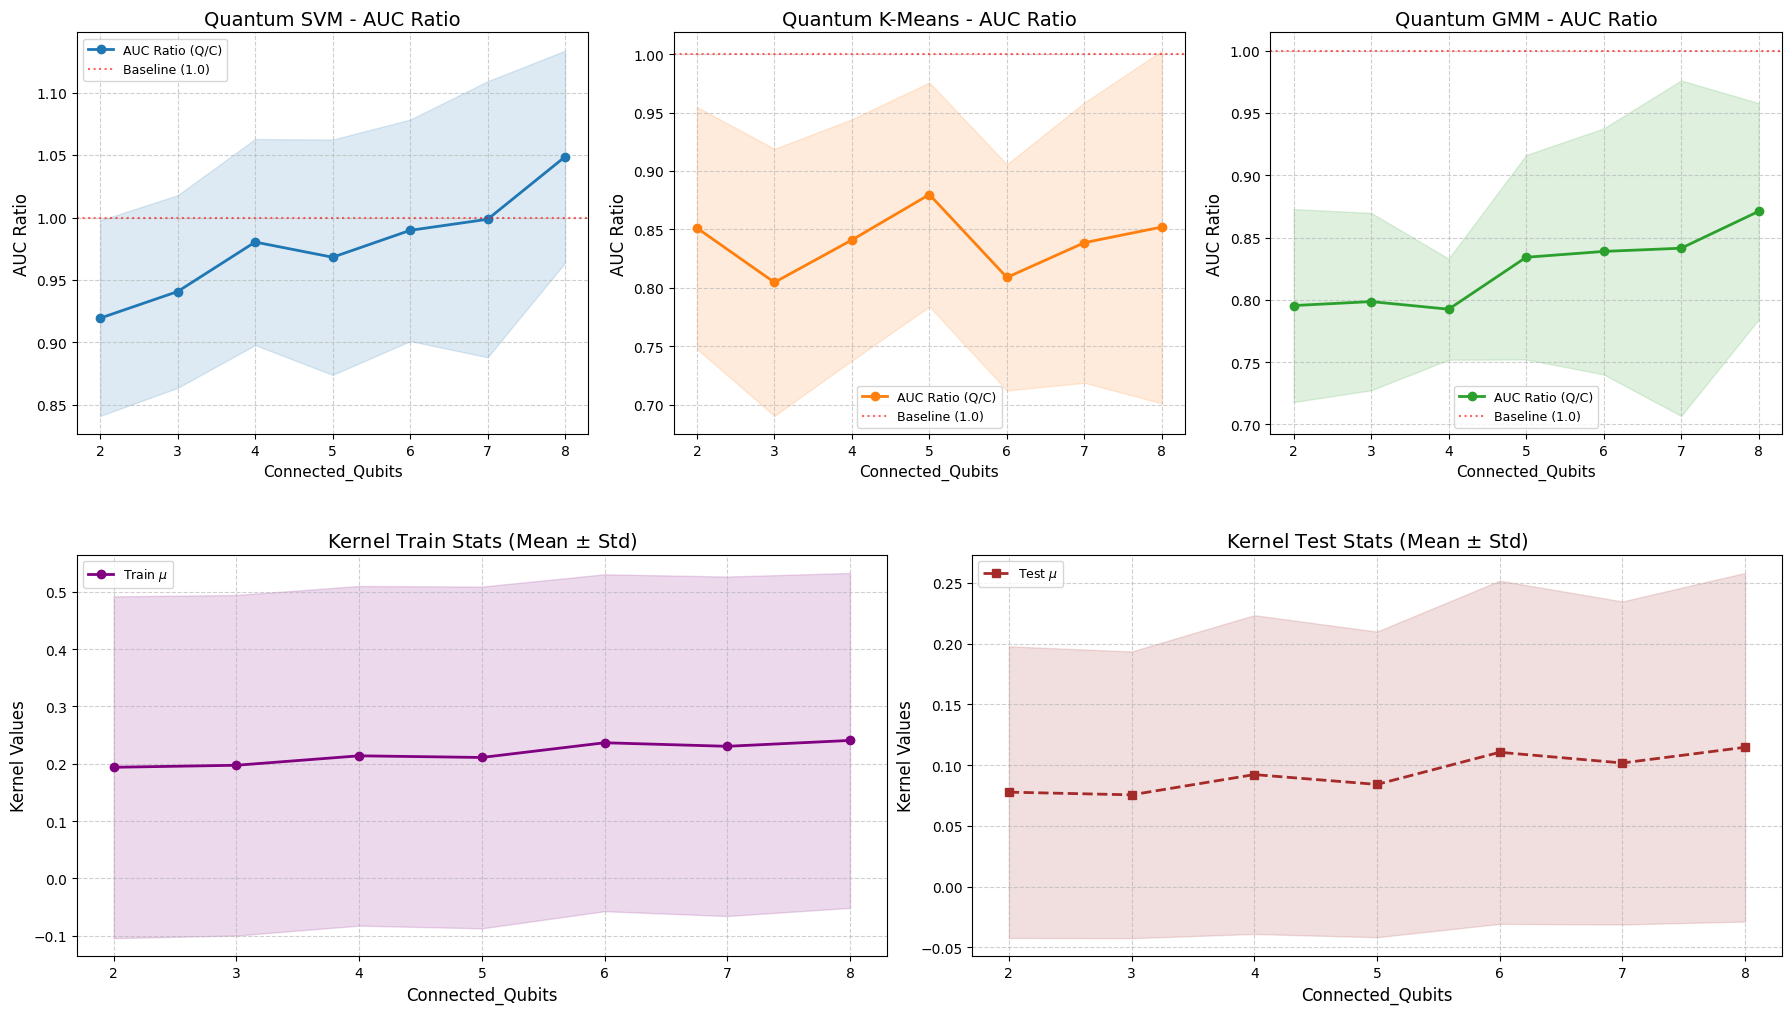

In [ ]:
#@title plot Grid with Plotly for Delta_QC
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Load data
if download_results:
    df_all = pd.read_csv('processed_data/all_results_entanglement.csv')
elif 'all_results' in globals() and len(all_results) != 0:
    df_all = pd.DataFrame(all_results)
else:
    raise Exception("No results to load!")



# Normalize quantum values per seed by classical values
df_all['Ratio_SVM'] = df_all['Q_SVM_AUC'] / df_all['C_SVM_AUC']
df_all['Ratio_KMEANS'] = df_all['Q_KMEANS_AUC'] / df_all['C_KMEANS_AUC']
df_all['Ratio_GMM'] = df_all['Q_GMM_AUC'] / df_all['C_GMM_AUC']

# Calculate statistics grouping by both nq and Epsilon_s (FIX: added numeric_only=True to prevent broadcast errors)
df_mean = df_all.groupby(['Connected_Qubits', 'Epsilon_s']).mean(numeric_only=True).reset_index()
df_std = df_all.groupby(['Connected_Qubits', 'Epsilon_s']).std(numeric_only=True).reset_index()

# ==========================================
# 1. MATPLOTLIB: AUC RATIO & KERNEL STATS
# ==========================================
# Creating a custom layout: Row 1 has 3 plots (AUC), Row 2 has 2 plots (Kernels)
fig = plt.figure(figsize=(22, 12))
from matplotlib.gridspec import GridSpec

# Define a 2x6 grid to easily balance 3 columns on top and 2 columns on bottom
# Row 0: 3 columns -> each takes 2 grid units (0-2, 2-4, 4-6)
# Row 1: 2 columns -> each takes 3 grid units (0-3, 3-6)
gs = GridSpec(2, 6, figure=fig, hspace=0.3, wspace=0.4)

ax_svm = fig.add_subplot(gs[0, 0:2])
ax_km  = fig.add_subplot(gs[0, 2:4])
ax_gmm = fig.add_subplot(gs[0, 4:6])

ax_ktrain = fig.add_subplot(gs[1, 0:3])
ax_ktest  = fig.add_subplot(gs[1, 3:6])

# Filter epsilon=0.7 as reference for the static AUC/Kernel plots
df_m_ref = df_mean[df_mean['Epsilon_s'] == 0.7]
df_s_ref = df_std[df_std['Epsilon_s'] == 0.7]
n_plot = df_m_ref['Connected_Qubits'].values

# Top Row: AUC Ratios
models_auc = [
    (ax_svm, 'Ratio_SVM', 'tab:blue', 'Quantum SVM'),
    (ax_km,  'Ratio_KMEANS', 'tab:orange', 'Quantum K-Means'),
    (ax_gmm, 'Ratio_GMM', 'tab:green', 'Quantum GMM')
]

for ax, ratio_col, color, label in models_auc:
    ax.plot(n_plot, df_m_ref[ratio_col], marker='o', lw=2, color=color, label='AUC Ratio (Q/C)')
    ax.fill_between(n_plot, df_m_ref[ratio_col] - df_s_ref[ratio_col], df_m_ref[ratio_col] + df_s_ref[ratio_col], color=color, alpha=0.15)
    ax.axhline(1.0, color='red', linestyle=':', alpha=0.6, label='Baseline (1.0)')
    ax.set_title(f"{label} - AUC Ratio", fontsize=14)
    ax.set_xlabel("Connected_Qubits", fontsize=11)
    ax.set_ylabel("AUC Ratio", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.6)

# Bottom Row: Kernel Matrix Stats
# Train Kernel Mean & Std
ax_ktrain.plot(n_plot, df_m_ref['Ktrain_mu'], marker='o', lw=2, color='purple', label=r'Train $\mu$')
ax_ktrain.fill_between(n_plot, df_m_ref['Ktrain_mu'] - df_m_ref['Ktrain_std'], df_m_ref['Ktrain_mu'] + df_m_ref['Ktrain_std'], color='purple', alpha=0.15)
ax_ktrain.set_title(r"Kernel Train Stats (Mean $\pm$ Std)", fontsize=14)
ax_ktrain.set_xlabel("Connected_Qubits", fontsize=12)
ax_ktrain.set_ylabel("Kernel Values", fontsize=12)
ax_ktrain.legend(fontsize=9)
ax_ktrain.grid(True, linestyle='--', alpha=0.6)

# Test Kernel Mean & Std
ax_ktest.plot(n_plot, df_m_ref['Ktest_mu'], marker='s', linestyle='--', lw=2, color='brown', label=r'Test $\mu$')
ax_ktest.fill_between(n_plot, df_m_ref['Ktest_mu'] - df_m_ref['Ktest_std'], df_m_ref['Ktest_mu'] + df_m_ref['Ktest_std'], color='brown', alpha=0.15)
ax_ktest.set_title(r"Kernel Test Stats (Mean $\pm$ Std)", fontsize=14)
ax_ktest.set_xlabel("Connected_Qubits", fontsize=12)
ax_ktest.set_ylabel("Kernel Values", fontsize=12)
ax_ktest.legend(fontsize=9)
ax_ktest.grid(True, linestyle='--', alpha=0.6)

plt.show()

# ==========================================
# 2. INTERACTIVE DELTA_QC
# ==========================================

# Prepare data for Plotly by melting the delta columns into a long format
delta_cols = ['Delta_QC_SVM', 'Delta_QC_KMEANS', 'Delta_QC_GMM']
df_mean_long = df_mean.melt(id_vars=['Connected_Qubits', 'Epsilon_s'], value_vars=delta_cols, var_name='Model', value_name='Delta_QC_mean')
df_std_long = df_std.melt(id_vars=['Connected_Qubits', 'Epsilon_s'], value_vars=delta_cols, var_name='Model_std', value_name='Delta_QC_std')

# Merge mean and std for error bars
df_plotly = df_mean_long.copy()
df_plotly['Delta_QC_std'] = df_std_long['Delta_QC_std']
df_plotly['Model'] = df_plotly['Model'].str.replace('Delta_QC_', '') # Clean labels (SVM, KMEANS, GMM)

# Sort dataframe sequentially to prevent overlapping drawing artifacts on the slider
df_plotly = df_plotly.sort_values(by=['Epsilon_s', 'Connected_Qubits'])

# Create interactive faceted plot (one column per Model) controlled by an Epsilon slider
fig_plotly = px.line(
    df_plotly,
    x='Connected_Qubits',
    y='Delta_QC_mean',
    color='Model',               # Match static plot colors dynamically
    animation_frame='Epsilon_s', # Interactive slider component replacing discrete color traces
    facet_col='Model',
    error_y='Delta_QC_std',      # Error bars for ALL epsilon sweeps
    markers=True,
    title="Interactive Delta_QC Sweep across Models and Epsilon Targets",
    labels={'Delta_QC_mean': 'Delta QC (Q / C)', 'Connected_Qubits': 'Connected_Qubits', 'Epsilon_s': 'Epsilon Target'},
    category_orders={"Model": ["SVM", "KMEANS", "GMM"]},
    color_discrete_map={"SVM": "#1f77b4", "KMEANS": "#ff7f0e", "GMM": "#2ca02c"} # Explicit matching colors mapping
)

# Add baseline horizontal reference line at 1.0 across all subplots
fig_plotly.add_hline(y=1.0, line_dash="dot", line_color="red", opacity=0.7, row="all", col="all")

# Improve layout styling
fig_plotly.update_layout(
    height=550,
    hovermode='x unified',
    title_font_size=16,
    showlegend=False # Hide redundant legend since models are cleanly split via facet_col
)
fig_plotly.update_traces(error_y_thickness=1.2, error_y_width=4)

fig_plotly.show()

## Dependence on training size

In the previous section we explored the dependencies of the performances for this circuit for a very small train size. However, Q-GMM and Q-KMEANS computed over the Kernel-PCA space could not outperform classical algorityms: this is an intrinsic tradeoff due to difficulty to generalize unsupervised clustering via 10 events.

In this section we try to assess if with higher train size these algorythms could perform better, running a very small sweep code over 5 increasing train size, keeping fixed L=6.

In [ ]:
#@title Run the sweep for TRAIN SIZE & EPSILON (Integrated with fixed L & Download)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.svm import OneClassSVM
from sklearn.decomposition import KernelPCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import roc_curve, auc, silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
import pickle
import os
import gdown

# --- CONFIGURATION ---
download_results = True #@param {'type': 'boolean'}

number_of_seeds = 10 # @param {"type":"slider","min":2,"max":20,"step":1}
seeds = [int(42 + i*100) for i in range(number_of_seeds)]

TOTAL_EVENTS_TEST = 100 # @param {"type":"slider","min":10,"max":800,"step":10}
fraction_of_anomalies = 0.5 # @param {"type":"slider","min":0.05,"max":0.5,"step":0.05}

n_anomalies = int(fraction_of_anomalies * TOTAL_EVENTS_TEST)
n_bg = TOTAL_EVENTS_TEST - n_anomalies

train_sizes = [10, 20, 30, 40, 50]
epsilon_sweep = [0.6,0.65, 0.7,0.75, 0.8, 0.85, 0.9, 0.95] # Target TPR thresholds for Background Rejection

# Fixing L here
L = 1 #@param {"type":"slider", "min":1, "max":10}

n_comp = lat_dim
nus_sweep = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
covariance_type = 'diag'

if download_results:
    print("Downloading of data, computed with:",
          "\ntrain_sizes = [10, 20, 30, 40, 50], L=6,  TOTAL_EVENTS_TEST = 100 fraction_of_anomalies = 0.5 "," covariance_type = 'diag' ",
          "\n epsilon_s_list = [0.6, 0.7, 0.8, 0.9] nus_sweep:  [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]",
          "\n n_comp = lat_dim =8, k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1), n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)")

    path_results = 'processed_data/all_results_trainsize.csv'
    if not os.path.exists(path_results):
        gdown.download("https://drive.google.com/uc?id=1iM0-Qgt7RAno_ILXxLirlzvhEJuB3Fia", path_results, quiet=False)

    path_results_pickle = 'processed_data/all_results_trainsize.pkl'
    if not os.path.exists(path_results_pickle):
        gdown.download("https://drive.google.com/uc?id=1qqS85Abm1quSPkNlnVqJtp3GXuTwUny6", path_results_pickle, quiet=False)

else:
    def get_elbow_idx(values):
        if len(values) < 3: return np.argmin(values)
        second_derivative = np.diff(values, n=2)
        return np.argmax(second_derivative) + 1

    def compute_bg_rejection(fpr, tpr, target_eps):
        fpr_at_eps = np.interp(target_eps, tpr, fpr)
        return 1.0 / fpr_at_eps if fpr_at_eps > 0 else float('inf')

    all_results_trainsize = []

    for seed in seeds:
        for train_size in train_sizes:
            print(f"  -> Seed: {seed} | Train Size: {train_size}")

            k_values_sweep = range(2, max(2, int(np.sqrt(train_size / 2))) + 1)
            n_values_sweep = range(1, max(1, train_size // (n_comp + 1)) + 1)

            np.random.seed(seed)
            n_val = train_size


            selected_bg_indices = np.random.choice(background_indices, n_bg, replace=False)

            #######################################################################
            # Create the selected anomaly indices from the test set
            selected_anomaly_indices = np.random.choice(anomaly_indices, n_anomalies, replace=False)
            quantum_test_indices = np.concatenate([selected_bg_indices, selected_anomaly_indices])
            np.random.shuffle(quantum_test_indices)
            ##################################################################
            total_bg_needed = train_size + n_val #validation and train same size
            all_train_val_indices = np.random.choice(len(latent_bg), total_bg_needed, replace=False)

            quantum_train_indices = all_train_val_indices[:TOTAL_EVENTS]
            quantum_vali_indices  = all_train_val_indices[TOTAL_EVENTS:]


            true_labels_100 = true_labels[quantum_test_indices]
            latent_train_100 = latent_bg[quantum_train_indices]
            latent_val_100  = latent_bg[quantum_vali_indices]
            latent_test_100  = latent_blackbox[quantum_test_indices]




            # --- CLASSICAL MODELS ---
            svm_res = []
            for nu in nus_sweep:
                model = OneClassSVM(kernel='precomputed', nu=nu).fit(rbf_kernel(latent_train_100))
                train_metric = np.sum(np.square(model.decision_function(rbf_kernel(latent_train_100))))
                val_metric = np.sum(np.square(model.decision_function(rbf_kernel(latent_val_100, latent_train_100))))
                svm_res.append({'nu': nu, 'train': train_metric, 'val': val_metric, 'model': model})

            best_idx = get_elbow_idx([r['val'] for r in svm_res])
            chosen_c_nu, svm_c = svm_res[best_idx]['nu'], svm_res[best_idx]['model']
            svm_c_train, svm_c_val = [r['train'] for r in svm_res], [r['val'] for r in svm_res]

            km_res = []
            for k in k_values_sweep:
                model = KMeans(n_clusters=k, random_state=seed, n_init=20).fit(latent_train_100)
                train_metric = silhouette_score(latent_train_100, model.labels_) if len(set(model.labels_)) > 1 else -1
                labels_val = model.predict(latent_val_100)
                val_metric = silhouette_score(latent_val_100, labels_val) if len(set(labels_val)) > 1 else -1
                km_res.append({'k': k, 'train': train_metric, 'val': val_metric, 'model': model})

            best_idx = np.argmax([r['val'] for r in km_res])
            chosen_c_k, km_c = km_res[best_idx]['k'], km_res[best_idx]['model']
            km_c_train, km_c_val = [r['train'] for r in km_res], [r['val'] for r in km_res]

            gmm_res = []
            for n in n_values_sweep:
                model = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=seed).fit(latent_train_100)
                train_metric = model.bic(latent_train_100)
                val_metric = model.bic(latent_val_100)
                gmm_res.append({'n': n, 'train': train_metric, 'val': val_metric, 'model': model})

            best_idx = np.argmin([r['val'] for r in gmm_res])
            chosen_c_n, gmm_c = gmm_res[best_idx]['n'], gmm_res[best_idx]['model']
            gmm_c_train, gmm_c_val = [r['train'] for r in gmm_res], [r['val'] for r in gmm_res]

            # --- QUANTUM MODELS ---
            x = ParameterVector('x', lat_dim)
            feature_per_qubit = 1
            REPETITIONS = 1
            mult = 0
            norm = 1
            n_q = (lat_dim // feature_per_qubit) * REPETITIONS
            feature_map = QuantumCircuit(n_q)

            for layer in range(L):
                for i in range(n_q):
                    idx1 = (feature_per_qubit * i + mult*layer ) % lat_dim
                    idx2 = (feature_per_qubit * i + 1 + mult*layer) % lat_dim
                    feature_map.u(np.pi / 2, x[idx1]/(norm), x[idx2]/(norm), i)
                feature_map.barrier()
                for i in range(n_q):
                    feature_map.cx(i, (i + 1) % n_q)
                feature_map.barrier()
                for i in range(n_q):
                    idx1 = (feature_per_qubit * i + mult*layer) % lat_dim
                    idx2 = (feature_per_qubit * i + 1 + mult*layer) % lat_dim
                    feature_map.u(x[idx1]/(norm), x[idx2]/(norm), 0, i)
                if layer < L - 1:
                    feature_map.barrier()

            fidelity_kernel = FidelityQuantumKernel(feature_map=feature_map)

            K_train = fidelity_kernel.evaluate(x_vec=latent_train_100)
            K_val   = fidelity_kernel.evaluate(x_vec=latent_val_100, y_vec=latent_train_100)
            K_test  = fidelity_kernel.evaluate(x_vec=latent_test_100, y_vec=latent_train_100)

            q_svm_res = []
            for nu in nus_sweep:
                model = OneClassSVM(kernel='precomputed', nu=nu).fit(K_train)
                train_metric = np.sum(np.square(model.decision_function(K_train)))
                val_metric = np.sum(np.square(model.decision_function(K_val)))
                q_svm_res.append({'nu': nu, 'train': train_metric, 'val': val_metric, 'model': model})

            best_idx = get_elbow_idx([r['val'] for r in q_svm_res])
            chosen_nu, svm_q = q_svm_res[best_idx]['nu'], q_svm_res[best_idx]['model']
            svm_q_train, svm_q_val = [r['train'] for r in q_svm_res], [r['val'] for r in q_svm_res]

            kpca = KernelPCA(n_components=n_comp, kernel='precomputed').fit(K_train)
            X_q_train = kpca.transform(K_train)
            X_q_val = kpca.transform(K_val)

            q_km_res = []
            for k in k_values_sweep:
                model = KMeans(n_clusters=k, random_state=seed, n_init=20).fit(X_q_train)
                train_metric = silhouette_score(X_q_train, model.labels_) if len(set(model.labels_)) > 1 else -1
                labels_val = model.predict(X_q_val)
                val_metric = silhouette_score(X_q_val, labels_val) if len(set(labels_val)) > 1 else -1
                q_km_res.append({'k': k, 'train': train_metric, 'val': val_metric, 'model': model})

            best_idx = np.argmax([r['val'] for r in q_km_res])
            chosen_k, km_q = q_km_res[best_idx]['k'], q_km_res[best_idx]['model']
            km_q_train, km_q_val = [r['train'] for r in q_km_res], [r['val'] for r in q_km_res]

            q_gmm_res = []
            for n in n_values_sweep:
                model = GaussianMixture(n_components=n, covariance_type=covariance_type, random_state=seed).fit(X_q_train)
                train_metric = model.bic(X_q_train)
                val_metric = model.bic(X_q_val)
                q_gmm_res.append({'n': n, 'train': train_metric, 'val': val_metric, 'model': model})

            best_idx = np.argmin([r['val'] for r in q_gmm_res])
            chosen_n, gmm_q = q_gmm_res[best_idx]['n'], q_gmm_res[best_idx]['model']
            gmm_q_train, gmm_q_val = [r['train'] for r in q_gmm_res], [r['val'] for r in q_gmm_res]

            # --- METRICS CALCULATION (WITH PROPER AUC/FPR/TPR CORRECTION) ---

            # C-SVM
            c_svm_scores = svm_c.decision_function(rbf_kernel(latent_test_100, latent_train_100))
            c_svm_fpr, c_svm_tpr, _ = roc_curve(true_labels_100, -c_svm_scores)
            c_svm_auc = auc(c_svm_fpr, c_svm_tpr)
            if c_svm_auc < 0.5:
                c_svm_auc, c_svm_scores = 1 - c_svm_auc, -c_svm_scores
                c_svm_fpr, c_svm_tpr, _ = roc_curve(true_labels_100, -c_svm_scores)

            # Q-SVM
            q_svm_scores = svm_q.decision_function(K_test)
            q_svm_fpr, q_svm_tpr, _ = roc_curve(true_labels_100, -q_svm_scores)
            q_svm_auc = auc(q_svm_fpr, q_svm_tpr)
            if q_svm_auc < 0.5:
                q_svm_auc, q_svm_scores = 1 - q_svm_auc, -q_svm_scores
                q_svm_fpr, q_svm_tpr, _ = roc_curve(true_labels_100, -q_svm_scores)

            # C-KMEANS
            c_km_scores = np.min(km_c.transform(latent_test_100), axis=1)
            c_km_fpr, c_km_tpr, _ = roc_curve(true_labels_100, c_km_scores)
            c_km_auc = auc(c_km_fpr, c_km_tpr)
            if c_km_auc < 0.5:
                c_km_auc, c_km_scores = 1 - c_km_auc, -c_km_scores
                c_km_fpr, c_km_tpr, _ = roc_curve(true_labels_100, c_km_scores)

            # Q-KMEANS
            X_q_test = kpca.transform(K_test)
            q_km_scores = np.min(km_q.transform(X_q_test), axis=1)
            q_km_fpr, q_km_tpr, _ = roc_curve(true_labels_100, q_km_scores)
            q_km_auc = auc(q_km_fpr, q_km_tpr)
            if q_km_auc < 0.5:
                print("ALARM Q KMEANS")
                q_km_auc, q_km_scores = 1 - q_km_auc, -q_km_scores
                q_km_fpr, q_km_tpr, _ = roc_curve(true_labels_100, q_km_scores)

            # C-GMM
            c_gmm_scores = -gmm_c.score_samples(latent_test_100)
            c_gmm_fpr, c_gmm_tpr, _ = roc_curve(true_labels_100, c_gmm_scores)
            c_gmm_auc = auc(c_gmm_fpr, c_gmm_tpr)
            if c_gmm_auc < 0.5:
                c_gmm_auc, c_gmm_scores = 1 - c_gmm_auc, -c_gmm_scores
                c_gmm_fpr, c_gmm_tpr, _ = roc_curve(true_labels_100, c_gmm_scores)

            # Q-GMM
            q_gmm_scores = -gmm_q.score_samples(X_q_test)
            q_gmm_fpr, q_gmm_tpr, _ = roc_curve(true_labels_100, q_gmm_scores)
            q_gmm_auc = auc(q_gmm_fpr, q_gmm_tpr)
            if q_gmm_auc < 0.5:
                print("ALARM Q GMM")
                q_gmm_auc, q_gmm_scores = 1 - q_gmm_auc, -q_gmm_scores
                q_gmm_fpr, q_gmm_tpr, _ = roc_curve(true_labels_100, q_gmm_scores)

            print(f"C-SVM AUC: {c_svm_auc:.4f} | Q-SVM AUC: {q_svm_auc:.4f}")
            print(f"C-KM AUC:  {c_km_auc:.4f} | Q-KM AUC:  {q_km_auc:.4f}")
            print(f"C-GMM AUC: {c_gmm_auc:.4f} | Q-GMM AUC: {q_gmm_auc:.4f}\n")

            # --- EPSILON SWEEP (BACKGROUND REJECTION) ---
            for eps in epsilon_sweep:
                all_results_trainsize.append({
                    'Seed': seed, 'train_size': train_size, 'Fixed_L': L, 'Epsilon_s': eps,

                    'C_SVM_AUC': c_svm_auc, 'Q_SVM_AUC': q_svm_auc,
                    'C_SVM_Rb': compute_bg_rejection(c_svm_fpr, c_svm_tpr, eps),
                    'Q_SVM_Rb': compute_bg_rejection(q_svm_fpr, q_svm_tpr, eps),

                    'C_KMEANS_AUC': c_km_auc, 'Q_KMEANS_AUC': q_km_auc,
                    'C_KMEANS_Rb': compute_bg_rejection(c_km_fpr, c_km_tpr, eps),
                    'Q_KMEANS_Rb': compute_bg_rejection(q_km_fpr, q_km_tpr, eps),

                    'C_GMM_AUC': c_gmm_auc, 'Q_GMM_AUC': q_gmm_auc,
                    'C_GMM_Rb': compute_bg_rejection(c_gmm_fpr, c_gmm_tpr, eps),
                    'Q_GMM_Rb': compute_bg_rejection(q_gmm_fpr, q_gmm_tpr, eps),

                    'svm_q_curve_train': svm_q_train, 'svm_q_curve_vali': svm_q_val,
                    'svm_c_curve_train': svm_c_train, 'svm_c_curve_vali': svm_c_val,
                    'km_q_curve_train': km_q_train, 'km_q_curve_vali': km_q_val,
                    'km_c_curve_train': km_c_train, 'km_c_curve_vali': km_c_val,
                    'gmm_q_curve_train': gmm_q_train, 'gmm_q_curve_vali': gmm_q_val,
                    'gmm_c_curve_train': gmm_c_train, 'gmm_c_curve_vali': gmm_c_val,
                    'SVM_nu_chosen': chosen_nu, 'C_SVM_nu_chosen': chosen_c_nu,
                    'KM_k_chosen': chosen_k, 'C_KM_k_chosen': chosen_c_k,
                    'GMM_n_chosen': chosen_n, 'C_GMM_n_chosen': chosen_c_n,
                    'Ktrain_mu': K_train.mean(), 'Ktrain_std': K_train.std(),
                    'Kvali_mu': K_val.mean(), 'Kvali_std': K_val.std(),
                    'Ktest_mu': K_test.mean(), 'Ktest_std': K_test.std(),
                })

    os.makedirs('processed_data', exist_ok=True)

    with open('processed_data/all_results_trainsize.pkl', 'wb') as f:
        pickle.dump(all_results_trainsize, f)

    df_export = pd.DataFrame(all_results_trainsize)
    df_export.to_csv('processed_data/all_results_trainsize.csv', index=False)

train_sizes = [10, 20, 30, 40, 50], L=6,  TOTAL_EVENTS_TEST = 100 fraction_of_anomalies = 0.5   covariance_type = 'diag'  
 epsilon_s_list = [0.6, 0.7, 0.8, 0.9] nus_sweep:  [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5] 
 n_comp = lat_dim =8, k_values_sweep = range(2, max(2,int(np.sqrt(TOTAL_EVENTS/2)))+1), n_values_sweep = range(1, max(1, TOTAL_EVENTS // (n_comp + 1))+1)


Downloading...
From: https://drive.google.com/uc?id=1iM0-Qgt7RAno_ILXxLirlzvhEJuB3Fia
To: /content/processed_data/all_results_trainsize.csv
100%|██████████| 819k/819k [00:00<00:00, 147MB/s]
Downloading...
From: https://drive.google.com/uc?id=1qqS85Abm1quSPkNlnVqJtp3GXuTwUny6
To: /content/processed_data/all_results_trainsize.pkl
100%|██████████| 231k/231k [00:00<00:00, 73.4MB/s]


**Comments**

In this plot, we recognize an increasing behaviour with the training size, especially for Q-Kmeans and Q-GMM, meanwhile Q-SVM oscillates, remaining on average still upon the baseline=1 of parity between Qunatum and Classical.

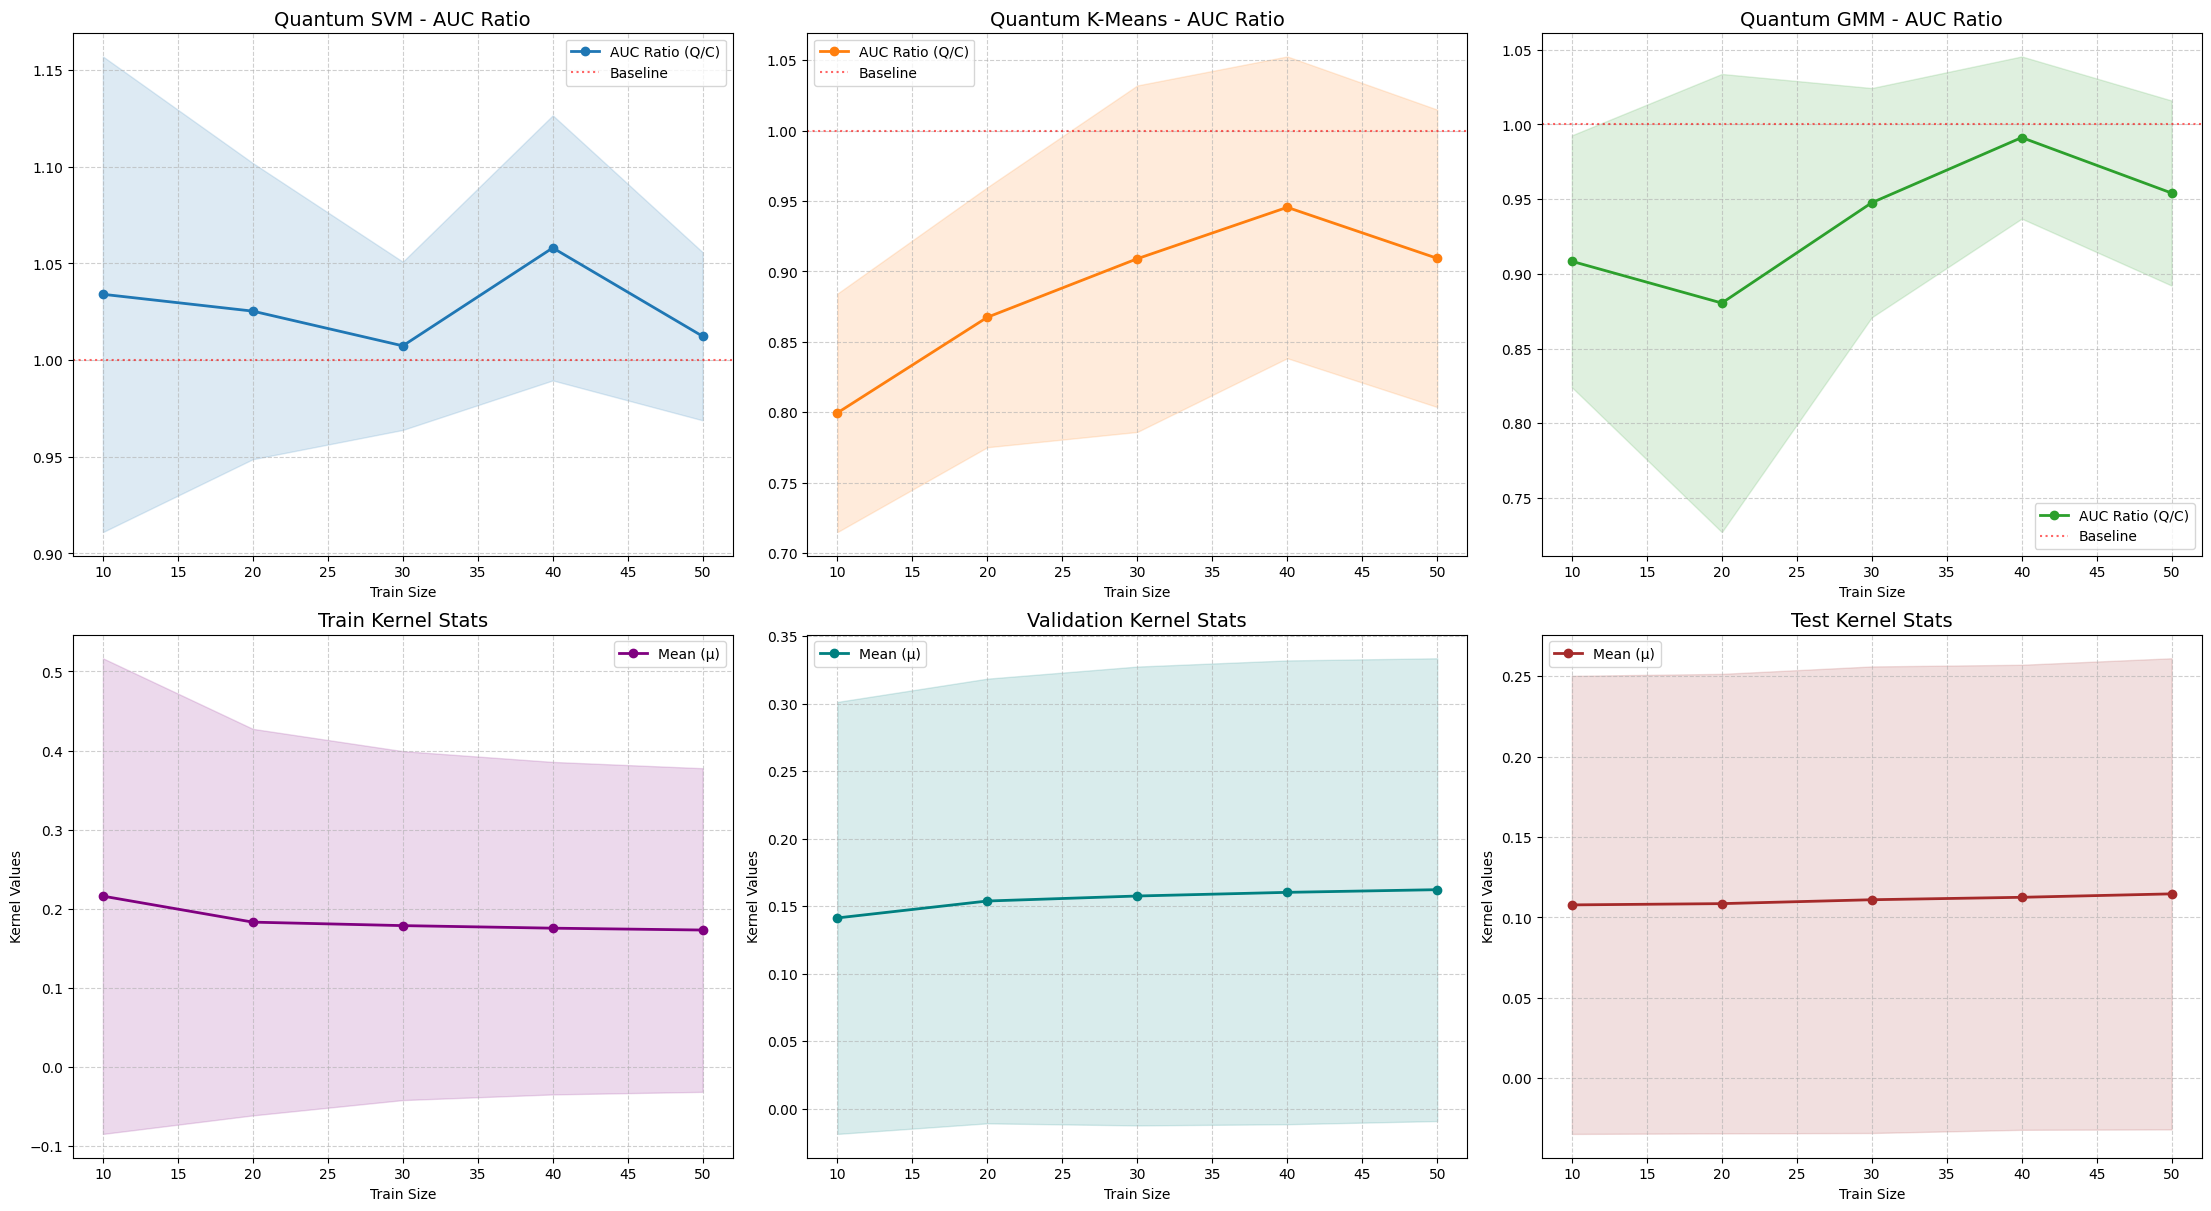

In [ ]:
#@title AUC ratio (Quantum/Classical) and Kernel ANALYSIS over Train Size
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Load data
if download_results:
    df_all = pd.read_csv('processed_data/all_results_trainsize.csv')
elif 'all_results_trainsize' in globals() and len(all_results_trainsize) != 0:
    df_all = pd.DataFrame(all_results)
else:
    raise Exception("No results to load!")



#removing duplicates
df_unique = df_all.drop_duplicates(subset=['Seed', 'train_size']).copy()

# Normalize quantum values (AUC Ratio)
df_unique['Ratio_SVM'] = df_unique['Q_SVM_AUC'] / df_unique['C_SVM_AUC']
df_unique['Ratio_KMEANS'] = df_unique['Q_KMEANS_AUC'] / df_unique['C_KMEANS_AUC']
df_unique['Ratio_GMM'] = df_unique['Q_GMM_AUC'] / df_unique['C_GMM_AUC']

# Grouping by train_size (L is fixed now)
df_mean = df_unique.groupby(['train_size']).mean(numeric_only=True).reset_index()
df_std = df_unique.groupby(['train_size']).std(numeric_only=True).reset_index()

# The X-axis is now train_size
train_sizes_plot = df_mean['train_size'].values

# Create 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(22, 12), constrained_layout=True)

# 1. Models Row (Top)
models = [
    ('Ratio_SVM', 'tab:blue', 'Quantum SVM'),
    ('Ratio_KMEANS', 'tab:orange', 'Quantum K-Means'),
    ('Ratio_GMM', 'tab:green', 'Quantum GMM')
]

for i, (col, color, title) in enumerate(models):
    ax = axes[0, i]
    ax.plot(train_sizes_plot, df_mean[col], marker='o', lw=2, color=color, label='AUC Ratio (Q/C)')
    # Fill between using standard deviation for the ratio
    ax.fill_between(train_sizes_plot, df_mean[col] - df_std[col], df_mean[col] + df_std[col], color=color, alpha=0.15)
    ax.axhline(1.0, color='red', linestyle=':', alpha=0.6, label='Baseline')
    ax.set_title(f"{title} - AUC Ratio", fontsize=14)
    ax.set_xlabel("Train Size")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

# 2. Kernel Stats Row (Bottom)
kernel_stats = [
    ('Ktrain_mu', 'Ktrain_std', 'purple', 'Train Kernel'),
    ('Kvali_mu', 'Kvali_std', 'teal', 'Validation Kernel'),
    ('Ktest_mu', 'Ktest_std', 'brown', 'Test Kernel')
]

for i, (mu_col, std_col, color, title) in enumerate(kernel_stats):
    ax = axes[1, i]
    ax.plot(train_sizes_plot, df_mean[mu_col], marker='o', lw=2, color=color, label='Mean (\u03BC)')
    # Using the mean of the standard deviations (or standard deviation of the means) depending on what you logged
    # Here we plot mu +/- std directly from the logged kernel values
    ax.fill_between(train_sizes_plot, df_mean[mu_col] - df_mean[std_col], df_mean[mu_col] + df_mean[std_col], color=color, alpha=0.15)
    ax.set_title(f"{title} Stats", fontsize=14)
    ax.set_xlabel("Train Size")
    ax.set_ylabel("Kernel Values")
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

plt.show()

In [ ]:
#@title Interactive Background rejection analysis over Train Size
import plotly.express as px
import pandas as pd
import numpy as np

print("\n---  Interactive Plotly Dashboard for Delta_QC ---")

# 1. Load data
df_all = pd.read_csv('processed_data/all_results_trainsize.csv')

# 2. Compute Delta_QC as the Ratio of Quantum over Classical Background Rejection (Rb)
# Clean potential inf values from division by replacing them with NaN or a safe limit
df_all['Delta_QC_SVM'] = df_all['Q_SVM_Rb'] / df_all['C_SVM_Rb']
df_all['Delta_QC_KMEANS'] = df_all['Q_KMEANS_Rb'] / df_all['C_KMEANS_Rb']
df_all['Delta_QC_GMM'] = df_all['Q_GMM_Rb'] / df_all['C_GMM_Rb']

# Clean up infinite boundaries if any division by zero happened in pure backgrounds
df_all = df_all.replace([np.inf, -np.inf], np.nan)

# 3. Calculate statistics aggregated by train_size and Epsilon_s
df_mean = df_all.groupby(['train_size', 'Epsilon_s']).mean(numeric_only=True).reset_index()
df_std = df_all.groupby(['train_size', 'Epsilon_s']).std(numeric_only=True).reset_index()

# 4. Melt columns for tidy-format dynamic traces
delta_cols = ['Delta_QC_SVM', 'Delta_QC_KMEANS', 'Delta_QC_GMM']
df_mean_long = df_mean.melt(id_vars=['train_size', 'Epsilon_s'], value_vars=delta_cols, var_name='Model', value_name='Delta_QC_mean')
df_std_long = df_std.melt(id_vars=['train_size', 'Epsilon_s'], value_vars=delta_cols, var_name='Model_std', value_name='Delta_QC_std')

df_plotly = df_mean_long.copy()
df_plotly['Delta_QC_std'] = df_std_long['Delta_QC_std']
df_plotly['Model'] = df_plotly['Model'].str.replace('Delta_QC_', '')

# Sort variables to prevent animation line-drawing artifacts
df_plotly = df_plotly.sort_values(by=['Epsilon_s', 'train_size'])

# 5. Initialize the Interactive Dashboard (X-axis: train_size, Slider: Epsilon_s)
fig_plotly = px.line(
    df_plotly,
    x='train_size',
    y='Delta_QC_mean',
    color='Model',
    animation_frame='Epsilon_s',   # <--- Slider on Epsilon
    facet_col='Model',             # Separate windows per model architecture
    error_y='Delta_QC_std',        # Variance spreads
    markers=True,
    title="Interactive Delta_QC Ratio Sweep across Train Size and Epsilon Targets",
    labels={'Delta_QC_mean': 'Background Rejection Ratio (Q / C)', 'train_size': 'Train Size', 'Epsilon_s': 'Epsilon Target (TPR)'},
    category_orders={"Model": ["SVM", "KMEANS", "GMM"]},
    color_discrete_map={"SVM": "#1f77b4", "KMEANS": "#ff7f0e", "GMM": "#2ca02c"}
)

# Reference baseline at 1.0 (Performance equal between Quantum and Classical)
fig_plotly.add_hline(y=1.0, line_dash="dot", line_color="red", opacity=0.7, row="all", col="all")

# Layout enhancements
fig_plotly.update_layout(
    height=550,
    hovermode='x unified',
    title_font_size=16,
    showlegend=False
)

# Unmatch Y axes so individual window scaling fits comfortably during dynamic step updates
fig_plotly.update_yaxes(matches=None)
fig_plotly.update_traces(error_y_thickness=1.2, error_y_width=4)

fig_plotly.show()


---  Interactive Plotly Dashboard for Delta_QC ---


In [ ]:
#@title Decision curves with Validation dataset for the choice of hyperparameters
import plotly.express as px
import pandas as pd
import pickle
import os

with open('processed_data/all_results_trainsize.pkl', 'rb') as f:
        all_results_trainsize = pickle.load(f)

rows = []
seen_states = set()

for res in all_results_trainsize:
    state_key = (res['Seed'], res['train_size'])
    if state_key in seen_states:
        continue
    seen_states.add(state_key)

    state = f"Seed: {res['Seed']} | Train Size: {res['train_size']}"

    nus_sweep_local = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]
    k_values_local = list(range(2, 2 + len(res['km_c_curve_train'])))
    n_values_local = list(range(1, 1 + len(res['gmm_c_curve_train'])))

    configs = [
        ('Classic', 'SVM', nus_sweep_local, res['svm_c_curve_train'], res['svm_c_curve_vali'], res['C_SVM_nu_chosen']),
        ('Quantum', 'SVM', nus_sweep_local, res['svm_q_curve_train'], res['svm_q_curve_vali'], res['SVM_nu_chosen']),
        ('Classic', 'KMeans', k_values_local, res['km_c_curve_train'], res['km_c_curve_vali'], res['C_KM_k_chosen']),
        ('Quantum', 'KMeans', k_values_local, res['km_q_curve_train'], res['km_q_curve_vali'], res['KM_k_chosen']),
        ('Classic', 'GMM', n_values_local, res['gmm_c_curve_train'], res['gmm_c_curve_vali'], res['C_GMM_n_chosen']),
        ('Quantum', 'GMM', n_values_local, res['gmm_q_curve_train'], res['gmm_q_curve_vali'], res['GMM_n_chosen']),
    ]

    for m_type, algo, x_vals, train_vals, vali_vals, chosen_val in configs:
        for i, x in enumerate(x_vals):
            rows.append({'Seed': res['Seed'], 'train_size': res['train_size'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': x, 'Score': train_vals[i], 'Curve': 'Train'})
            rows.append({'Seed': res['Seed'], 'train_size': res['train_size'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': x, 'Score': vali_vals[i], 'Curve': 'Vali'})

        y_min = min(min(train_vals), min(vali_vals))
        y_max = max(max(train_vals), max(vali_vals))
        y_margin = (y_max - y_min) * 0.15 if y_max != y_min else 0.1

        rows.append({'Seed': res['Seed'], 'train_size': res['train_size'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': chosen_val, 'Score': y_min - y_margin, 'Curve': 'Chosen Threshold'})
        rows.append({'Seed': res['Seed'], 'train_size': res['train_size'], 'State': state, 'Type': m_type, 'Algorithm': algo, 'X': chosen_val, 'Score': y_max + y_margin, 'Curve': 'Chosen Threshold'})

df_viz = pd.DataFrame(rows).sort_values(by=['Seed', 'train_size', 'Type', 'Algorithm', 'Curve', 'X'])
ordered_states = df_viz['State'].unique().tolist()

fig = px.line(
    df_viz,
    x='X',
    y='Score',
    color='Curve',
    facet_row='Type',
    facet_col='Algorithm',
    animation_frame='State',
    category_orders={
        "Type": ["Classic", "Quantum"],
        "Algorithm": ["SVM", "KMeans", "GMM"],
        "State": ordered_states
    },
    title="Model Optimization Curves Comparison (Train Size Sweep)",
    color_discrete_map={
        'Train': '#1f77b4',
        'Vali': '#ff7f0e',
        'Chosen Threshold': 'red'
    },
    height=850
)

fig.for_each_trace(
    lambda t: t.update(line=dict(dash='dash', width=2.5)) if t.name == 'Chosen Threshold' else t.update(line=dict(width=2))
)

fig.update_xaxes(matches=None)
fig.update_yaxes(matches=None)

fig.update_xaxes(range=[-0.03, 0.54], col=1)

fig.update_xaxes(showline=True, linewidth=1, linecolor='rgba(100,100,100,0.6)', mirror=True, gridcolor='rgba(220,220,220,0.5)')
fig.update_yaxes(showline=True, linewidth=1, linecolor='rgba(100,100,100,0.6)', mirror=True, gridcolor='rgba(220,220,220,0.5)')

fig.update_xaxes(title_text="Nu Hyperparameter", col=1)
fig.update_xaxes(title_text="Number of Clusters K", col=2)
fig.update_xaxes(title_text="GMM Components (N)", col=3)

fig.update_yaxes(title_text="Inertia / Decision Metric", col=1)
fig.update_yaxes(title_text="Silhouette Score", col=2)
fig.update_yaxes(title_text="BIC", col=3)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.update_layout(
    hovermode='x unified',
    legend_title_text='Curve Type',
    margin=dict(t=80, b=80, l=80, r=80)
)


print("PLEASE, CLICK ON AUTOSCALE or ZOOM OUT, IN THE UPPER-RIGHT TO RESCALE THE AXES")
fig.show()

PLEASE, CLICK ON AUTOSCALE or ZOOM OUT, IN THE UPPER-RIGHT TO RESCALE THE AXES
